# Recommendation System

## Dataset Overview

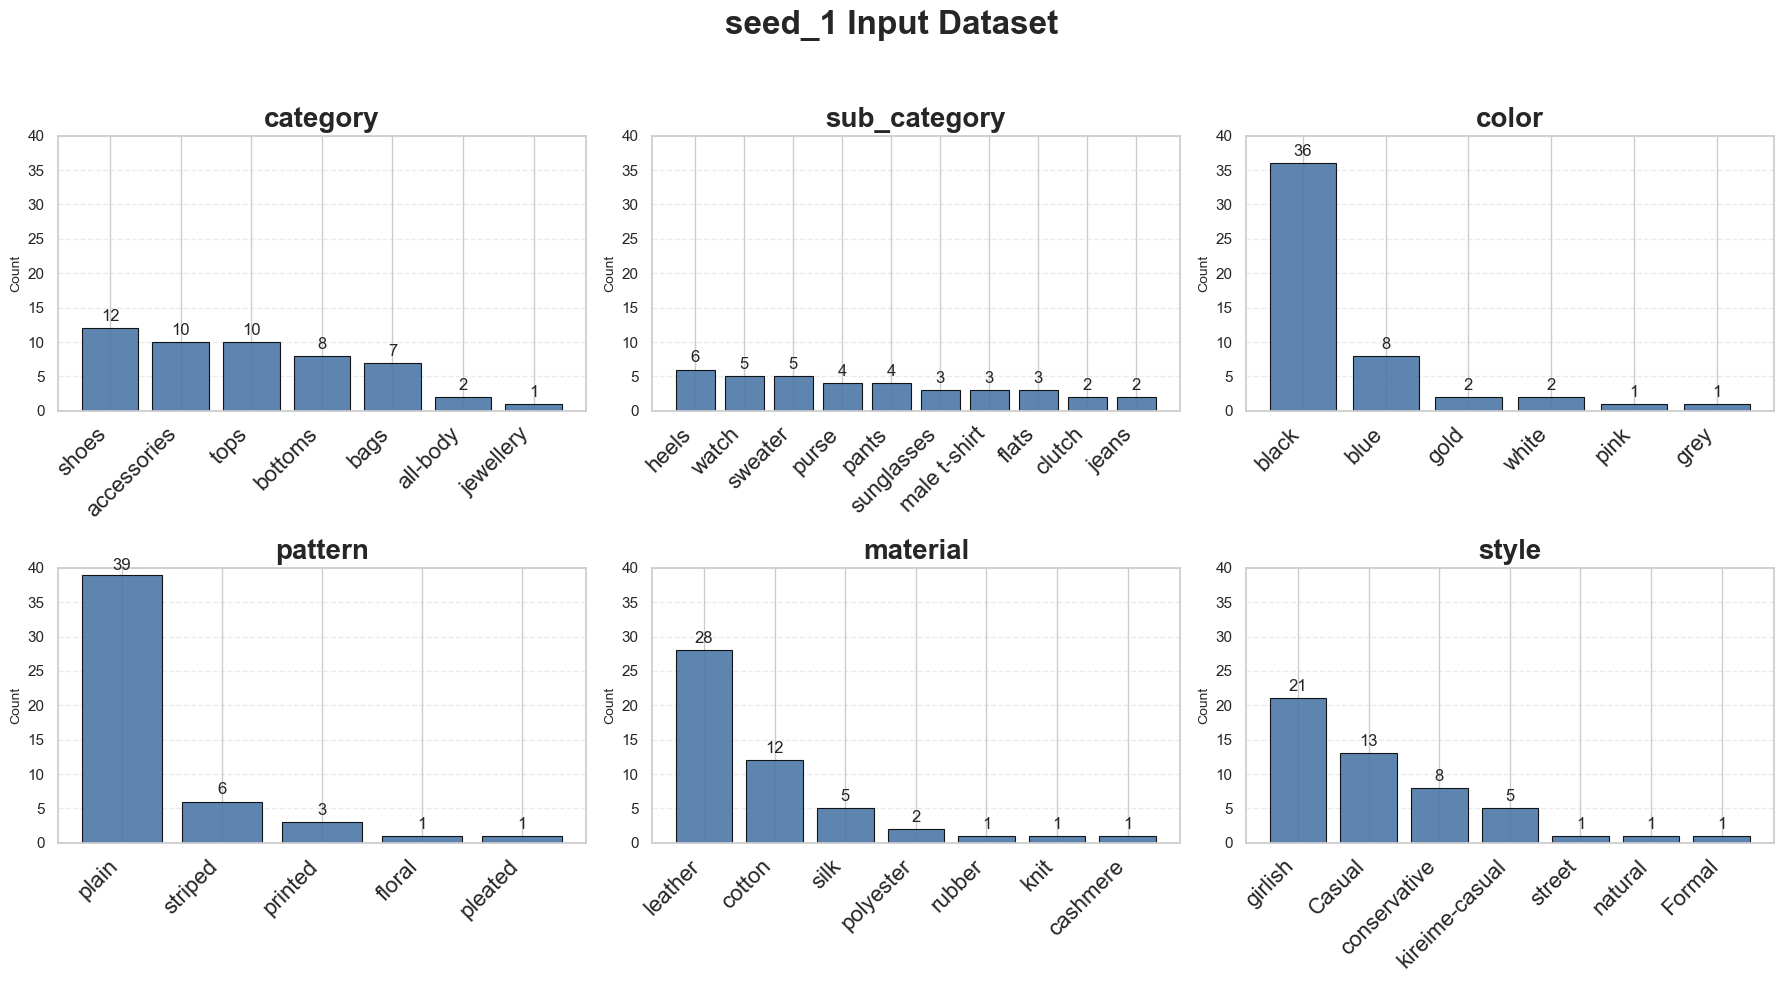

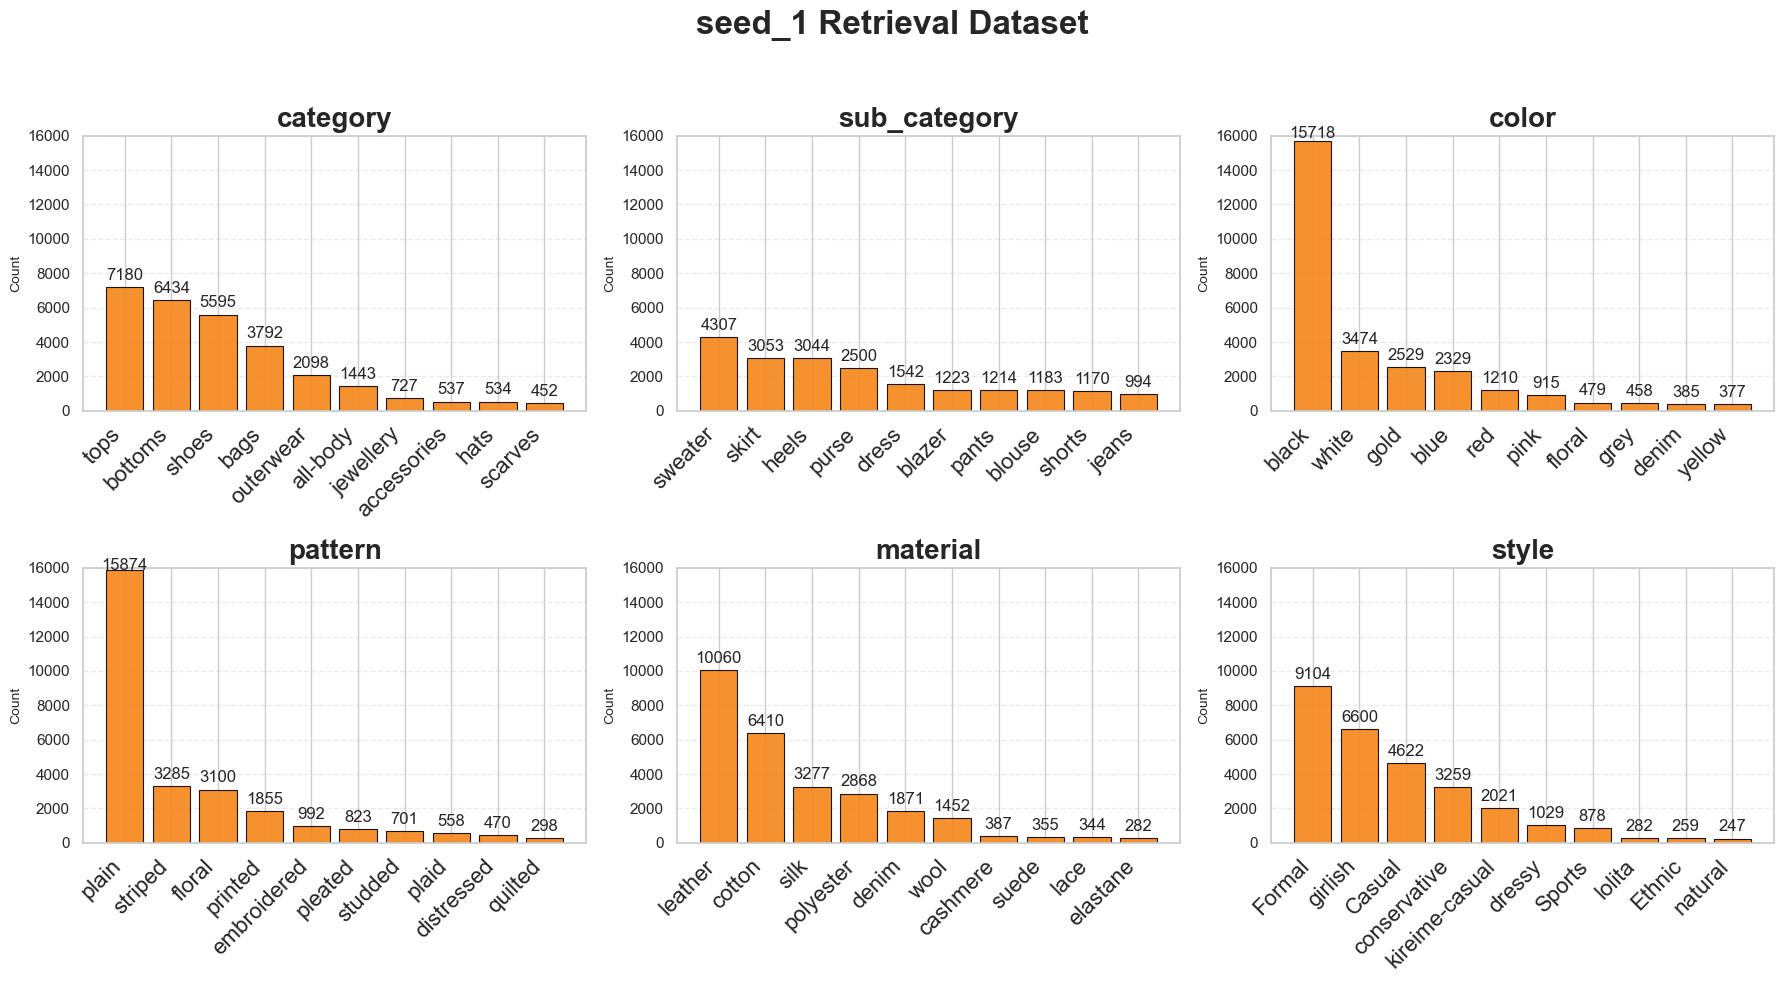

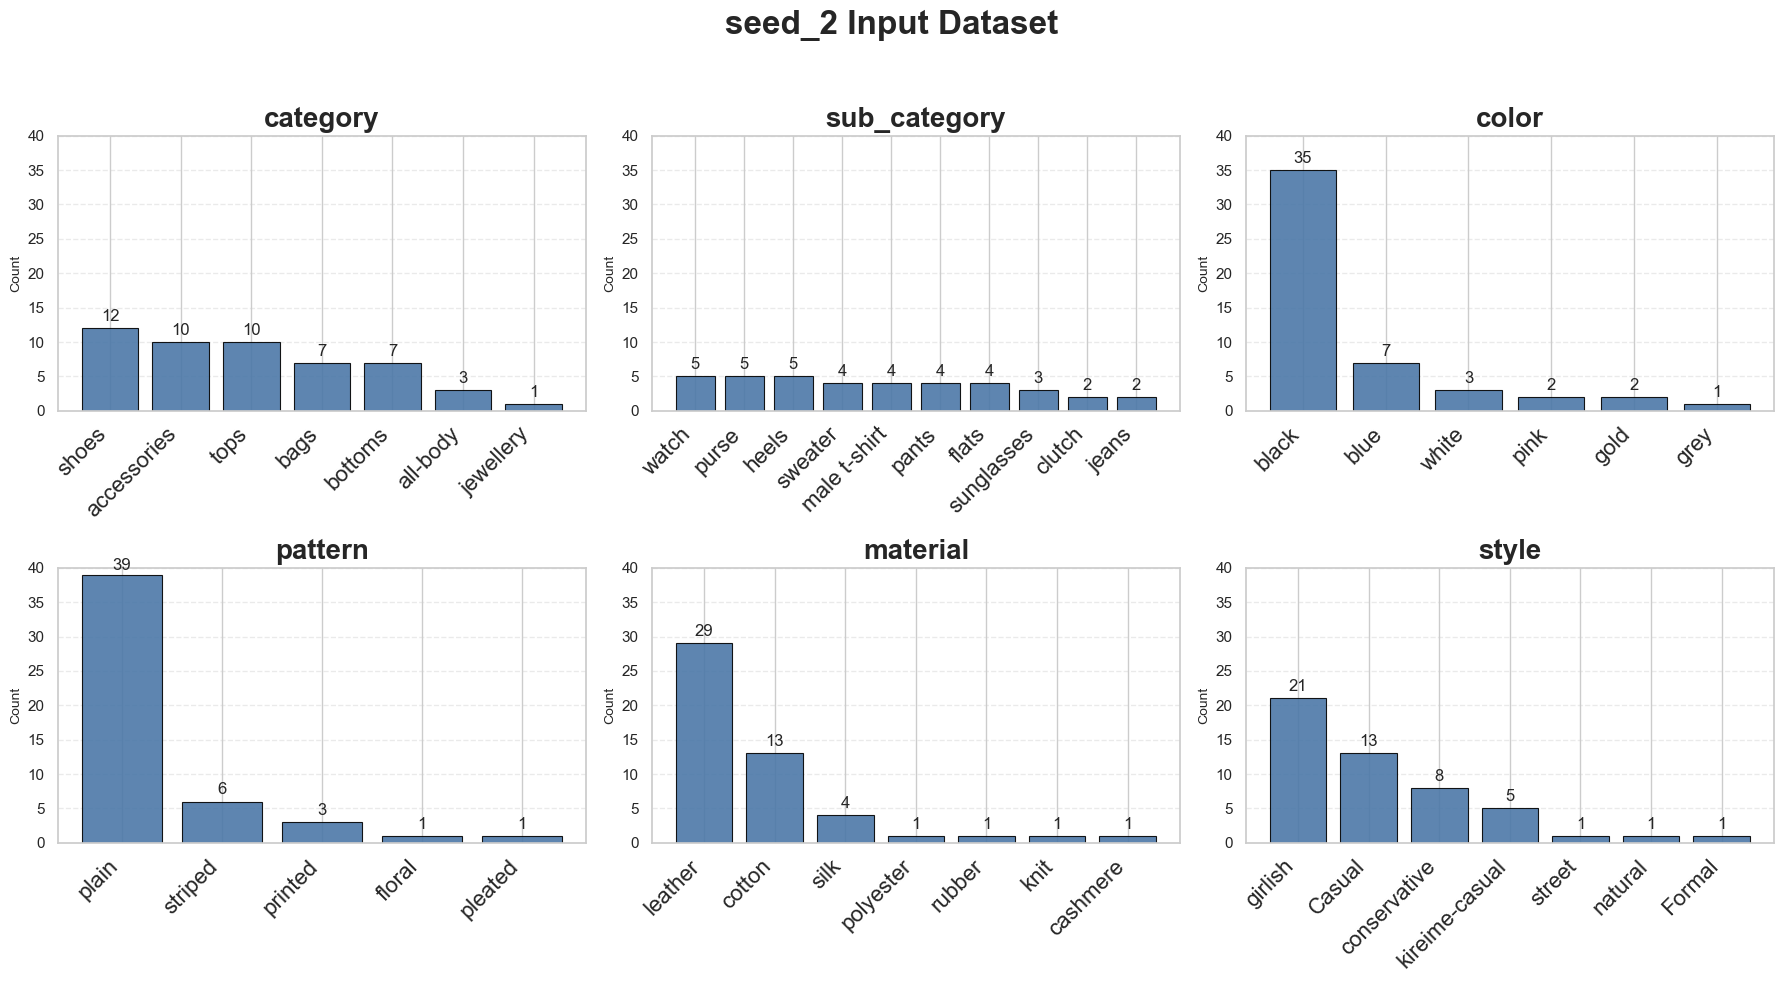

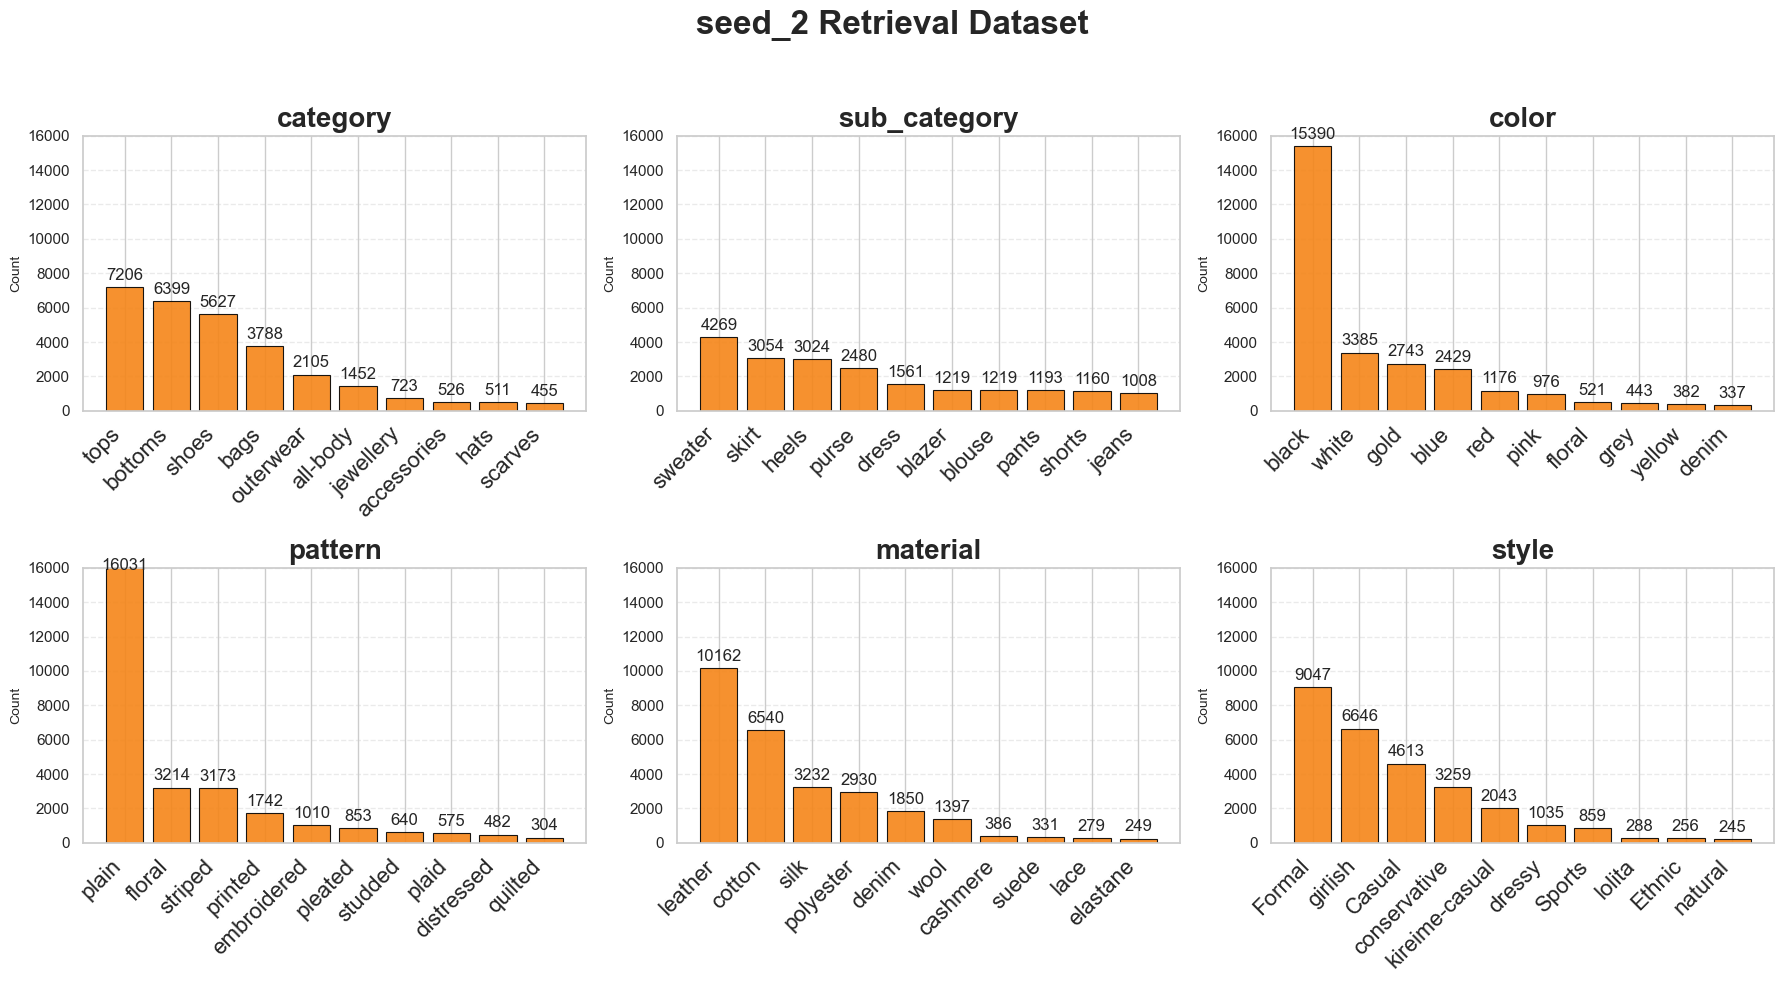

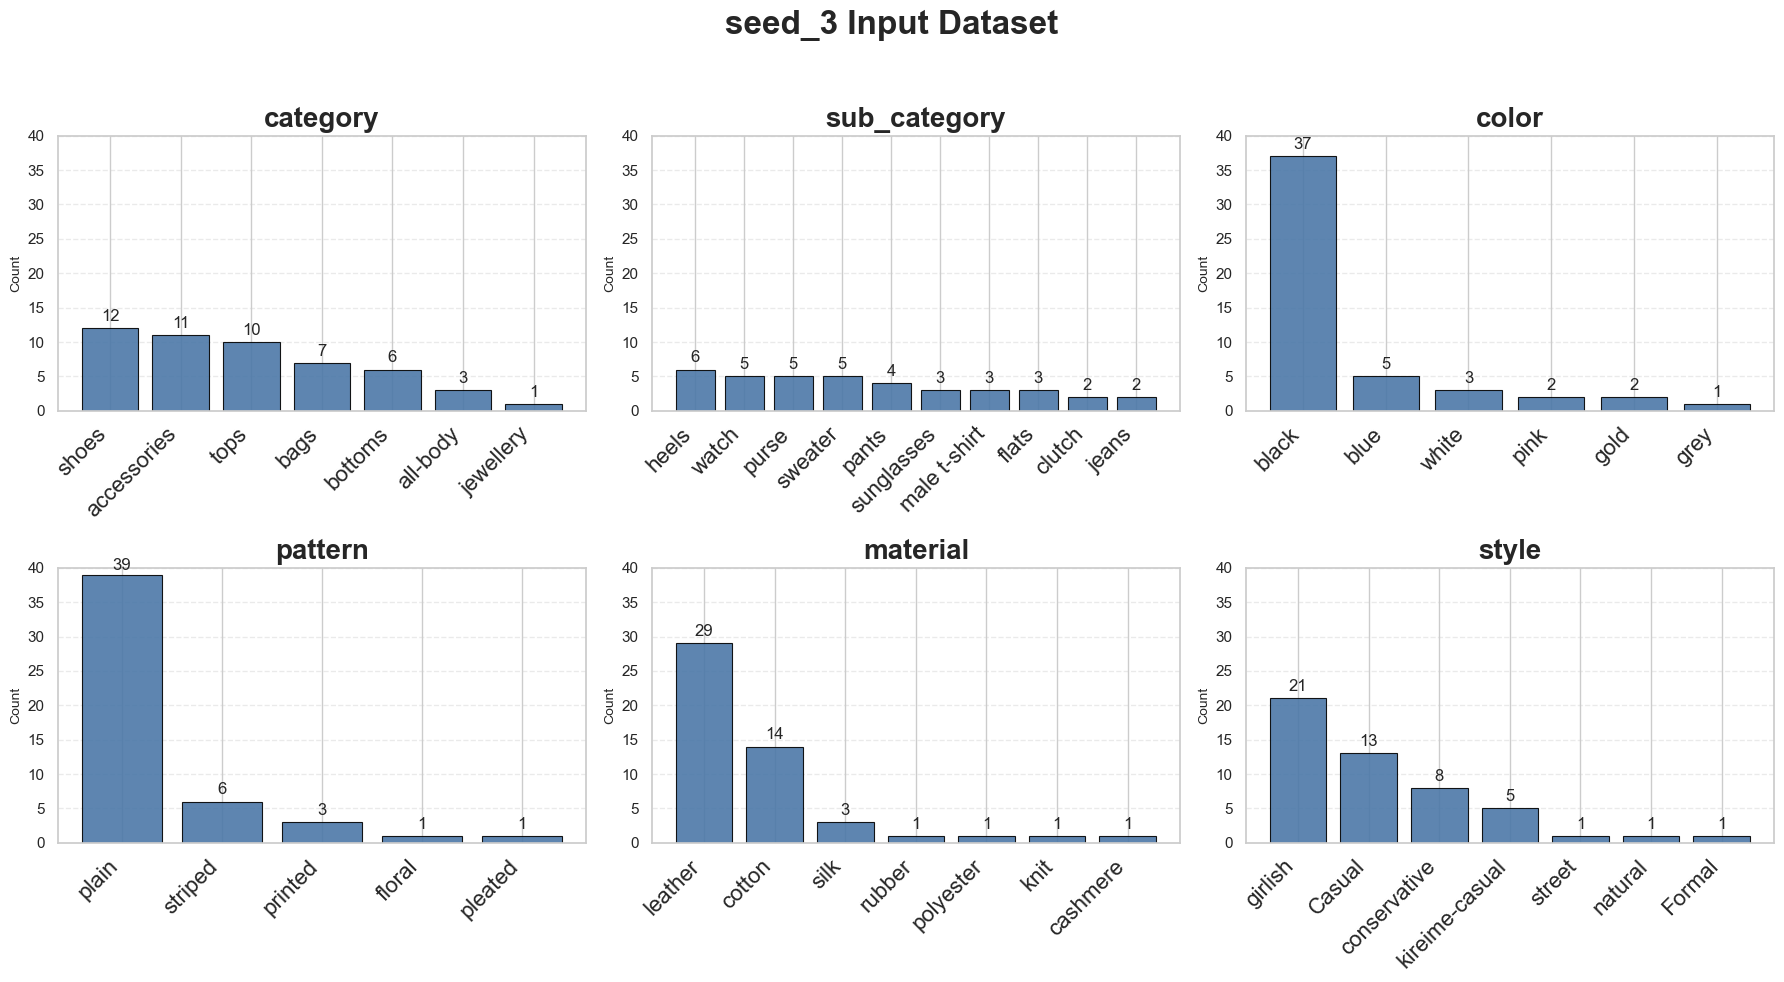

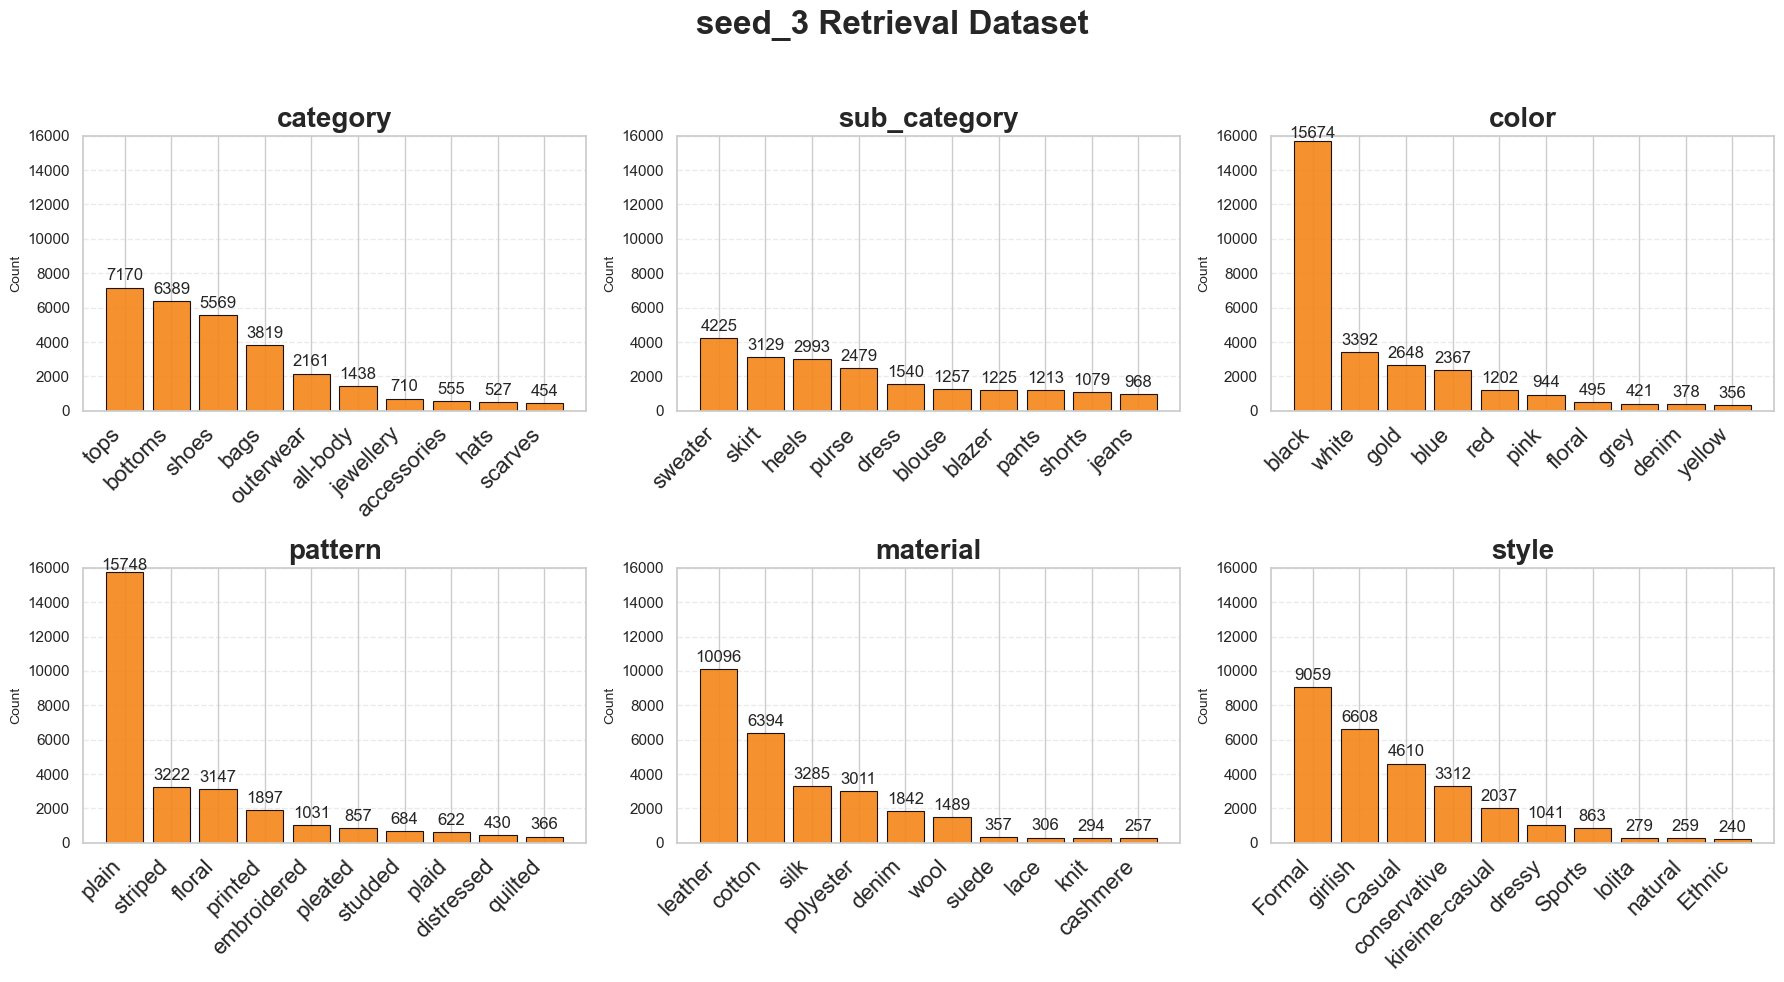

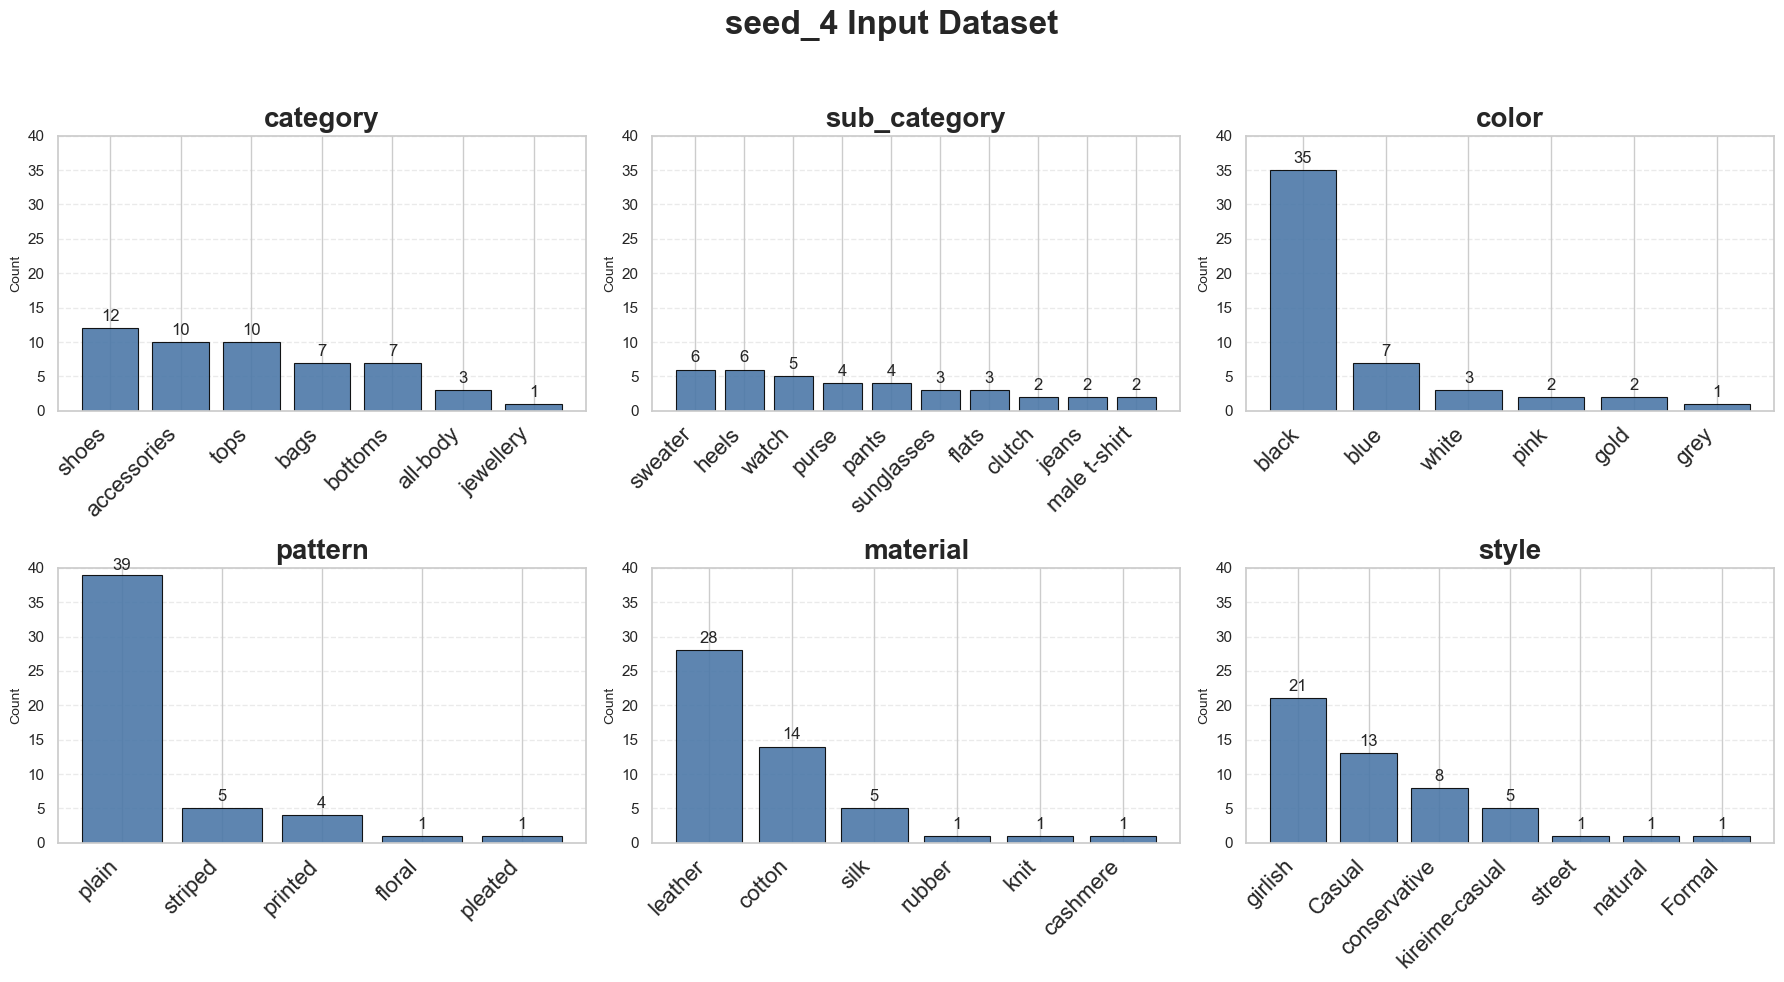

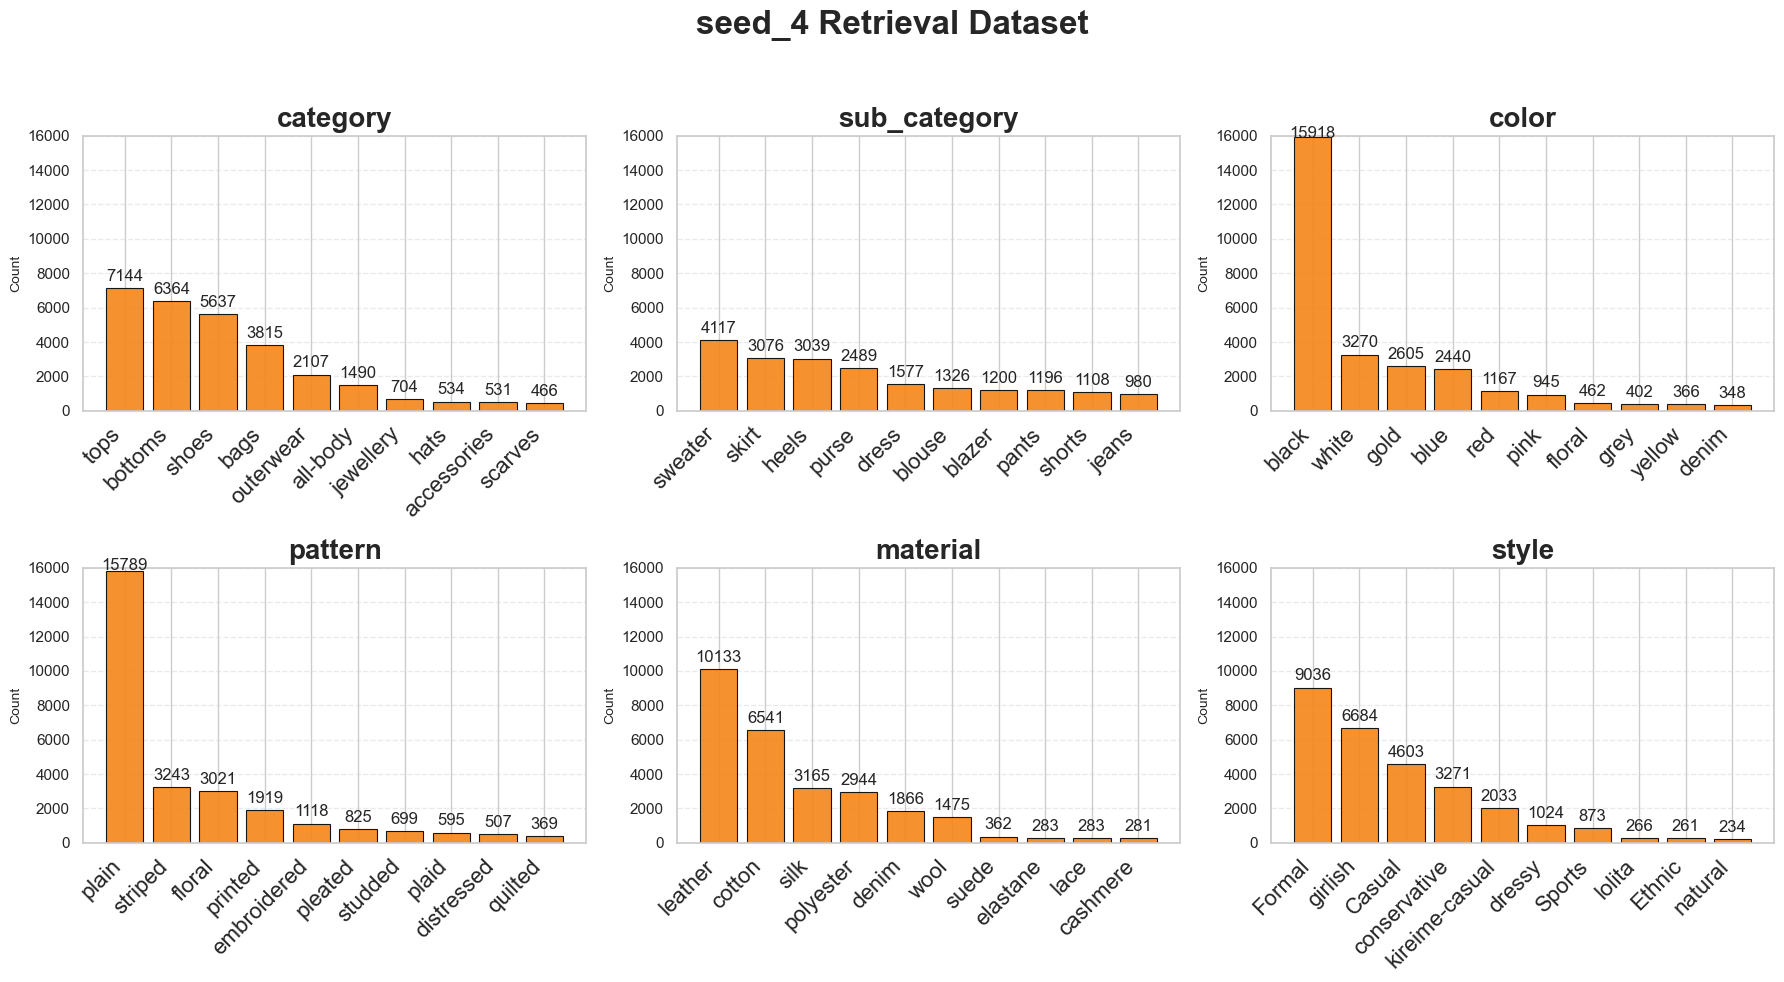

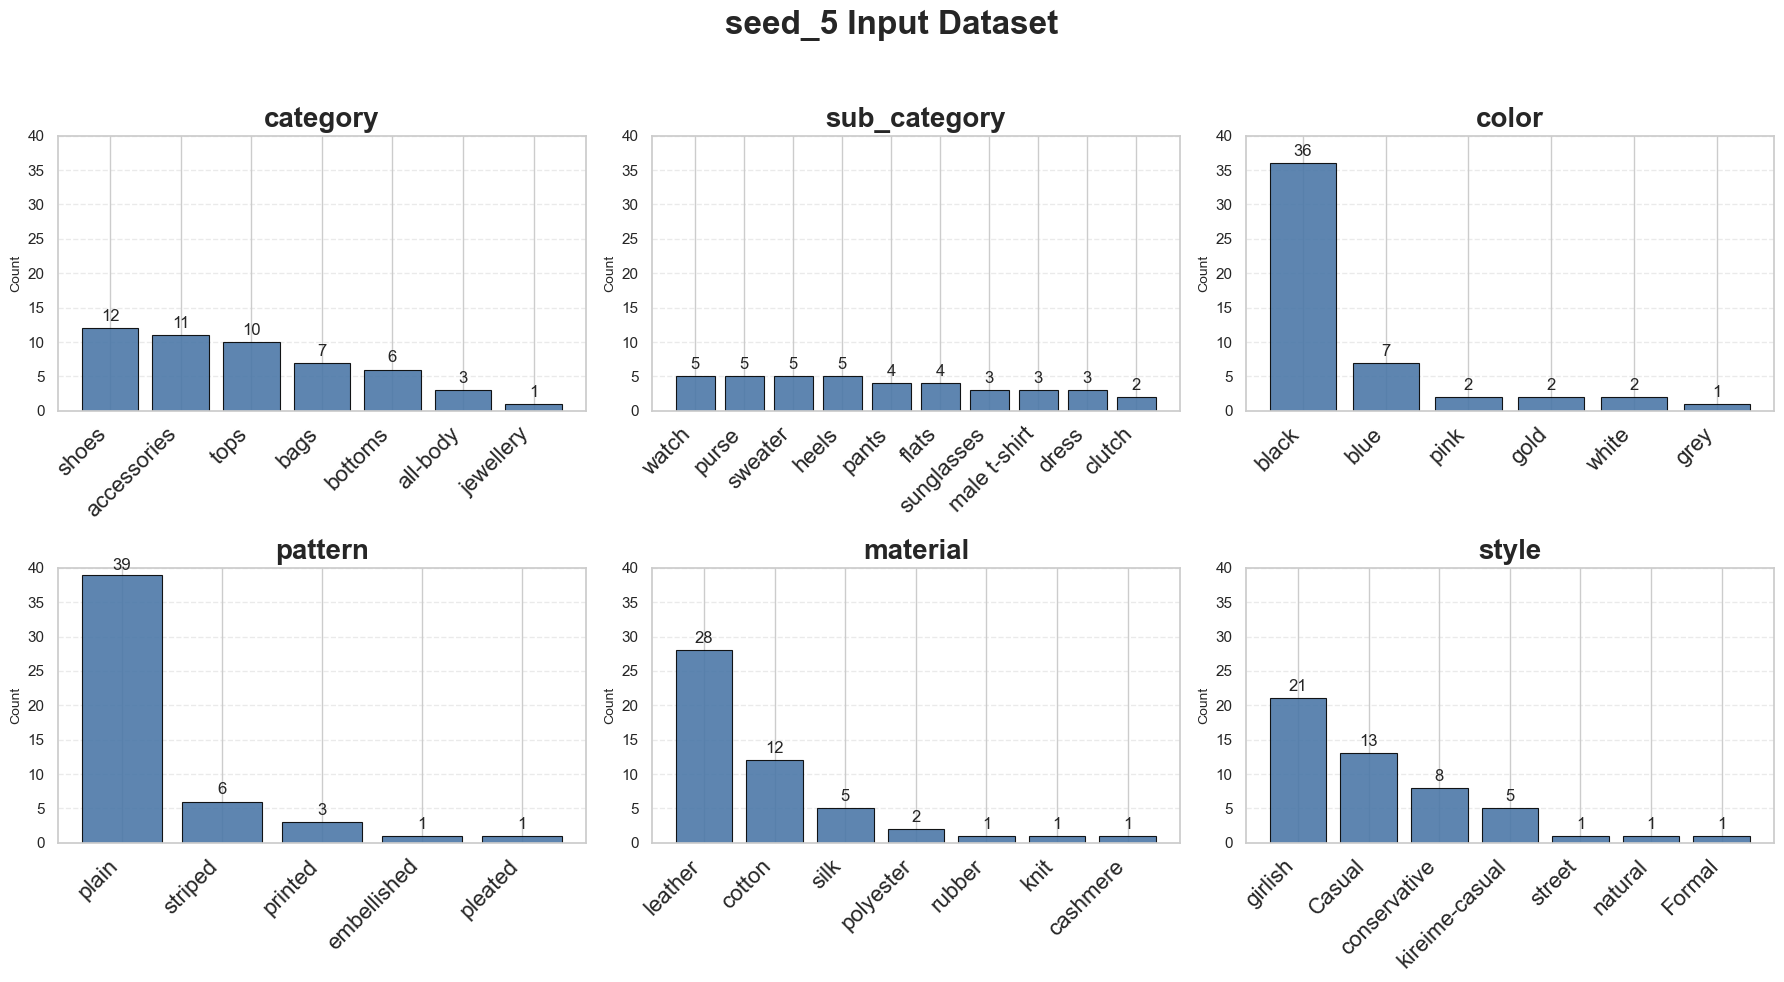

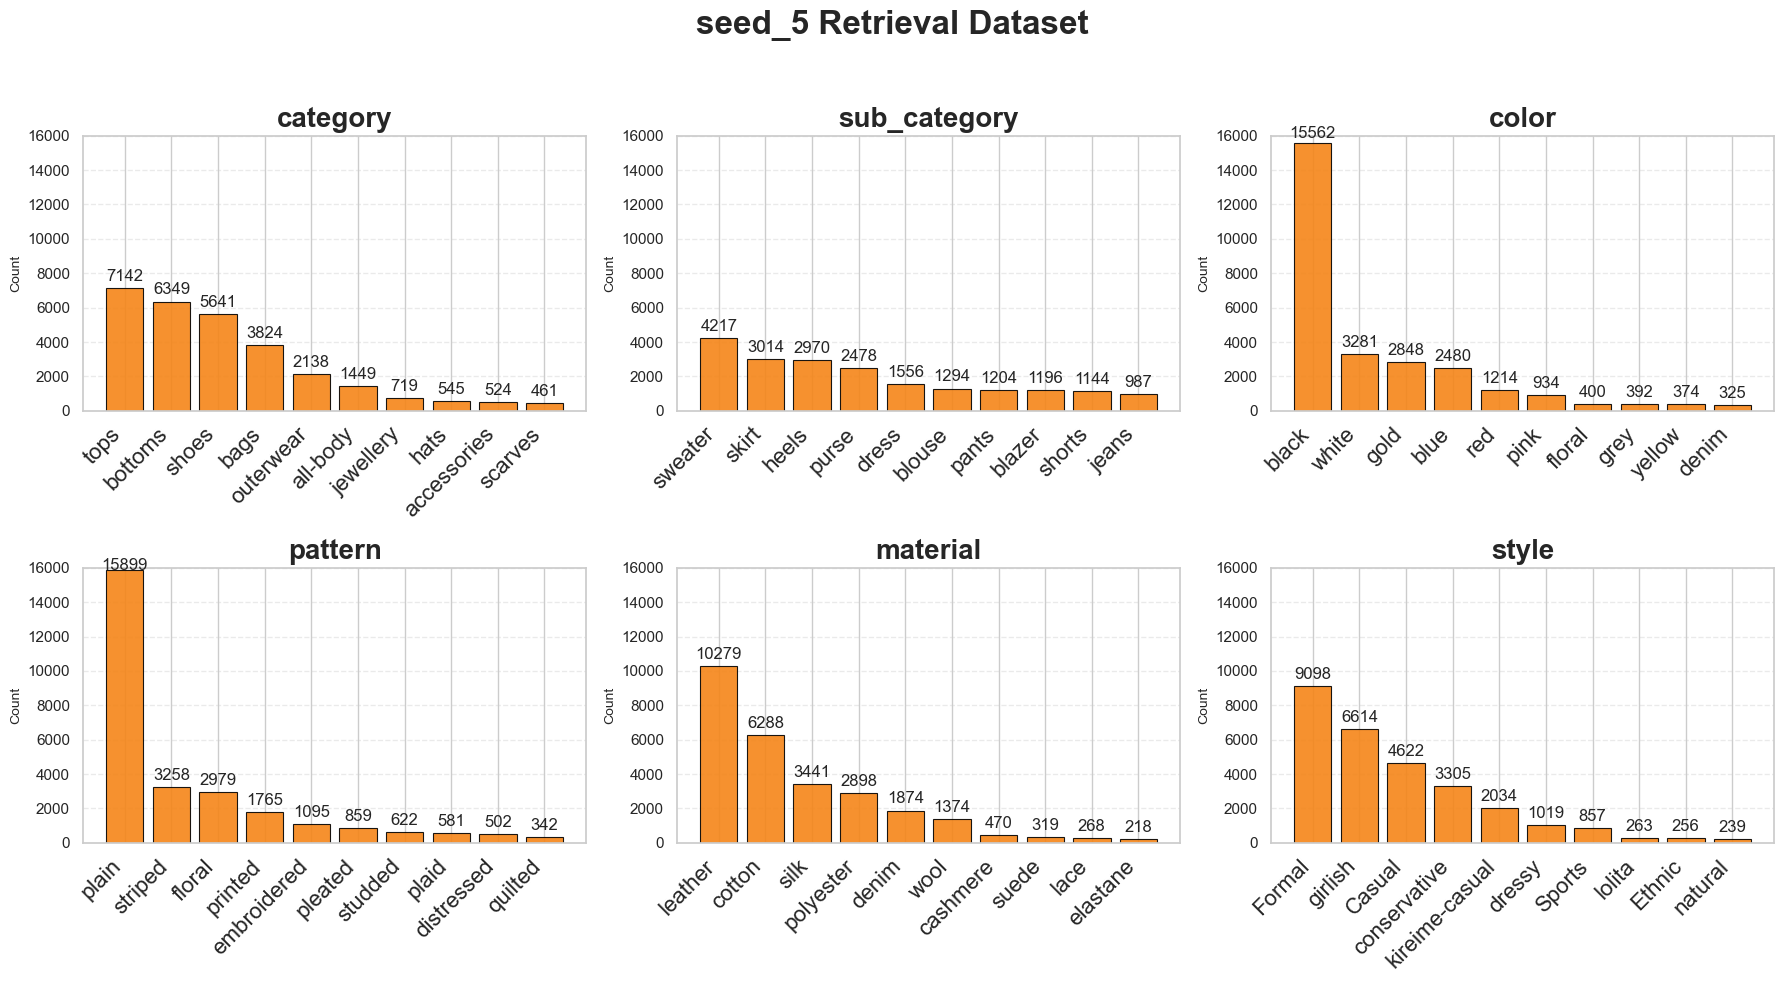

In [14]:
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

CLS_DIR = Path("classification_results")
ALL_ATTRIBUTES = ["category", "sub_category", "color", "pattern", "material", "style"]

SEED_CONFIGS = [
    {
        "seed_name": "seed_1",
        "query_csv": CLS_DIR / "seed_1" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_1" / "train.csv",
    },
    {
        "seed_name": "seed_2",
        "query_csv": CLS_DIR / "seed_2" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_2" / "train.csv",
    },
    {
        "seed_name": "seed_3",
        "query_csv": CLS_DIR / "seed_3" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_3" / "train.csv",
    },
    {
        "seed_name": "seed_4",
        "query_csv": CLS_DIR / "seed_4" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_4" / "train.csv",
    },
    {
        "seed_name": "seed_5",
        "query_csv": CLS_DIR / "seed_5" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_5" / "train.csv",
    },
]

sns.set(style="whitegrid")
TOP_N = 10

INPUT_COLOR = "#4C78A8"
RETRIEVAL_COLOR = "#F58518"

INPUT_YMIN, INPUT_YMAX = 0, 40
RETRIEVAL_YMIN, RETRIEVAL_YMAX = 0, 16000


def plot_top_attribute_distributions(
    df,
    attributes,
    figure_title,
    bar_color,
    y_min,
    y_max,
    top_n=10
):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, attr in enumerate(attributes):
        ax = axes[i]

        if attr not in df.columns:
            ax.text(0.5, 0.5, "Column not found", ha="center", va="center", fontsize=11)
            ax.set_title(attr, fontsize=12, fontweight="bold")
            ax.set_xticks([])
            ax.set_ylim(y_min, y_max)
            continue

        values = df[attr].fillna("Missing").astype(str).str.strip()
        values = values.replace("", "Missing")

        top_values = values.value_counts().nlargest(top_n)

        if top_values.empty:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
            ax.set_title(attr, fontsize=12, fontweight="bold")
            ax.set_xticks([])
            ax.set_ylim(y_min, y_max)
            continue

        x = np.arange(len(top_values))
        bars = ax.bar(
            x,
            top_values.values,
            color=bar_color,
            alpha=0.9,
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_xticks(x)
        ax.set_xticklabels(top_values.index, rotation=45, ha="right", fontsize=16)
        ax.set_title(attr, fontsize=20, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        ax.set_ylabel("Count", fontsize=10)

        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.set_axisbelow(True)

        for bar, value in zip(bars, top_values.values):
            text_y = min(value + (y_max - y_min) * 0.015, y_max * 0.98)
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                text_y,
                f"{int(value)}",
                ha="center",
                va="bottom",
                fontsize=12
            )

    plt.suptitle(figure_title, fontsize=24, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


for seed_cfg in SEED_CONFIGS:
    seed_name = seed_cfg["seed_name"]

    try:
        input_df = pd.read_csv(seed_cfg["query_csv"])
        retrieval_df = pd.read_csv(seed_cfg["retrieval_csv"])
    except Exception as e:
        print(f"Skipping {seed_name}: failed to load CSVs ({e})")
        continue

    plot_top_attribute_distributions(
        df=input_df,
        attributes=ALL_ATTRIBUTES,
        figure_title=f"{seed_name} Input Dataset",
        bar_color=INPUT_COLOR,
        y_min=INPUT_YMIN,
        y_max=INPUT_YMAX,
        top_n=TOP_N
    )

    plot_top_attribute_distributions(
        df=retrieval_df,
        attributes=ALL_ATTRIBUTES,
        figure_title=f"{seed_name} Retrieval Dataset",
        bar_color=RETRIEVAL_COLOR,
        y_min=RETRIEVAL_YMIN,
        y_max=RETRIEVAL_YMAX,
        top_n=TOP_N
    )

## Image-Only Retrieval Baseline for Fashion Recommendation

This part evaluates image-only retrieval models on five seeds and saves all outputs immediately after each model run.

<b>Goal</b>
Compare image-only embedding models for similar-image retrieval using:
- SigLIP2
- FashionCLIP
- OpenFashionCLIP
- Marqo-FashionSigLIP
- Marqo-FashionCLIP

<b>Input</b>
For each seed:
- Query CSV:
  `1_exp/0318/classification_results/seed_x/recom_dataset.csv`
- Query image folder:
  `1_data/recom_dataset`
- Retrieval CSV:
  `1_exp/0318/classification_results/seed_x/train.csv`
- Retrieval image folder:
  `1_data/seed_xx/train/images`

The `image_id` column is used to locate the image file.

<b>Output</b>
All outputs are saved under:
`1_exp/0318/image-only/<model_name>/`

Saved CSV files:
1. `retrieval_results.csv`
2. `retrieval_ranking_quality.csv`
3. `attribute_matching_single.csv`
4. `attribute_matching_multiple.csv`
5. `attribute_matching_weighted.csv`
6. `global_retrieval_ranking_quality.csv`
7. `global_attribute_matching_single.csv`
8. `global_attribute_matching_multiple.csv`
9. `global_attribute_matching_weighted.csv`

<b>Evaluation</b>
1. Retrieval ranking quality
  Computed for each attribute at K = 1, 3, 5, 10:
  - Precision@K
  - Recall@K
  - MRR@K
  - MAP@K
2. Attribute matching quality
  1. Single-value attributes and token-set exact matching:
  - AMR@K
  - EAM@K

  2. Multi-value semantic similarity:
  - Semantic similarity

  3. Weighted combination:
  - WAS using semantic similarity on all attributes

<b>Notes</b>
- Single-value attributes:
  - category
  - sub_category
  - style

- Multi-value attributes:
  - color
  - material
  - pattern

- For multi-value text normalization, comma-separated values are split into sets.

- Global tables are computed only after all five seeds finish.

### Imports, paths, and configs

In [53]:
import os
import re
import json
import math
import time
import shutil
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
import clip
try:
    import open_clip
except ImportError:
    open_clip = None

try:
    from transformers import AutoModel, AutoProcessor, CLIPModel, CLIPProcessor
except ImportError:
    AutoModel = None
    AutoProcessor = None
    CLIPModel = None
    CLIPProcessor = None

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Root paths
# ------------------------------------------------------------
CLS_DIR = Path("classification_results")
QUERY_IMAGE_DIR = Path("../../1_data/recom_dataset")
OUTPUT_ROOT = Path("image-only")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Seed mapping
# ------------------------------------------------------------
SEED_CONFIGS = [
    {
        "seed_name": "seed_1",
        "query_csv": CLS_DIR / "seed_1" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_1" / "train.csv",
        "retrieval_image_dir": Path("../../1_data/seed_11/train/images"),
    },
    {
        "seed_name": "seed_2",
        "query_csv": CLS_DIR / "seed_2" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_2" / "train.csv",
        "retrieval_image_dir": Path("../../1_data/seed_22/train/images"),
    },
    {
        "seed_name": "seed_3",
        "query_csv": CLS_DIR / "seed_3" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_3" / "train.csv",
        "retrieval_image_dir": Path("../../1_data/seed_33/train/images"),
    },
    {
        "seed_name": "seed_4",
        "query_csv": CLS_DIR / "seed_4" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_4" / "train.csv",
        "retrieval_image_dir": Path("../../1_data/seed_44/train/images"),
    },
    {
        "seed_name": "seed_5",
        "query_csv": CLS_DIR / "seed_5" / "recom_dataset.csv",
        "retrieval_csv": CLS_DIR / "seed_5" / "train.csv",
        "retrieval_image_dir": Path("../../1_data/seed_55/train/images"),
    },
]

# ------------------------------------------------------------
# Retrieval and evaluation config
# ------------------------------------------------------------
TOP_KS = [1, 3, 5, 10]
MAX_K = max(TOP_KS)

SINGLE_ATTRIBUTES = ["category", "sub_category", "style"]
MULTI_ATTRIBUTES = ["color", "material", "pattern"]
ALL_ATTRIBUTES = ["category", "sub_category", "color", "material", "pattern", "style"]

ATTRIBUTE_WEIGHTS = {
    "category": 4.0,
    "sub_category": 3.0,
    "color": 3.0,
    "style": 2.0,
    "pattern": 1.0,
    "material": 1.0,
}

# Threshold used when binary relevance is needed for multi-value attributes
MULTI_BINARY_RELEVANCE_THRESHOLD = 0.5

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# semantica similarity
clip_model, _ = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()

# ------------------------------------------------------------
# Model registry
# ------------------------------------------------------------
MODEL_REGISTRY = {
    "siglip2": {
        "type": "transformers_siglip2",
        "hf_name": "google/siglip2-base-patch16-224",
    },
    "fashionclip": {
        "type": "transformers_clip",
        "hf_name": "patrickjohncyh/fashion-clip",
    },
    "openfashionclip": {
        "type": "open_clip_checkpoint",
        "backbone": "ViT-B-32",
        "checkpoint_path": Path("openfashionclip.pt"),
    },
    "marqo_fashionsiglip": {
        "type": "open_clip_hf",
        "hf_name": "Marqo/marqo-fashionSigLIP",
    },
    "marqo_fashionclip": {
        "type": "open_clip_hf",
        "hf_name": "Marqo/marqo-fashionCLIP",
    },
}

Device: cuda


### Check models

In [54]:
def check_dependencies():
    status_rows = []
    for model_name, cfg in MODEL_REGISTRY.items():
        model_type = cfg["type"]
        ready = True
        reason = "OK"

        if model_type in ["transformers_siglip2", "transformers_clip"]:
            if AutoModel is None and model_type == "transformers_siglip2":
                ready = False
                reason = "transformers is not installed"
            if CLIPModel is None and model_type == "transformers_clip":
                ready = False
                reason = "transformers is not installed"

        elif model_type in ["open_clip_checkpoint", "open_clip_hf"]:
            if open_clip is None:
                ready = False
                reason = "open_clip_torch is not installed"

            if model_type == "open_clip_checkpoint":
                ckpt = cfg["checkpoint_path"]
                if not Path(ckpt).exists():
                    ready = False
                    reason = f"checkpoint not found: {ckpt}"

        status_rows.append({
            "model": model_name,
            "type": model_type,
            "ready": ready,
            "reason": reason
        })

    status_df = pd.DataFrame(status_rows)
    display(status_df)
    return status_df

dependency_status = check_dependencies()

,model,type,ready,reason
0,siglip2,transformers_siglip2,True,OK
1,fashionclip,transformers_clip,True,OK
2,openfashionclip,open_clip_checkpoint,True,OK
3,marqo_fashionsiglip,open_clip_hf,True,OK
4,marqo_fashionclip,open_clip_hf,True,OK


### Functions

In [55]:
# ------------------------------------------------------------
# Text and attribute normalization
# ------------------------------------------------------------
def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def normalize_text(text):
    text = safe_str(text).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"[_/|]+", " ", text)
    text = re.sub(r"[^a-z0-9,\-\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def parse_multi_value_attr(text):
    text = normalize_text(text)
    if not text:
        return []
    parts = [p.strip() for p in text.split(",")]
    parts = [re.sub(r"\s+", " ", p).strip() for p in parts if p.strip()]
    return sorted(list(dict.fromkeys(parts)))

def normalize_single_attr(text):
    return normalize_text(text)

def attr_to_text_for_semantic(attr_name, value):
    value = safe_str(value)
    if attr_name in MULTI_ATTRIBUTES:
        vals = parse_multi_value_attr(value)
        return ", ".join(vals)
    return normalize_single_attr(value)

def image_id_to_path(image_root, image_id):
    image_root = Path(image_root)
    image_id = safe_str(image_id)

    candidates = []
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        candidates.append(image_root / f"{image_id}{ext}")
        candidates.append(image_root / image_id / f"{image_id}{ext}")

    # Also try recursive search as fallback
    for p in candidates:
        if p.exists():
            return p

    recursive_matches = list(image_root.rglob(f"{image_id}.*"))
    valid_matches = [p for p in recursive_matches if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
    if len(valid_matches) > 0:
        return valid_matches[0]

    return None

def load_rgb_image(path):
    return Image.open(path).convert("RGB")

# ------------------------------------------------------------
# CSV loading and validation
# ------------------------------------------------------------
REQUIRED_COLUMNS = ["image_id", "category", "sub_category", "color", "material", "pattern", "style"]

def load_seed_data(seed_cfg):
    query_df = pd.read_csv(seed_cfg["query_csv"])
    retrieval_df = pd.read_csv(seed_cfg["retrieval_csv"])

    missing_query = [c for c in REQUIRED_COLUMNS if c not in query_df.columns]
    missing_retr = [c for c in REQUIRED_COLUMNS if c not in retrieval_df.columns]

    if missing_query:
        raise ValueError(f"{seed_cfg['seed_name']} query CSV missing columns: {missing_query}")
    if missing_retr:
        raise ValueError(f"{seed_cfg['seed_name']} retrieval CSV missing columns: {missing_retr}")

    query_df = query_df.copy()
    retrieval_df = retrieval_df.copy()

    for c in REQUIRED_COLUMNS:
        query_df[c] = query_df[c].fillna("").astype(str)
        retrieval_df[c] = retrieval_df[c].fillna("").astype(str)

    return query_df, retrieval_df

# ------------------------------------------------------------
# Exact and semantic attribute matching
# ------------------------------------------------------------
# CLIP package text encoder for semantic similarity
# This avoids the transformers CLIPModel loading issue under torch < 2.6.
_clip_pkg_model = None
_embed_cache = {}

def get_clip_pkg_model():
    global _clip_pkg_model

    if _clip_pkg_model is None:
        if clip is None:
            raise ImportError("The clip package is not installed. Please install openai-clip or clip.")
        _clip_pkg_model, _ = clip.load("ViT-B/32", device=DEVICE)
        _clip_pkg_model.eval()

    return _clip_pkg_model


@torch.inference_mode()
def embed_text_batch(texts):
    if len(texts) == 0:
        return None

    model = get_clip_pkg_model()
    toks = clip.tokenize(texts).to(DEVICE)

    if DEVICE == "cuda":
        with torch.cuda.amp.autocast(dtype=torch.float16):
            feats = model.encode_text(toks)
    else:
        feats = model.encode_text(toks)

    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats


def get_text_embed(label):
    global _embed_cache
    key = safe_str(label).strip().lower()

    if key == "":
        return None

    if key not in _embed_cache:
        _embed_cache[key] = embed_text_batch([key])

    return _embed_cache[key]


# --------------------------
# Exact matching
# --------------------------
def single_attr_exact_match(a, b):
    return float(normalize_single_attr(a) == normalize_single_attr(b))


def multi_attr_set_match_score(a, b):
    set_a = set(parse_multi_value_attr(a))
    set_b = set(parse_multi_value_attr(b))

    if len(set_a) == 0 and len(set_b) == 0:
        return 1.0
    if len(set_a) == 0 or len(set_b) == 0:
        return 0.0

    return float(len(set_a & set_b) / len(set_a | set_b))


def multi_attr_exact_match(a, b):
    set_a = set(parse_multi_value_attr(a))
    set_b = set(parse_multi_value_attr(b))
    return float(set_a == set_b)


# --------------------------
# Semantic similarity
# --------------------------
def semantic_sim_single(gt_label, pred_label):
    a = get_text_embed(gt_label)
    b = get_text_embed(pred_label)

    if a is None and b is None:
        return 1.0
    if a is None or b is None:
        return 0.0

    return float((a @ b.T).item())


def semantic_sim_multilabel(gt_labels, pred_labels):
    gt_labels = [safe_str(g).strip().lower() for g in gt_labels if safe_str(g).strip()]
    pred_labels = [safe_str(p).strip().lower() for p in pred_labels if safe_str(p).strip()]

    if len(gt_labels) == 0 and len(pred_labels) == 0:
        return 1.0
    if len(gt_labels) == 0 or len(pred_labels) == 0:
        return 0.0

    gt_feats = torch.cat([get_text_embed(g) for g in gt_labels], dim=0)
    pr_feats = torch.cat([get_text_embed(p) for p in pred_labels], dim=0)

    sims = gt_feats @ pr_feats.T
    return float(sims.max(dim=1).values.mean().item())


def single_attribute_semantic_similarity(attr_name, gt_value, pred_value):
    gt_text = attr_to_text_for_semantic(attr_name, gt_value)
    pred_text = attr_to_text_for_semantic(attr_name, pred_value)

    return semantic_sim_single(gt_text, pred_text)


def multiple_attribute_semantic_similarity(attr_name, gt_value, pred_value):
    gt_tokens = parse_multi_value_attr(gt_value)
    pred_tokens = parse_multi_value_attr(pred_value)

    return semantic_sim_multilabel(gt_tokens, pred_tokens)


def attribute_semantic_similarity(attr_name, gt_value, pred_value):
    if attr_name in SINGLE_ATTRIBUTES:
        return single_attribute_semantic_similarity(attr_name, gt_value, pred_value)
    elif attr_name in MULTI_ATTRIBUTES:
        return multiple_attribute_semantic_similarity(attr_name, gt_value, pred_value)
    else:
        raise ValueError(f"Unknown attribute: {attr_name}")


# --------------------------
# Weighted attribute score
# --------------------------
def weighted_attribute_score(query_row, retrieved_row):
    weighted_sum = 0.0
    total_weight = sum(ATTRIBUTE_WEIGHTS.values())

    for attr, weight in ATTRIBUTE_WEIGHTS.items():
        sim = attribute_semantic_similarity(attr, query_row[attr], retrieved_row[attr])
        weighted_sum += weight * sim

    return weighted_sum / total_weight

# ------------------------------------------------------------
# Binary relevance for ranking metrics
# ------------------------------------------------------------
def binary_relevance_for_attribute(query_row, candidate_row, attr):
    if attr in SINGLE_ATTRIBUTES:
        return int(single_attr_exact_match(query_row[attr], candidate_row[attr]) == 1.0)
    elif attr in MULTI_ATTRIBUTES:
        score = multi_attr_set_match_score(query_row[attr], candidate_row[attr])
        return int(score >= MULTI_BINARY_RELEVANCE_THRESHOLD)
    else:
        raise ValueError(f"Unknown attribute: {attr}")

# ------------------------------------------------------------
# Ranking metrics
# ------------------------------------------------------------
def precision_at_k(binary_rels, k):
    rels = np.array(binary_rels[:k], dtype=float)
    if len(rels) == 0:
        return 0.0
    return float(rels.mean())

def recall_at_k(binary_rels, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    rels = np.array(binary_rels[:k], dtype=float)
    return float(rels.sum() / total_relevant)

def mrr_at_k(binary_rels, k):
    rels = binary_rels[:k]
    for idx, val in enumerate(rels, start=1):
        if val == 1:
            return 1.0 / idx
    return 0.0

def ap_at_k(binary_rels, total_relevant, k):
    rels = binary_rels[:k]
    if total_relevant == 0:
        return 0.0
    precisions = []
    hit_count = 0
    for i, rel in enumerate(rels, start=1):
        if rel == 1:
            hit_count += 1
            precisions.append(hit_count / i)
    if not precisions:
        return 0.0
    denom = min(total_relevant, k)
    return float(sum(precisions) / denom)

# ------------------------------------------------------------
# Single and multiple attribute matching quality
# ------------------------------------------------------------
def compute_single_attribute_metrics_for_query(query_row, retrieved_rows, attr, k):
    topk = retrieved_rows[:k]

    if attr in SINGLE_ATTRIBUTES:
        match_scores = [single_attr_exact_match(query_row[attr], r[attr]) for r in topk]
        exact_scores = [single_attr_exact_match(query_row[attr], r[attr]) for r in topk]
        semantic_scores = [
            single_attribute_semantic_similarity(attr, query_row[attr], r[attr])
            for r in topk
        ]

    elif attr in MULTI_ATTRIBUTES:
        match_scores = [multi_attr_set_match_score(query_row[attr], r[attr]) for r in topk]
        exact_scores = [multi_attr_exact_match(query_row[attr], r[attr]) for r in topk]
        semantic_scores = [
            multiple_attribute_semantic_similarity(attr, query_row[attr], r[attr])
            for r in topk
        ]

    else:
        raise ValueError(attr)

    amr = float(np.mean(match_scores)) if len(match_scores) > 0 else 0.0
    eam = float(np.mean(exact_scores)) if len(exact_scores) > 0 else 0.0
    sem = float(np.mean(semantic_scores)) if len(semantic_scores) > 0 else 0.0

    return amr, eam, sem

def compute_multiple_attribute_semantic_for_query(query_row, retrieved_rows, attr):
    sims = []
    for r in retrieved_rows:
        sim = attribute_semantic_similarity(attr, query_row[attr], r[attr])
        sims.append(sim)
    return float(np.mean(sims)) if sims else 0.0

def compute_weighted_attribute_score_for_query(query_row, retrieved_rows):
    scores = [weighted_attribute_score(query_row, r) for r in retrieved_rows]
    return float(np.mean(scores)) if scores else 0.0

# ------------------------------------------------------------
# Embedding utilities
# ------------------------------------------------------------
def l2_normalize_np(x):
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    norm = np.clip(norm, 1e-12, None)
    return x / norm

def batched(iterable, batch_size):
    for i in range(0, len(iterable), batch_size):
        yield iterable[i:i + batch_size]

# ------------------------------------------------------------
# Model wrappers
# ------------------------------------------------------------
class BaseImageEmbedder:
    def encode_images(self, image_paths, batch_size=32):
        raise NotImplementedError

class SigLIP2Embedder(BaseImageEmbedder):
    def __init__(self, hf_name):
        self.processor = AutoProcessor.from_pretrained(hf_name)
        self.model = AutoModel.from_pretrained(hf_name).to(DEVICE).eval()

    @torch.no_grad()
    def encode_images(self, image_paths, batch_size=16):
        all_feats = []
        for batch_paths in tqdm(list(batched(image_paths, batch_size)), desc="Encoding images"):
            images = [load_rgb_image(p) for p in batch_paths]
            inputs = self.processor(images=images, return_tensors="pt").to(DEVICE)
            feats = self.model.get_image_features(**inputs)
            feats = F.normalize(feats, dim=-1)
            all_feats.append(feats.cpu().numpy())
        return np.vstack(all_feats)

class TransformersCLIPEembedder(BaseImageEmbedder):
    def __init__(self, hf_name):
        self.processor = CLIPProcessor.from_pretrained(hf_name)
        self.model = CLIPModel.from_pretrained(hf_name).to(DEVICE).eval()

    @torch.no_grad()
    def encode_images(self, image_paths, batch_size=16):
        all_feats = []
        for batch_paths in tqdm(list(batched(image_paths, batch_size)), desc="Encoding images"):
            images = [load_rgb_image(p) for p in batch_paths]
            inputs = self.processor(images=images, return_tensors="pt", padding=True).to(DEVICE)
            feats = self.model.get_image_features(**inputs)
            feats = F.normalize(feats, dim=-1)
            all_feats.append(feats.cpu().numpy())
        return np.vstack(all_feats)

class OpenCLIPHFEmbedder(BaseImageEmbedder):
    def __init__(self, hf_name):
        model, _, preprocess = open_clip.create_model_and_transforms(
            model_name=hf_name,
            pretrained="hf-hub:" + hf_name,
            device=DEVICE,
        )
        self.model = model.eval()
        self.preprocess = preprocess

    @torch.no_grad()
    def encode_images(self, image_paths, batch_size=16):
        all_feats = []
        for batch_paths in tqdm(list(batched(image_paths, batch_size)), desc="Encoding images"):
            image_tensors = torch.stack([self.preprocess(load_rgb_image(p)) for p in batch_paths]).to(DEVICE)
            feats = self.model.encode_image(image_tensors)
            feats = F.normalize(feats, dim=-1)
            all_feats.append(feats.cpu().numpy())
        return np.vstack(all_feats)

class OpenCLIPCheckpointEmbedder(BaseImageEmbedder):
    def __init__(self, backbone_name, checkpoint_path):
        model, _, preprocess = open_clip.create_model_and_transforms(backbone_name, pretrained=None, device=DEVICE)
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)

        if isinstance(ckpt, dict) and "CLIP" in ckpt:
            state_dict = ckpt["CLIP"]
        elif isinstance(ckpt, dict) and "state_dict" in ckpt:
            state_dict = ckpt["state_dict"]
        else:
            state_dict = ckpt

        model.load_state_dict(state_dict, strict=False)
        self.model = model.eval()
        self.preprocess = preprocess

    @torch.no_grad()
    def encode_images(self, image_paths, batch_size=16):
        all_feats = []
        for batch_paths in tqdm(list(batched(image_paths, batch_size)), desc="Encoding images"):
            image_tensors = torch.stack([self.preprocess(load_rgb_image(p)) for p in batch_paths]).to(DEVICE)
            feats = self.model.encode_image(image_tensors)
            feats = F.normalize(feats, dim=-1)
            all_feats.append(feats.cpu().numpy())
        return np.vstack(all_feats)

def build_embedder(model_key):
    cfg = MODEL_REGISTRY[model_key]
    if cfg["type"] == "transformers_siglip2":
        return SigLIP2Embedder(cfg["hf_name"])
    elif cfg["type"] == "transformers_clip":
        return TransformersCLIPEembedder(cfg["hf_name"])
    elif cfg["type"] == "open_clip_hf":
        return OpenCLIPHFEmbedder(cfg["hf_name"])
    elif cfg["type"] == "open_clip_checkpoint":
        return OpenCLIPCheckpointEmbedder(cfg["backbone"], cfg["checkpoint_path"])
    else:
        raise ValueError(f"Unsupported model type: {cfg['type']}")

# ------------------------------------------------------------
# Retrieval pipeline
# ------------------------------------------------------------
def prepare_image_paths(df, image_root):
    image_paths = []
    valid_rows = []
    missing = []

    for _, row in df.iterrows():
        image_id = row["image_id"]
        p = image_id_to_path(image_root, image_id)
        if p is None:
            missing.append(image_id)
        else:
            image_paths.append(str(p))
            valid_rows.append(row)

    valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)
    return valid_df, image_paths, missing

def retrieve_topk(query_embs, gallery_embs, top_k=10):
    sims = query_embs @ gallery_embs.T
    top_idx = np.argsort(-sims, axis=1)[:, :top_k]
    top_scores = np.take_along_axis(sims, top_idx, axis=1)
    return top_idx, top_scores

# ------------------------------------------------------------
# Evaluation driver
# ------------------------------------------------------------
def evaluate_one_seed(query_df, retrieval_df, top_indices, seed_name):
    retrieval_rows = []
    ranking_rows = []
    single_match_rows = []
    multiple_match_rows = []
    weighted_rows = []

    retrieval_records = retrieval_df.to_dict("records")

    for q_idx in range(len(query_df)):
        query_row = query_df.iloc[q_idx].to_dict()
        retrieved_idx = top_indices[q_idx].tolist()
        retrieved_rows = [retrieval_records[i] for i in retrieved_idx]

        # Retrieval output row
        out_row = {"seed": seed_name, "input": query_row["image_id"]}
        for rank, rr in enumerate(retrieved_rows, start=1):
            out_row[f"retrieve_{rank}"] = rr["image_id"]
        retrieval_rows.append(out_row)

        # Ranking metrics per attribute
        for attr in ALL_ATTRIBUTES:
            all_binary_rels = [
                binary_relevance_for_attribute(query_row, retrieval_records[i], attr)
                for i in range(len(retrieval_records))
            ]
            total_relevant = int(sum(all_binary_rels))

            ranked_binary_rels = [
                binary_relevance_for_attribute(query_row, rr, attr)
                for rr in retrieved_rows
            ]

            for k in TOP_KS:
                ranking_rows.append({
                    "seed": seed_name,
                    "attribute": attr,
                    "k": k,
                    "precision@k": precision_at_k(ranked_binary_rels, k),
                    "recall@k": recall_at_k(ranked_binary_rels, total_relevant, k),
                    "MRR@k": mrr_at_k(ranked_binary_rels, k),
                    "MAP@k": ap_at_k(ranked_binary_rels, total_relevant, k),
                })

        # Attribute matching quality
        for attr in ALL_ATTRIBUTES:
            for k in TOP_KS:
                amr, eam, sem = compute_single_attribute_metrics_for_query(query_row, retrieved_rows, attr, k)
                single_match_rows.append({
                    "seed": seed_name,
                    "attribute": attr,
                    "k": k,
                    "AMR@k": amr,
                    "EAM@k": eam,
                    "semantic_similarity@k": sem,
                })

        for attr in MULTI_ATTRIBUTES:
            sim = compute_multiple_attribute_semantic_for_query(query_row, retrieved_rows, attr)
            multiple_match_rows.append({
                "seed": seed_name,
                "attribute": attr,
                "semantic_similarity": sim,
            })

        weighted_rows.append({
            "seed": seed_name,
            "input": query_row["image_id"],
            "WAS": compute_weighted_attribute_score_for_query(query_row, retrieved_rows),
        })

    retrieval_results_df = pd.DataFrame(retrieval_rows)
    ranking_df = pd.DataFrame(ranking_rows)
    single_df = pd.DataFrame(single_match_rows)
    multiple_df = pd.DataFrame(multiple_match_rows)
    weighted_df = pd.DataFrame(weighted_rows)

    return retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df

# ------------------------------------------------------------
# Aggregation functions
# ------------------------------------------------------------
def aggregate_seed_ranking_metrics(ranking_df):
    grouped = ranking_df.groupby(["seed", "attribute", "k"], as_index=False).agg({
        "precision@k": "mean",
        "recall@k": "mean",
        "MRR@k": "mean",
        "MAP@k": "mean",
    })
    return grouped

def aggregate_seed_single_metrics(single_df):
    grouped = single_df.groupby(["seed", "attribute", "k"], as_index=False).agg({
        "AMR@k": "mean",
        "EAM@k": "mean",
        "semantic_similarity@k": "mean",
    })
    return grouped

def aggregate_seed_multiple_metrics(multiple_df):
    grouped = multiple_df.groupby(["seed", "attribute"], as_index=False).agg({
        "semantic_similarity": "mean"
    })
    return grouped

def aggregate_seed_weighted_metrics(weighted_df):
    grouped = weighted_df.groupby(["seed"], as_index=False).agg({
        "WAS": "mean"
    })
    return grouped

def mean_std_str(series):
    return f"{series.mean():.4f} ± {series.std(ddof=1):.4f}"

def make_global_ranking_table(seed_level_df):
    rows = []
    for (attr, k), sub in seed_level_df.groupby(["attribute", "k"]):
        rows.append({
            "attribute": attr,
            "k": k,
            "precision@k": mean_std_str(sub["precision@k"]),
            "recall@k": mean_std_str(sub["recall@k"]),
            "MRR@k": mean_std_str(sub["MRR@k"]),
            "MAP@k": mean_std_str(sub["MAP@k"]),
        })
    return pd.DataFrame(rows).sort_values(["attribute", "k"]).reset_index(drop=True)

def make_global_single_table(seed_level_df):
    rows = []
    for (attr, k), sub in seed_level_df.groupby(["attribute", "k"]):
        rows.append({
            "attribute": attr,
            "k": k,
            "AMR@k": mean_std_str(sub["AMR@k"]),
            "EAM@k": mean_std_str(sub["EAM@k"]),
            "semantic_similarity@k": mean_std_str(sub["semantic_similarity@k"]),
        })
    return pd.DataFrame(rows).sort_values(["attribute", "k"]).reset_index(drop=True)

def make_global_multiple_table(seed_level_df):
    rows = []
    for attr, sub in seed_level_df.groupby("attribute"):
        rows.append({
            "attribute": attr,
            "semantic_similarity": mean_std_str(sub["semantic_similarity"]),
        })
    return pd.DataFrame(rows).sort_values(["attribute"]).reset_index(drop=True)

def make_global_weighted_table(seed_level_df):
    return pd.DataFrame([{
        "WAS": mean_std_str(seed_level_df["WAS"])
    }])

# ------------------------------------------------------------
# Save helpers
# ------------------------------------------------------------
def save_csv(df, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def print_seed_preview(retrieval_results_df, seed_name, n=5):
    print(f"\nPreview of top-{MAX_K} retrievals for {seed_name}")
    display(retrieval_results_df.head(n))

### Run Image-only Retrieval

In [56]:
def run_model_across_all_seeds(model_key):
    model_output_dir = OUTPUT_ROOT / model_key
    model_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning model: {model_key}")
    print(f"Output directory: {model_output_dir}")

    embedder = build_embedder(model_key)

    all_retrieval_results = []
    all_ranking = []
    all_single = []
    all_multiple = []
    all_weighted = []

    for seed_cfg in SEED_CONFIGS:
        seed_name = seed_cfg["seed_name"]
        print(f"\nProcessing {seed_name}")

        query_df, retrieval_df = load_seed_data(seed_cfg)

        valid_query_df, query_image_paths, missing_query = prepare_image_paths(query_df, QUERY_IMAGE_DIR)
        valid_retrieval_df, retrieval_image_paths, missing_gallery = prepare_image_paths(retrieval_df, seed_cfg["retrieval_image_dir"])

        if len(valid_query_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid query images found")
        if len(valid_retrieval_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid retrieval images found")

        if missing_query:
            print(f"{seed_name}: missing query images = {len(missing_query)}")
        if missing_gallery:
            print(f"{seed_name}: missing retrieval images = {len(missing_gallery)}")

        query_embs = embedder.encode_images(query_image_paths, batch_size=16)
        gallery_embs = embedder.encode_images(retrieval_image_paths, batch_size=16)

        query_embs = l2_normalize_np(query_embs)
        gallery_embs = l2_normalize_np(gallery_embs)

        top_indices, top_scores = retrieve_topk(query_embs, gallery_embs, top_k=MAX_K)

        retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df = evaluate_one_seed(
            valid_query_df,
            valid_retrieval_df,
            top_indices,
            seed_name
        )

        all_retrieval_results.append(retrieval_results_df)
        all_ranking.append(ranking_df)
        all_single.append(single_df)
        all_multiple.append(multiple_df)
        all_weighted.append(weighted_df)

        # Print seed preview only
        print_seed_preview(retrieval_results_df, seed_name, n=5)

        # Save seed-level files immediately
        seed_dir = model_output_dir / seed_name
        seed_dir.mkdir(parents=True, exist_ok=True)

        save_csv(retrieval_results_df, seed_dir / "retrieval_results.csv")
        save_csv(ranking_df, seed_dir / "retrieval_ranking_quality.csv")
        save_csv(single_df, seed_dir / "attribute_matching_single.csv")
        save_csv(multiple_df, seed_dir / "attribute_matching_multiple.csv")
        save_csv(weighted_df, seed_dir / "attribute_matching_weighted.csv")

        # Print summary for this seed
        seed_ranking_summary = aggregate_seed_ranking_metrics(ranking_df)
        seed_single_summary = aggregate_seed_single_metrics(single_df)
        seed_multiple_summary = aggregate_seed_multiple_metrics(multiple_df)
        seed_weighted_summary = aggregate_seed_weighted_metrics(weighted_df)

        print("\nSeed-level retrieval ranking quality")
        display(seed_ranking_summary.head(20))

        print("\nSeed-level single attribute matching quality")
        display(seed_single_summary.head(20))

        print("\nSeed-level multiple attribute semantic similarity")
        display(seed_multiple_summary)

        print("\nSeed-level weighted attribute score")
        display(seed_weighted_summary)

    # Concatenate all seeds
    all_retrieval_results_df = pd.concat(all_retrieval_results, ignore_index=True)
    all_ranking_df = pd.concat(all_ranking, ignore_index=True)
    all_single_df = pd.concat(all_single, ignore_index=True)
    all_multiple_df = pd.concat(all_multiple, ignore_index=True)
    all_weighted_df = pd.concat(all_weighted, ignore_index=True)

    # Save merged files
    save_csv(all_retrieval_results_df, model_output_dir / "retrieval_results.csv")
    save_csv(all_ranking_df, model_output_dir / "retrieval_ranking_quality.csv")
    save_csv(all_single_df, model_output_dir / "attribute_matching_single.csv")
    save_csv(all_multiple_df, model_output_dir / "attribute_matching_multiple.csv")
    save_csv(all_weighted_df, model_output_dir / "attribute_matching_weighted.csv")

    print(f"\nFinished model: {model_key}")
    return {
        "retrieval_results": all_retrieval_results_df,
        "ranking": all_ranking_df, 
        "single": all_single_df,
        "multiple": all_multiple_df,
        "weighted": all_weighted_df,
    }

#### SigLIP2

In [63]:
siglip2_outputs = run_model_across_all_seeds("siglip2")


Running model: siglip2
Output directory: image-only\siglip2

Processing seed_1


Encoding images:   0%|          | 0/4 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/1800 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,145317780,178091711,204375398,139242333,67087194,198366118,192361456,213204307,143945870,188221447
1,seed_1,accessories_1,62424623,114117752,115802598,119965295,140305904,97210799,118653910,156003753,121673572,68442619
2,seed_1,accessories_2,93720351,194831250,91356396,194797652,167316011,196993772,183081357,129897148,121909319,145317780
3,seed_1,accessories_3,179969903,213659512,132179260,111214532,162112292,167305722,183949934,211974007,206698240,204448207
4,seed_1,accessories_4,197644257,194383365,179997983,149456449,146177729,194449310,195001911,195534802,195632812,149626389


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.932899
1,seed_5,material,0.960009
2,seed_5,pattern,0.951349



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.943248



Finished model: siglip2


#### FashionCLIP

In [64]:
fashionclip_outputs = run_model_across_all_seeds("fashionclip")


Running model: fashionclip
Output directory: image-only\fashionclip

Processing seed_1


Encoding images:   0%|          | 0/4 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/1800 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,139242333,198366118,121656782,213204307,172599223,178091711,67087194,83205434,169780411,143945870
1,seed_1,accessories_1,62424623,118653910,114117752,156003753,140305904,119965295,115802598,91833600,68442619,70326341
2,seed_1,accessories_2,91356396,93720351,196015579,184102362,157252149,194831250,104834952,88903305,201907162,183081357
3,seed_1,accessories_3,162112292,206698240,185745921,179969903,211834654,111214532,76500513,201963617,157978827,204448207
4,seed_1,accessories_4,195632812,35239242,195001911,189513482,131127549,98739358,72575366,195534802,110687700,149456449


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.940706
1,seed_5,material,0.966853
2,seed_5,pattern,0.954813



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.94928



Finished model: fashionclip


#### OpenFashionCLIP

In [65]:
openfashionclip_outputs = run_model_across_all_seeds("openfashionclip")


Running model: openfashionclip
Output directory: image-only\openfashionclip



Processing seed_1


Encoding images:   0%|          | 0/4 [00:00<?, ?it/s]

Encoding images:   0%|          | 0/1800 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.920954
1,seed_5,material,0.971177
2,seed_5,pattern,0.939039



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.94184



Finished model: openfashionclip


### Global evaluation

In [69]:
def build_global_outputs(model_key, outputs):
    model_output_dir = OUTPUT_ROOT / model_key

    ranking_seed = aggregate_seed_ranking_metrics(outputs["ranking"])
    single_seed = aggregate_seed_single_metrics(outputs["single"])
    multiple_seed = aggregate_seed_multiple_metrics(outputs["multiple"])
    weighted_seed = aggregate_seed_weighted_metrics(outputs["weighted"])

    global_ranking = make_global_ranking_table(ranking_seed)
    global_single = make_global_single_table(single_seed)
    global_multiple = make_global_multiple_table(multiple_seed)
    global_weighted = make_global_weighted_table(weighted_seed)

    save_csv(global_ranking, model_output_dir / "global_retrieval_ranking_quality.csv")
    save_csv(global_single, model_output_dir / "global_attribute_matching_single.csv")
    save_csv(global_multiple, model_output_dir / "global_attribute_matching_multiple.csv")
    save_csv(global_weighted, model_output_dir / "global_attribute_matching_weighted.csv")

    print(f"\nGlobal retrieval ranking quality for {model_key}")
    display(global_ranking)

    print(f"\nGlobal single attribute matching quality for {model_key}")
    display(global_single)

    print(f"\nGlobal multiple attribute semantic similarity for {model_key}")
    display(global_multiple)

    print(f"\nGlobal weighted attribute score for {model_key}")
    display(global_weighted)

# Build global outputs for each finished model
build_global_outputs("siglip2", siglip2_outputs)
build_global_outputs("fashionclip", fashionclip_outputs)
build_global_outputs("openfashionclip", openfashionclip_outputs)


Global retrieval ranking quality for siglip2


,attribute,k,precision@k,recall@k,MRR@k,MAP@k
0,category,1,0.9320 ± 0.0179,0.0006 ± 0.0000,0.9320 ± 0.0179,0.9320 ± 0.0179
1,category,3,0.9080 ± 0.0087,0.0016 ± 0.0000,0.9433 ± 0.0233,0.8984 ± 0.0062
2,category,5,0.9008 ± 0.0072,0.0027 ± 0.0001,0.9469 ± 0.0222,0.8865 ± 0.0054
3,category,10,0.8828 ± 0.0030,0.0052 ± 0.0001,0.9469 ± 0.0222,0.8636 ± 0.0030
4,color,1,0.6960 ± 0.0167,0.0001 ± 0.0000,0.6960 ± 0.0167,0.6960 ± 0.0167
5,color,3,0.6773 ± 0.0281,0.0003 ± 0.0000,0.7660 ± 0.0188,0.6384 ± 0.0227
6,color,5,0.6752 ± 0.0225,0.0004 ± 0.0001,0.7734 ± 0.0189,0.6187 ± 0.0202
7,color,10,0.6744 ± 0.0175,0.0009 ± 0.0000,0.7829 ± 0.0174,0.5940 ± 0.0184
8,material,1,0.8280 ± 0.0335,0.0002 ± 0.0000,0.8280 ± 0.0335,0.8280 ± 0.0335
9,material,3,0.8147 ± 0.0159,0.0007 ± 0.0001,0.8720 ± 0.0201,0.7836 ± 0.0241



Global single attribute matching quality for siglip2


,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9320 ± 0.0179,0.9320 ± 0.0179,0.9847 ± 0.0047
1,category,3,0.9080 ± 0.0087,0.9080 ± 0.0087,0.9810 ± 0.0024
2,category,5,0.9008 ± 0.0072,0.9008 ± 0.0072,0.9797 ± 0.0017
3,category,10,0.8828 ± 0.0030,0.8828 ± 0.0030,0.9774 ± 0.0007
4,color,1,0.6960 ± 0.0167,0.6960 ± 0.0167,0.9323 ± 0.0034
5,color,3,0.6773 ± 0.0281,0.6773 ± 0.0281,0.9294 ± 0.0060
6,color,5,0.6752 ± 0.0225,0.6752 ± 0.0225,0.9285 ± 0.0047
7,color,10,0.6744 ± 0.0175,0.6744 ± 0.0175,0.9282 ± 0.0036
8,material,1,0.8280 ± 0.0335,0.8280 ± 0.0335,0.9727 ± 0.0047
9,material,3,0.8147 ± 0.0159,0.8147 ± 0.0159,0.9645 ± 0.0032



Global multiple attribute semantic similarity for siglip2


...

,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.8680 ± 0.0228,0.8680 ± 0.0228,0.9808 ± 0.0045
1,category,3,0.8840 ± 0.0089,0.8840 ± 0.0089,0.9779 ± 0.0016
2,category,5,0.8896 ± 0.0067,0.8896 ± 0.0067,0.9777 ± 0.0012
3,category,10,0.8816 ± 0.0036,0.8816 ± 0.0036,0.9768 ± 0.0011
4,color,1,0.6800 ± 0.0141,0.6800 ± 0.0141,0.9306 ± 0.0035
5,color,3,0.6733 ± 0.0094,0.6733 ± 0.0094,0.9278 ± 0.0021
6,color,5,0.6392 ± 0.0158,0.6392 ± 0.0158,0.9204 ± 0.0031
7,color,10,0.6524 ± 0.0110,0.6524 ± 0.0110,0.9228 ± 0.0022
8,material,1,0.8520 ± 0.0179,0.8520 ± 0.0179,0.9721 ± 0.0038
9,material,3,0.8613 ± 0.0145,0.8613 ± 0.0145,0.9737 ± 0.0027



Global multiple attribute semantic similarity for openfashionclip


,attribute,semantic_similarity
0,color,0.9228 ± 0.0022
1,material,0.9715 ± 0.0016
2,pattern,0.9353 ± 0.0026



Global weighted attribute score for openfashionclip


,WAS
0,0.9420 ± 0.0007


## Text-Only Retrieval Baseline

This section evaluates text-only retrieval using the same five seeds, the same data paths, and the same evaluation functions as the image-only baseline.

<b>Models</b>
- BGE-M3
- Voyage

<b>Text formats</b>
1. Structured key-value
2. Template sentence

<b>Query and retrieval representation</b>
For each item, the following six attributes are converted into text:
- category
- sub_category
- color
- material
- pattern
- style

Two text construction formats are tested:
- structured: comma-separated attributes
- template: natural language sentence

<b>Output</b>
All outputs are saved under:
- `1_exp/0318/text-only/bge_m3_structured`
- `1_exp/0318/text-only/bge_m3_template`
- `1_exp/0318/text-only/voyage_structured`
- `1_exp/0318/text-only/voyage_template`

Each model-format combination saves:
1. retrieval results
2. retrieval ranking quality
3. attribute matching quality
4. global mean ± std tables across five seeds

### Imports, paths, and configs

In [57]:
from dotenv import load_dotenv
import os

load_dotenv()

TEXT_OUTPUT_ROOT = Path("text-only")
TEXT_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None

# Voyage requires API access
try:
    import voyageai
except ImportError:
    voyageai = None

VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY", None)

TEXT_MODEL_REGISTRY = {
    "bge_m3": {
        "type": "sentence_transformer",
        "model_name": "BAAI/bge-m3",
    },
    "voyage": {
        "type": "voyage_api",
        "model_name": "voyage-3-large",
    },
}

TEXT_FORMATS = ["structured", "template"]

### Check Models

In [58]:
def check_text_model_dependencies():
    rows = []

    for model_name, cfg in TEXT_MODEL_REGISTRY.items():
        ready = True
        reason = "OK"

        if cfg["type"] == "sentence_transformer":
            if SentenceTransformer is None:
                ready = False
                reason = "sentence-transformers is not installed"

        elif cfg["type"] == "voyage_api":
            if voyageai is None:
                ready = False
                reason = "voyageai is not installed"
            elif VOYAGE_API_KEY is None:
                ready = False
                reason = "VOYAGE_API_KEY is not set"

        rows.append({
            "model": model_name,
            "type": cfg["type"],
            "ready": ready,
            "reason": reason,
        })

    status_df = pd.DataFrame(rows)
    display(status_df)
    return status_df

text_dependency_status = check_text_model_dependencies()

,model,type,ready,reason
0,bge_m3,sentence_transformer,True,OK
1,voyage,voyage_api,True,OK


### Functions

In [59]:
from transformers import AutoTokenizer, AutoModel

def normalize_attr_for_text(value, lower=True):
    value = safe_str(value).strip()
    if lower:
        value = value.lower()
    return value

def build_structured_text(row):
    fields = [
        normalize_attr_for_text(row["category"]),
        normalize_attr_for_text(row["sub_category"]),
        normalize_attr_for_text(row["color"]),
        normalize_attr_for_text(row["material"]),
        normalize_attr_for_text(row["pattern"]),
        normalize_attr_for_text(row["style"]),
    ]
    fields = [x for x in fields if x]
    return ", ".join(fields)

def build_template_text(row):
    description = normalize_attr_for_text(row.get("description", ""), lower=True)

    if not description:
        return ""

    if not description.endswith("."):
        description += "."

    return description

def build_text_column(df, text_format):
    df = df.copy()

    if text_format == "structured":
        df["text_input"] = df.apply(build_structured_text, axis=1)
    elif text_format == "template":
        df["text_input"] = df.apply(build_template_text, axis=1)
    else:
        raise ValueError(f"Unsupported text format: {text_format}")

    return df

# ============================================================
# Text embedding model wrappers
# ============================================================

class BaseTextEmbedder:
    def encode_texts(self, texts, batch_size=32):
        raise NotImplementedError


class HF_BGEM3TextEmbedder(BaseTextEmbedder):
    def __init__(self, model_name):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(
            model_name,
            use_safetensors=True
        ).to(DEVICE).eval()

    @torch.no_grad()
    def encode_texts(self, texts, batch_size=32):
        all_embs = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
            batch_texts = list(texts[i:i + batch_size])

            inputs = self.tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=512,
                return_tensors="pt"
            ).to(DEVICE)

            outputs = self.model(**inputs)
            last_hidden = outputs.last_hidden_state
            attention_mask = inputs["attention_mask"].unsqueeze(-1).float()

            pooled = (last_hidden * attention_mask).sum(dim=1) / attention_mask.sum(dim=1).clamp(min=1e-9)
            pooled = F.normalize(pooled, dim=-1)

            all_embs.append(pooled.cpu().numpy())

        return np.vstack(all_embs)


class VoyageTextEmbedder(BaseTextEmbedder):
    def __init__(self, model_name):
        if voyageai is None:
            raise ImportError("voyageai is not installed.")
        if VOYAGE_API_KEY is None:
            raise ValueError("VOYAGE_API_KEY is not set.")

        self.model_name = model_name
        self.client = voyageai.Client(api_key=VOYAGE_API_KEY)

    def encode_texts(self, texts, batch_size=64):
        all_embs = []

        texts = list(texts)
        for i in tqdm(range(0, len(texts), batch_size), desc="Encoding texts"):
            batch = texts[i:i + batch_size]
            result = self.client.embed(
                texts=batch,
                model=self.model_name,
                input_type="document",
            )
            batch_embs = np.array(result.embeddings, dtype=np.float32)
            all_embs.append(batch_embs)

        embs = np.vstack(all_embs)
        return l2_normalize_np(embs)


def build_text_embedder(model_key):
    cfg = TEXT_MODEL_REGISTRY[model_key]

    if cfg["type"] == "sentence_transformer":
        return HF_BGEM3TextEmbedder(cfg["model_name"])
    elif cfg["type"] == "voyage_api":
        return VoyageTextEmbedder(cfg["model_name"])
    else:
        raise ValueError(f"Unsupported text model type: {cfg['type']}")
    
# ============================================================
# Text-only retrieval pipeline
# ============================================================

def retrieve_topk_from_text_embeddings(query_embs, gallery_embs, top_k=10):
    sims = query_embs @ gallery_embs.T
    top_idx = np.argsort(-sims, axis=1)[:, :top_k]
    top_scores = np.take_along_axis(sims, top_idx, axis=1)
    return top_idx, top_scores

### Run Text-only Retrieval

In [60]:
# ============================================================
# Text-only main runner
# ============================================================

def run_text_model_across_all_seeds(model_key, text_format):
    output_name = f"{model_key}_{text_format}"
    model_output_dir = TEXT_OUTPUT_ROOT / output_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning text-only model: {model_key}")
    print(f"Text format: {text_format}")
    print(f"Output directory: {model_output_dir}")

    embedder = build_text_embedder(model_key)

    all_retrieval_results = []
    all_ranking = []
    all_single = []
    all_multiple = []
    all_weighted = []

    for seed_cfg in SEED_CONFIGS:
        seed_name = seed_cfg["seed_name"]
        print(f"\nProcessing {seed_name}")

        query_df, retrieval_df = load_seed_data(seed_cfg)

        query_df = build_text_column(query_df, text_format)
        retrieval_df = build_text_column(retrieval_df, text_format)

        query_texts = query_df["text_input"].tolist()
        retrieval_texts = retrieval_df["text_input"].tolist()

        query_embs = embedder.encode_texts(query_texts, batch_size=32)
        gallery_embs = embedder.encode_texts(retrieval_texts, batch_size=32)

        query_embs = l2_normalize_np(query_embs)
        gallery_embs = l2_normalize_np(gallery_embs)

        top_indices, top_scores = retrieve_topk_from_text_embeddings(
            query_embs, gallery_embs, top_k=MAX_K
        )

        retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df = evaluate_one_seed(
            query_df,
            retrieval_df,
            top_indices,
            seed_name
        )

        all_retrieval_results.append(retrieval_results_df)
        all_ranking.append(ranking_df)
        all_single.append(single_df)
        all_multiple.append(multiple_df)
        all_weighted.append(weighted_df)

        print_seed_preview(retrieval_results_df, seed_name, n=5)

        seed_dir = model_output_dir / seed_name
        seed_dir.mkdir(parents=True, exist_ok=True)

        save_csv(retrieval_results_df, seed_dir / "retrieval_results.csv")
        save_csv(ranking_df, seed_dir / "retrieval_ranking_quality.csv")
        save_csv(single_df, seed_dir / "attribute_matching_single.csv")
        save_csv(multiple_df, seed_dir / "attribute_matching_multiple.csv")
        save_csv(weighted_df, seed_dir / "attribute_matching_weighted.csv")

        seed_ranking_summary = aggregate_seed_ranking_metrics(ranking_df)
        seed_single_summary = aggregate_seed_single_metrics(single_df)
        seed_multiple_summary = aggregate_seed_multiple_metrics(multiple_df)
        seed_weighted_summary = aggregate_seed_weighted_metrics(weighted_df)

        print("\nSeed-level retrieval ranking quality")
        display(seed_ranking_summary.head(20))

        print("\nSeed-level single attribute matching quality")
        display(seed_single_summary.head(20))

        print("\nSeed-level multiple attribute semantic similarity")
        display(seed_multiple_summary)

        print("\nSeed-level weighted attribute score")
        display(seed_weighted_summary)

    all_retrieval_results_df = pd.concat(all_retrieval_results, ignore_index=True)
    all_ranking_df = pd.concat(all_ranking, ignore_index=True)
    all_single_df = pd.concat(all_single, ignore_index=True)
    all_multiple_df = pd.concat(all_multiple, ignore_index=True)
    all_weighted_df = pd.concat(all_weighted, ignore_index=True)

    save_csv(all_retrieval_results_df, model_output_dir / "retrieval_results.csv")
    save_csv(all_ranking_df, model_output_dir / "retrieval_ranking_quality.csv")
    save_csv(all_single_df, model_output_dir / "attribute_matching_single.csv")
    save_csv(all_multiple_df, model_output_dir / "attribute_matching_multiple.csv")
    save_csv(all_weighted_df, model_output_dir / "attribute_matching_weighted.csv")

    print(f"\nFinished text-only model: {model_key} ({text_format})")

    return {
        "retrieval_results": all_retrieval_results_df,
        "ranking": all_ranking_df,
        "single": all_single_df,
        "multiple": all_multiple_df,
        "weighted": all_weighted_df,
    }

#### BGE-M3 structured

In [88]:
bge_m3_structured_outputs = run_text_model_across_all_seeds("bge_m3", "structured")


Running text-only model: bge_m3
Text format: structured
Output directory: text-only\bge_m3_structured


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.995820
1,seed_5,material,0.981033
2,seed_5,pattern,0.974500



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.992711



Finished text-only model: bge_m3 (structured)


#### BGE-M3 Template(Sentence)

In [89]:
bge_m3_template_outputs = run_text_model_across_all_seeds("bge_m3", "template")


Running text-only model: bge_m3
Text format: template
Output directory: text-only\bge_m3_template

Processing seed_1


Encoding texts:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/900 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,210447072,210620966,160128357,145317780,73443815,126062029,201588326,204563770,198366118,139242333
1,seed_1,accessories_1,140305904,173833021,115802598,118653910,192571063,62424623,117213336,114762168,150473602,188765843
2,seed_1,accessories_2,175716297,112400410,112388659,184102362,200970894,143232316,191352775,194491607,70629467,208698986
3,seed_1,accessories_3,140686094,185745921,191958676,185745916,211834654,120047015,18150232,120046688,176786078,132179260
4,seed_1,accessories_4,146177729,195632812,194019954,198634098,188837718,209164959,206754826,142697105,206748776,211746949


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.995022
1,seed_5,material,0.982148
2,seed_5,pattern,0.972271



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.99267



Finished text-only model: bge_m3 (template)


#### Voyage structured

In [80]:
voyage_structured_outputs = run_text_model_across_all_seeds("voyage", "structured")


Running text-only model: voyage
Text format: structured
Output directory: text-only\voyage_structured

Processing seed_1


Encoding texts:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/900 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,145317780,126062029,145491417,139242333,160128357,188087368,210447072,90772968,198366118,73443815
1,seed_1,accessories_1,140305904,118653910,156003753,185645277,62424623,115802598,173833021,129471339,119546984,183598637
2,seed_1,accessories_2,194541735,188607855,103008131,164460134,132604761,100868459,200082009,178509345,208698986,197105990
3,seed_1,accessories_3,196233997,171790689,204675376,190479114,176786078,193225351,176835542,176835551,18150232,206215452
4,seed_1,accessories_4,207826653,77758285,149626389,198634098,206477131,194020023,206754826,214748178,142697105,179997983


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.995610
1,seed_5,material,0.983866
2,seed_5,pattern,0.976151



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.992089



Finished text-only model: voyage (structured)


#### Voyage Template(Sentence)

In [81]:
voyage_template_outputs = run_text_model_across_all_seeds("voyage", "template")


Running text-only model: voyage
Text format: template
Output directory: text-only\voyage_template

Processing seed_1


Encoding texts:   0%|          | 0/2 [00:00<?, ?it/s]

Encoding texts:   0%|          | 0/900 [00:00<?, ?it/s]


Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,198366118,204563770,210447072,213204307,23109859,160128357,201588326,75168675,139242333,188087368
1,seed_1,accessories_1,140305904,173833021,115802598,118653910,129471339,156003753,185645277,62424623,193109885,119546984
2,seed_1,accessories_2,27784922,112388659,101320767,125546926,194170148,70624065,129089366,143232316,160807023,74870003
3,seed_1,accessories_3,160037707,206215452,167305722,142432519,210450511,131116925,76500513,132179260,120046688,204675376
4,seed_1,accessories_4,179997983,212087213,142697105,207826653,206867581,131127549,196034924,211746949,72575366,149626389


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.988861
1,seed_5,material,0.981849
2,seed_5,pattern,0.971544



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.991502



Finished text-only model: voyage (template)


### Global evaluation

In [101]:
def build_text_global_outputs(model_key, text_format, outputs):
    output_name = f"{model_key}_{text_format}"
    model_output_dir = TEXT_OUTPUT_ROOT / output_name

    ranking_seed = aggregate_seed_ranking_metrics(outputs["ranking"])
    single_seed = aggregate_seed_single_metrics(outputs["single"])
    multiple_seed = aggregate_seed_multiple_metrics(outputs["multiple"])
    weighted_seed = aggregate_seed_weighted_metrics(outputs["weighted"])

    global_ranking = make_global_ranking_table(ranking_seed)
    global_single = make_global_single_table(single_seed)
    global_multiple = make_global_multiple_table(multiple_seed)
    global_weighted = make_global_weighted_table(weighted_seed)

    save_csv(global_ranking, model_output_dir / "global_retrieval_ranking_quality.csv")
    save_csv(global_single, model_output_dir / "global_attribute_matching_single.csv")
    save_csv(global_multiple, model_output_dir / "global_attribute_matching_multiple.csv")
    save_csv(global_weighted, model_output_dir / "global_attribute_matching_weighted.csv")

    print(f"\nGlobal retrieval ranking quality for {model_key} ({text_format})")
    display(global_ranking)

    print(f"\nGlobal single attribute matching quality for {model_key} ({text_format})")
    display(global_single)

    print(f"\nGlobal multiple attribute semantic similarity for {model_key} ({text_format})")
    display(global_multiple)

    print(f"\nGlobal weighted attribute score for {model_key} ({text_format})")
    display(global_weighted)

build_text_global_outputs("bge_m3", "structured", bge_m3_structured_outputs)
build_text_global_outputs("bge_m3", "template", bge_m3_template_outputs)
build_text_global_outputs("voyage", "structured", voyage_structured_outputs)
build_text_global_outputs("voyage", "template", voyage_template_outputs)


Global retrieval ranking quality for bge_m3 (structured)


,attribute,k,precision@k,recall@k,MRR@k,MAP@k
0,category,1,0.9800 ± 0.0141,0.0006 ± 0.0000,0.9800 ± 0.0141,0.9800 ± 0.0141
1,category,3,0.9733 ± 0.0105,0.0017 ± 0.0001,0.9800 ± 0.0141,0.9733 ± 0.0105
2,category,5,0.9760 ± 0.0094,0.0028 ± 0.0001,0.9834 ± 0.0128,0.9725 ± 0.0107
3,category,10,0.9764 ± 0.0141,0.0056 ± 0.0002,0.9834 ± 0.0128,0.9716 ± 0.0141
4,color,1,1.0000 ± 0.0000,0.0002 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
5,color,3,0.9773 ± 0.0076,0.0006 ± 0.0000,1.0000 ± 0.0000,0.9756 ± 0.0074
6,color,5,0.9768 ± 0.0077,0.0011 ± 0.0000,1.0000 ± 0.0000,0.9717 ± 0.0087
7,color,10,0.9744 ± 0.0071,0.0021 ± 0.0001,1.0000 ± 0.0000,0.9654 ± 0.0089
8,material,1,0.9280 ± 0.0303,0.0002 ± 0.0001,0.9280 ± 0.0303,0.9280 ± 0.0303
9,material,3,0.9320 ± 0.0179,0.0009 ± 0.0001,0.9447 ± 0.0174,0.9216 ± 0.0228



Global single attribute matching quality for bge_m3 (structured)


,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9800 ± 0.0141,0.9800 ± 0.0141,0.9966 ± 0.0030
1,category,3,0.9733 ± 0.0105,0.9733 ± 0.0105,0.9954 ± 0.0023
2,category,5,0.9760 ± 0.0094,0.9760 ± 0.0094,0.9958 ± 0.0022
3,category,10,0.9764 ± 0.0141,0.9764 ± 0.0141,0.9958 ± 0.0027
4,color,1,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9996 ± 0.0000
5,color,3,0.9773 ± 0.0076,0.9773 ± 0.0076,0.9951 ± 0.0016
6,color,5,0.9768 ± 0.0077,0.9768 ± 0.0077,0.9948 ± 0.0015
7,color,10,0.9744 ± 0.0071,0.9744 ± 0.0071,0.9943 ± 0.0015
8,material,1,0.9280 ± 0.0303,0.9280 ± 0.0303,0.9867 ± 0.0057
9,material,3,0.9320 ± 0.0179,0.9320 ± 0.0179,0.9875 ± 0.0033



Global multiple attribute semantic similarity for bge_m3 (structured)


...

,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9720 ± 0.0110,0.9720 ± 0.0110,0.9949 ± 0.0025
1,category,3,0.9680 ± 0.0145,0.9680 ± 0.0145,0.9943 ± 0.0027
2,category,5,0.9704 ± 0.0156,0.9704 ± 0.0156,0.9947 ± 0.0030
3,category,10,0.9680 ± 0.0168,0.9680 ± 0.0168,0.9943 ± 0.0031
4,color,1,1.0000 ± 0.0000,1.0000 ± 0.0000,0.9996 ± 0.0000
5,color,3,0.9853 ± 0.0087,0.9853 ± 0.0087,0.9965 ± 0.0019
6,color,5,0.9696 ± 0.0078,0.9696 ± 0.0078,0.9928 ± 0.0017
7,color,10,0.9536 ± 0.0061,0.9536 ± 0.0061,0.9889 ± 0.0014
8,material,1,0.9360 ± 0.0297,0.9360 ± 0.0297,0.9879 ± 0.0051
9,material,3,0.9347 ± 0.0185,0.9347 ± 0.0185,0.9875 ± 0.0035



Global multiple attribute semantic similarity for voyage (template)


,attribute,semantic_similarity
0,color,0.9889 ± 0.0014
1,material,0.9857 ± 0.0041
2,pattern,0.9691 ± 0.0015



Global weighted attribute score for voyage (template)


,WAS
0,0.9908 ± 0.0007


## Fusion (FashionCLIP + Voyage)

This part runs late fusion retrieval using:
- FashionCLIP for image embeddings
- Voyage for structured-text embeddings

<b>Fusion methods</b>
- Score fusion
- Rank fusion

<b>Why late fusion</b>
FashionCLIP image vectors and Voyage text vectors are not in the same embedding space.
Therefore, direct embedding fusion is not used here.
Instead:
- score fusion combines normalized retrieval scores
- rank fusion combines ranked lists

<b>Text format</b>
Only structured text is used:
- category
- sub_category
- color
- material
- pattern
- style

<b>Output</b>
All outputs are saved under:
`1_exp/0318/fusion/`

Each fusion setting saves:
1. retrieval_results.csv
2. retrieval_ranking_quality.csv
3. attribute_matching_single.csv
4. attribute_matching_multiple.csv
5. attribute_matching_weighted.csv
6. global_retrieval_ranking_quality.csv
7. global_attribute_matching_single.csv
8. global_attribute_matching_multiple.csv
9. global_attribute_matching_weighted.csv

### Imports, paths, and configs

In [36]:
import os
import gc
import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

try:
    from transformers import CLIPModel, CLIPProcessor
except ImportError:
    CLIPModel = None
    CLIPProcessor = None

try:
    import voyageai
except ImportError:
    voyageai = None

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

FUSION_OUTPUT_ROOT = Path("fusion")
FUSION_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EMB_CACHE_ROOT = FUSION_OUTPUT_ROOT / "_embedding_cache"
EMB_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY", None)

FUSION_CONFIG = {
    "image_model_name": "patrickjohncyh/fashion-clip",
    "text_model_name": "voyage-4-large",
    "text_format": "structured",
    "top_k": 10,
    "score_fusion_weights": {
        "image": 0.5,
        "text": 0.5,
    },
    "rrf_k": 60,
    "image_batch_size": 16,
    "text_batch_size": 64,
    "sim_chunk_size": 1024,
    "dtype_save": "float32",
}

### Check Models

In [61]:
def check_fusion_dependencies():
    rows = []

    image_ready = True
    image_reason = "OK"
    if CLIPModel is None or CLIPProcessor is None:
        image_ready = False
        image_reason = "transformers CLIPModel / CLIPProcessor is not installed"

    text_ready = True
    text_reason = "OK"
    if voyageai is None:
        text_ready = False
        text_reason = "voyageai is not installed"
    elif VOYAGE_API_KEY is None:
        text_ready = False
        text_reason = "VOYAGE_API_KEY is not set"

    rows.append({
        "component": "fashionclip_image",
        "ready": image_ready,
        "reason": image_reason,
    })
    rows.append({
        "component": "voyage_text",
        "ready": text_ready,
        "reason": text_reason,
    })

    status_df = pd.DataFrame(rows)
    display(status_df)
    return status_df

fusion_dependency_status = check_fusion_dependencies()

,component,ready,reason
0,fashionclip_image,True,OK
1,voyage_text,True,OK


### Functions

In [62]:
# ------------------------------------------------------------
# Text helpers
# ------------------------------------------------------------
def build_structured_text_only(df):
    df = df.copy()
    df["text_input"] = df.apply(build_structured_text, axis=1)
    return df

# ------------------------------------------------------------
# FashionCLIP image embedder
# ------------------------------------------------------------
class FashionCLIPImageEmbedder:
    def __init__(self, model_name):
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model = CLIPModel.from_pretrained(model_name).to(DEVICE).eval()

    @torch.no_grad()
    def encode_images(self, image_paths, batch_size=16):
        all_feats = []

        for i in tqdm(range(0, len(image_paths), batch_size), desc="Encoding images"):
            batch_paths = image_paths[i:i + batch_size]
            images = [load_rgb_image(p) for p in batch_paths]

            inputs = self.processor(
                images=images,
                return_tensors="pt",
                padding=True
            ).to(DEVICE)

            feats = self.model.get_image_features(**inputs)

            # Some model variants may return a model output object instead of a tensor
            if not isinstance(feats, torch.Tensor):
                if hasattr(feats, "pooler_output") and feats.pooler_output is not None:
                    feats = feats.pooler_output
                elif hasattr(feats, "last_hidden_state") and feats.last_hidden_state is not None:
                    feats = feats.last_hidden_state[:, 0]
                else:
                    raise TypeError(
                        f"Unexpected output type from get_image_features: {type(feats)}"
                    )

            feats = F.normalize(feats, dim=-1)
            all_feats.append(feats.detach().cpu().numpy().astype(np.float32))

            del inputs, feats
            if DEVICE == "cuda":
                torch.cuda.empty_cache()

        return np.vstack(all_feats)

# ------------------------------------------------------------
# Voyage text embedder
# ------------------------------------------------------------
class VoyageTextEmbedder:
    def __init__(self, model_name):
        if voyageai is None:
            raise ImportError("voyageai is not installed.")
        if VOYAGE_API_KEY is None:
            raise ValueError("VOYAGE_API_KEY is not set.")

        self.model_name = model_name
        self.client = voyageai.Client(api_key=VOYAGE_API_KEY)

    def encode_texts(self, texts, batch_size=64, input_type="document"):
        all_embs = []
        texts = list(texts)

        for i in tqdm(range(0, len(texts), batch_size), desc=f"Encoding texts ({input_type})"):
            batch = texts[i:i + batch_size]

            result = self.client.embed(
                texts=batch,
                model=self.model_name,
                input_type=input_type,
            )

            batch_embs = np.array(result.embeddings, dtype=np.float32)
            all_embs.append(batch_embs)

        embs = np.vstack(all_embs)
        return l2_normalize_np(embs)

# ------------------------------------------------------------
# Cache helpers
# ------------------------------------------------------------
def get_cache_file(model_tag, seed_name, split_name, modality):
    return EMB_CACHE_ROOT / model_tag / seed_name / f"{split_name}_{modality}.npy"

def save_embedding_cache(arr, cache_path):
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(cache_path, arr.astype(np.float32))

def load_embedding_cache(cache_path):
    return np.load(cache_path)

# ------------------------------------------------------------
# Memory-safe similarity search
# ------------------------------------------------------------
def compute_topk_chunked(query_embs, gallery_embs, top_k=10, chunk_size=1024):
    """
    Compute top-k similarities without materializing the full query x gallery matrix.
    query_embs: [Q, D]
    gallery_embs: [G, D]
    """
    Q = query_embs.shape[0]
    G = gallery_embs.shape[0]

    all_top_idx = []
    all_top_scores = []

    gallery_t = gallery_embs.T

    for q_start in tqdm(range(0, Q, chunk_size), desc="Chunked retrieval"):
        q_end = min(q_start + chunk_size, Q)
        q_chunk = query_embs[q_start:q_end]  # [q, d]

        sims = q_chunk @ gallery_t  # [q, G]

        top_idx = np.argsort(-sims, axis=1)[:, :top_k]
        top_scores = np.take_along_axis(sims, top_idx, axis=1)

        all_top_idx.append(top_idx)
        all_top_scores.append(top_scores)

        del q_chunk, sims, top_idx, top_scores
        gc.collect()

    return np.vstack(all_top_idx), np.vstack(all_top_scores)

# ------------------------------------------------------------
# Score normalization for score fusion
# ------------------------------------------------------------
def minmax_normalize_rows(score_matrix):
    row_min = score_matrix.min(axis=1, keepdims=True)
    row_max = score_matrix.max(axis=1, keepdims=True)
    denom = np.clip(row_max - row_min, 1e-12, None)
    return (score_matrix - row_min) / denom

def zscore_normalize_rows(score_matrix):
    row_mean = score_matrix.mean(axis=1, keepdims=True)
    row_std = score_matrix.std(axis=1, keepdims=True)
    row_std = np.clip(row_std, 1e-12, None)
    return (score_matrix - row_mean) / row_std

# ------------------------------------------------------------
# Full similarity matrix in chunks
# Used only when needed for score fusion over the same gallery.
# Still chunked to avoid OOM.
# ------------------------------------------------------------
def compute_similarity_matrix_chunked(query_embs, gallery_embs, chunk_size=512):
    Q = query_embs.shape[0]
    gallery_t = gallery_embs.T
    chunks = []

    for q_start in tqdm(range(0, Q, chunk_size), desc="Computing similarity matrix"):
        q_end = min(q_start + chunk_size, Q)
        q_chunk = query_embs[q_start:q_end]
        sims = q_chunk @ gallery_t
        chunks.append(sims.astype(np.float32))

        del q_chunk, sims
        gc.collect()

    return np.vstack(chunks)

# ------------------------------------------------------------
# Fusion methods
# ------------------------------------------------------------
def score_fusion_topk(image_query_embs, image_gallery_embs,
                      text_query_embs, text_gallery_embs,
                      top_k=10, image_weight=0.5, text_weight=0.5,
                      chunk_size=512):
    image_sims = compute_similarity_matrix_chunked(
        image_query_embs, image_gallery_embs, chunk_size=chunk_size
    )
    text_sims = compute_similarity_matrix_chunked(
        text_query_embs, text_gallery_embs, chunk_size=chunk_size
    )

    # Per-query normalization to align different score scales
    image_sims_norm = minmax_normalize_rows(image_sims)
    text_sims_norm = minmax_normalize_rows(text_sims)

    fused_sims = image_weight * image_sims_norm + text_weight * text_sims_norm

    top_idx = np.argsort(-fused_sims, axis=1)[:, :top_k]
    top_scores = np.take_along_axis(fused_sims, top_idx, axis=1)

    return top_idx, top_scores

def reciprocal_rank_fusion(image_rank_idx, text_rank_idx, top_k=10, rrf_k=60):
    """
    image_rank_idx: [Q, G] ranked gallery indices from image branch
    text_rank_idx:  [Q, G] ranked gallery indices from text branch
    """
    Q = image_rank_idx.shape[0]
    fused_top_idx = []
    fused_top_scores = []

    for q in tqdm(range(Q), desc="Rank fusion"):
        score_map = {}

        for rank_pos, doc_idx in enumerate(image_rank_idx[q], start=1):
            score_map[doc_idx] = score_map.get(doc_idx, 0.0) + 1.0 / (rrf_k + rank_pos)

        for rank_pos, doc_idx in enumerate(text_rank_idx[q], start=1):
            score_map[doc_idx] = score_map.get(doc_idx, 0.0) + 1.0 / (rrf_k + rank_pos)

        ranked = sorted(score_map.items(), key=lambda x: x[1], reverse=True)[:top_k]
        idxs = [x[0] for x in ranked]
        scs = [x[1] for x in ranked]

        fused_top_idx.append(idxs)
        fused_top_scores.append(scs)

    return np.array(fused_top_idx, dtype=np.int64), np.array(fused_top_scores, dtype=np.float32)

def build_full_rank_indices(query_embs, gallery_embs, chunk_size=512):
    sims = compute_similarity_matrix_chunked(query_embs, gallery_embs, chunk_size=chunk_size)
    rank_idx = np.argsort(-sims, axis=1)
    return rank_idx

# ------------------------------------------------------------
# Retrieval result saving helper
# ------------------------------------------------------------
def evaluate_and_save_fusion_outputs(output_dir, seed_name, query_df, retrieval_df, top_indices):
    retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df = evaluate_one_seed(
        query_df,
        retrieval_df,
        top_indices,
        seed_name
    )

    seed_dir = output_dir / seed_name
    seed_dir.mkdir(parents=True, exist_ok=True)

    save_csv(retrieval_results_df, seed_dir / "retrieval_results.csv")
    save_csv(ranking_df, seed_dir / "retrieval_ranking_quality.csv")
    save_csv(single_df, seed_dir / "attribute_matching_single.csv")
    save_csv(multiple_df, seed_dir / "attribute_matching_multiple.csv")
    save_csv(weighted_df, seed_dir / "attribute_matching_weighted.csv")

    print_seed_preview(retrieval_results_df, seed_name, n=5)

    print("\nSeed-level retrieval ranking quality")
    display(aggregate_seed_ranking_metrics(ranking_df).head(20))

    print("\nSeed-level single attribute matching quality")
    display(aggregate_seed_single_metrics(single_df).head(20))

    print("\nSeed-level multiple attribute semantic similarity")
    display(aggregate_seed_multiple_metrics(multiple_df))

    print("\nSeed-level weighted attribute score")
    display(aggregate_seed_weighted_metrics(weighted_df))

    return retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df

### Run Fusion

In [63]:
def run_fusion_across_all_seeds(fusion_method="score_fusion"):
    assert fusion_method in ["score_fusion", "rank_fusion"]

    output_name = f"fashionclip_voyage_{FUSION_CONFIG['text_format']}_{fusion_method}"
    output_dir = FUSION_OUTPUT_ROOT / output_name
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning fusion method: {fusion_method}")
    print(f"Output directory: {output_dir}")

    image_embedder = FashionCLIPImageEmbedder(FUSION_CONFIG["image_model_name"])
    text_embedder = VoyageTextEmbedder(FUSION_CONFIG["text_model_name"])

    all_retrieval_results = []
    all_ranking = []
    all_single = []
    all_multiple = []
    all_weighted = []

    for seed_cfg in SEED_CONFIGS:
        seed_name = seed_cfg["seed_name"]
        print(f"\nProcessing {seed_name}")

        query_df, retrieval_df = load_seed_data(seed_cfg)
        query_df = build_structured_text_only(query_df)
        retrieval_df = build_structured_text_only(retrieval_df)

        valid_query_df, query_image_paths, missing_query = prepare_image_paths(
            query_df, QUERY_IMAGE_DIR
        )
        valid_retrieval_df, retrieval_image_paths, missing_gallery = prepare_image_paths(
            retrieval_df, seed_cfg["retrieval_image_dir"]
        )

        if len(valid_query_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid query images found")
        if len(valid_retrieval_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid retrieval images found")

        query_texts = valid_query_df["text_input"].tolist()
        retrieval_texts = valid_retrieval_df["text_input"].tolist()

        # -----------------------------
        # Image embeddings with cache
        # -----------------------------
        img_q_cache = get_cache_file("fashionclip", seed_name, "query", "image")
        img_g_cache = get_cache_file("fashionclip", seed_name, "gallery", "image")

        if img_q_cache.exists():
            image_query_embs = load_embedding_cache(img_q_cache)
        else:
            image_query_embs = image_embedder.encode_images(
                query_image_paths,
                batch_size=FUSION_CONFIG["image_batch_size"]
            )
            save_embedding_cache(image_query_embs, img_q_cache)

        if img_g_cache.exists():
            image_gallery_embs = load_embedding_cache(img_g_cache)
        else:
            image_gallery_embs = image_embedder.encode_images(
                retrieval_image_paths,
                batch_size=FUSION_CONFIG["image_batch_size"]
            )
            save_embedding_cache(image_gallery_embs, img_g_cache)

        image_query_embs = l2_normalize_np(image_query_embs)
        image_gallery_embs = l2_normalize_np(image_gallery_embs)

        # -----------------------------
        # Text embeddings with cache
        # -----------------------------
        txt_q_cache = get_cache_file("voyage", seed_name, "query", "text")
        txt_g_cache = get_cache_file("voyage", seed_name, "gallery", "text")

        if txt_q_cache.exists():
            text_query_embs = load_embedding_cache(txt_q_cache)
        else:
            text_query_embs = text_embedder.encode_texts(
                query_texts,
                batch_size=FUSION_CONFIG["text_batch_size"],
                input_type="query"
            )
            save_embedding_cache(text_query_embs, txt_q_cache)

        if txt_g_cache.exists():
            text_gallery_embs = load_embedding_cache(txt_g_cache)
        else:
            text_gallery_embs = text_embedder.encode_texts(
                retrieval_texts,
                batch_size=FUSION_CONFIG["text_batch_size"],
                input_type="document"
            )
            save_embedding_cache(text_gallery_embs, txt_g_cache)

        text_query_embs = l2_normalize_np(text_query_embs)
        text_gallery_embs = l2_normalize_np(text_gallery_embs)

        # -----------------------------
        # Fusion
        # -----------------------------
        if fusion_method == "score_fusion":
            top_indices, top_scores = score_fusion_topk(
                image_query_embs=image_query_embs,
                image_gallery_embs=image_gallery_embs,
                text_query_embs=text_query_embs,
                text_gallery_embs=text_gallery_embs,
                top_k=FUSION_CONFIG["top_k"],
                image_weight=FUSION_CONFIG["score_fusion_weights"]["image"],
                text_weight=FUSION_CONFIG["score_fusion_weights"]["text"],
                chunk_size=FUSION_CONFIG["sim_chunk_size"]
            )

        elif fusion_method == "rank_fusion":
            image_rank_idx = build_full_rank_indices(
                image_query_embs, image_gallery_embs,
                chunk_size=FUSION_CONFIG["sim_chunk_size"]
            )
            text_rank_idx = build_full_rank_indices(
                text_query_embs, text_gallery_embs,
                chunk_size=FUSION_CONFIG["sim_chunk_size"]
            )

            top_indices, top_scores = reciprocal_rank_fusion(
                image_rank_idx=image_rank_idx,
                text_rank_idx=text_rank_idx,
                top_k=FUSION_CONFIG["top_k"],
                rrf_k=FUSION_CONFIG["rrf_k"]
            )

            del image_rank_idx, text_rank_idx
            gc.collect()

        retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df = evaluate_and_save_fusion_outputs(
            output_dir=output_dir,
            seed_name=seed_name,
            query_df=valid_query_df,
            retrieval_df=valid_retrieval_df,
            top_indices=top_indices
        )

        all_retrieval_results.append(retrieval_results_df)
        all_ranking.append(ranking_df)
        all_single.append(single_df)
        all_multiple.append(multiple_df)
        all_weighted.append(weighted_df)

        del image_query_embs, image_gallery_embs, text_query_embs, text_gallery_embs, top_indices, top_scores
        gc.collect()
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    all_retrieval_results_df = pd.concat(all_retrieval_results, ignore_index=True)
    all_ranking_df = pd.concat(all_ranking, ignore_index=True)
    all_single_df = pd.concat(all_single, ignore_index=True)
    all_multiple_df = pd.concat(all_multiple, ignore_index=True)
    all_weighted_df = pd.concat(all_weighted, ignore_index=True)

    save_csv(all_retrieval_results_df, output_dir / "retrieval_results.csv")
    save_csv(all_ranking_df, output_dir / "retrieval_ranking_quality.csv")
    save_csv(all_single_df, output_dir / "attribute_matching_single.csv")
    save_csv(all_multiple_df, output_dir / "attribute_matching_multiple.csv")
    save_csv(all_weighted_df, output_dir / "attribute_matching_weighted.csv")

    return {
        "retrieval_results": all_retrieval_results_df,
        "ranking": all_ranking_df,
        "single": all_single_df,
        "multiple": all_multiple_df,
        "weighted": all_weighted_df,
        "output_dir": output_dir,
    }

#### Score Fusion

In [30]:
score_fusion_outputs = run_fusion_across_all_seeds("score_fusion")


Running fusion method: score_fusion
Output directory: fusion\fashionclip_voyage_structured_score_fusion


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9949.59it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Processing seed_1


Computing similarity matrix: 100%|██████████| 1/1 [00:00<00:00,  7.19it/s]



Preview of top-10 retrievals for seed_1


...

,seed,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,seed_5,category,1,0.980000,0.980000,0.996777
1,seed_5,category,3,0.973333,0.973333,0.995563
2,seed_5,category,5,0.976000,0.976000,0.995697
3,seed_5,category,10,0.978000,0.978000,0.995798
4,seed_5,color,1,0.940000,0.940000,0.985850
5,seed_5,color,3,0.926667,0.926667,0.983747
6,seed_5,color,5,0.908000,0.908000,0.980098
7,seed_5,color,10,0.884000,0.884000,0.973960
8,seed_5,material,1,0.920000,0.920000,0.987939
9,seed_5,material,3,0.886667,0.886667,0.982015



Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.973960
1,seed_5,material,0.980250
2,seed_5,pattern,0.968884



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.977664


#### Rank Fusion

In [33]:
rank_fusion_outputs = run_fusion_across_all_seeds("rank_fusion")


Running fusion method: rank_fusion
Output directory: fusion\fashionclip_voyage_structured_rank_fusion


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 9255.77it/s]
CLIPModel LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Processing seed_1


Rank fusion: 100%|██████████| 50/50 [00:01<00:00, 49.65it/s]



Preview of top-10 retrievals for seed_1


...

,seed,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,seed_5,category,1,0.980000,0.980000,0.995898
1,seed_5,category,3,0.980000,0.980000,0.995898
2,seed_5,category,5,0.972000,0.972000,0.994705
3,seed_5,category,10,0.960000,0.960000,0.992041
4,seed_5,color,1,0.940000,0.940000,0.986377
5,seed_5,color,3,0.920000,0.920000,0.982653
6,seed_5,color,5,0.904000,0.904000,0.978533
7,seed_5,color,10,0.878000,0.878000,0.972520
8,seed_5,material,1,0.940000,0.940000,0.990557
9,seed_5,material,3,0.893333,0.893333,0.983044



Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.972520
1,seed_5,material,0.980198
2,seed_5,pattern,0.971195



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.977908


### Global evaluation

In [34]:
def build_fusion_global_outputs(outputs):
    output_dir = outputs["output_dir"]

    ranking_seed = aggregate_seed_ranking_metrics(outputs["ranking"])
    single_seed = aggregate_seed_single_metrics(outputs["single"])
    multiple_seed = aggregate_seed_multiple_metrics(outputs["multiple"])
    weighted_seed = aggregate_seed_weighted_metrics(outputs["weighted"])

    global_ranking = make_global_ranking_table(ranking_seed)
    global_single = make_global_single_table(single_seed)
    global_multiple = make_global_multiple_table(multiple_seed)
    global_weighted = make_global_weighted_table(weighted_seed)

    save_csv(global_ranking, output_dir / "global_retrieval_ranking_quality.csv")
    save_csv(global_single, output_dir / "global_attribute_matching_single.csv")
    save_csv(global_multiple, output_dir / "global_attribute_matching_multiple.csv")
    save_csv(global_weighted, output_dir / "global_attribute_matching_weighted.csv")

    print("\nGlobal retrieval ranking quality")
    display(global_ranking)

    print("\nGlobal single attribute matching quality")
    display(global_single)

    print("\nGlobal multiple attribute semantic similarity")
    display(global_multiple)

    print("\nGlobal weighted attribute score")
    display(global_weighted)

build_fusion_global_outputs(score_fusion_outputs)
build_fusion_global_outputs(rank_fusion_outputs)


Global retrieval ranking quality


,attribute,k,precision@k,recall@k,MRR@k,MAP@k
0,category,1,0.9800 ± 0.0000,0.0006 ± 0.0000,0.9800 ± 0.0000,0.9800 ± 0.0000
1,category,3,0.9853 ± 0.0087,0.0017 ± 0.0000,0.9873 ± 0.0043,0.9807 ± 0.0076
2,category,5,0.9856 ± 0.0073,0.0028 ± 0.0001,0.9873 ± 0.0043,0.9806 ± 0.0069
3,category,10,0.9836 ± 0.0078,0.0056 ± 0.0001,0.9873 ± 0.0043,0.9787 ± 0.0075
4,color,1,0.9400 ± 0.0245,0.0002 ± 0.0000,0.9400 ± 0.0245,0.9400 ± 0.0245
5,color,3,0.9187 ± 0.0110,0.0006 ± 0.0000,0.9660 ± 0.0098,0.8976 ± 0.0154
6,color,5,0.8904 ± 0.0156,0.0009 ± 0.0001,0.9670 ± 0.0106,0.8631 ± 0.0165
7,color,10,0.8688 ± 0.0162,0.0016 ± 0.0001,0.9670 ± 0.0106,0.8290 ± 0.0185
8,material,1,0.9440 ± 0.0167,0.0004 ± 0.0001,0.9440 ± 0.0167,0.9440 ± 0.0167
9,material,3,0.9173 ± 0.0203,0.0010 ± 0.0001,0.9607 ± 0.0121,0.9051 ± 0.0189



Global single attribute matching quality


,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9800 ± 0.0000,0.9800 ± 0.0000,0.9970 ± 0.0002
1,category,3,0.9853 ± 0.0087,0.9853 ± 0.0087,0.9973 ± 0.0018
2,category,5,0.9856 ± 0.0073,0.9856 ± 0.0073,0.9974 ± 0.0015
3,category,10,0.9836 ± 0.0078,0.9836 ± 0.0078,0.9969 ± 0.0019
4,color,1,0.9400 ± 0.0245,0.9400 ± 0.0245,0.9861 ± 0.0055
5,color,3,0.9187 ± 0.0110,0.9187 ± 0.0110,0.9821 ± 0.0023
6,color,5,0.8904 ± 0.0156,0.8904 ± 0.0156,0.9759 ± 0.0034
7,color,10,0.8688 ± 0.0162,0.8688 ± 0.0162,0.9704 ± 0.0036
8,material,1,0.9440 ± 0.0167,0.9440 ± 0.0167,0.9913 ± 0.0022
9,material,3,0.9173 ± 0.0203,0.9173 ± 0.0203,0.9864 ± 0.0035



Global multiple attribute semantic similarity


...

,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9880 ± 0.0110,0.9880 ± 0.0110,0.9973 ± 0.0026
1,category,3,0.9880 ± 0.0087,0.9880 ± 0.0087,0.9974 ± 0.0019
2,category,5,0.9816 ± 0.0122,0.9816 ± 0.0122,0.9964 ± 0.0026
3,category,10,0.9728 ± 0.0112,0.9728 ± 0.0112,0.9949 ± 0.0026
4,color,1,0.9400 ± 0.0316,0.9400 ± 0.0316,0.9869 ± 0.0066
5,color,3,0.9080 ± 0.0179,0.9080 ± 0.0179,0.9797 ± 0.0043
6,color,5,0.8888 ± 0.0121,0.8888 ± 0.0121,0.9750 ± 0.0029
7,color,10,0.8716 ± 0.0079,0.8716 ± 0.0079,0.9709 ± 0.0019
8,material,1,0.9240 ± 0.0261,0.9240 ± 0.0261,0.9888 ± 0.0042
9,material,3,0.9120 ± 0.0152,0.9120 ± 0.0152,0.9866 ± 0.0027



Global multiple attribute semantic similarity


,attribute,semantic_similarity
0,color,0.9709 ± 0.0019
1,material,0.9827 ± 0.0035
2,pattern,0.9684 ± 0.0017



Global weighted attribute score


,WAS
0,0.9783 ± 0.0007


## Native Multimodal

<b>Native Multimodal Retrieval Baseline</b>

This notebook evaluates native multimodal retrieval models using the same five seeds, the same data paths, and the same evaluation functions as the previous experiments.

<b>Models</b>
- Voyage multimodal
- SigLIP
- BGE-VL-base

<b>Representation</b>
Each query item and each retrieval item is represented as:
- one image
- one attribute text string

The attribute text is built from:
- category
- sub_category
- color
- material
- pattern
- style

The default text format is `structured`, but the notebook also supports `template`.

<b>Input paths</b>
For each seed:
- Query CSV:
  `1_exp/0318/classification_results/seed_x/recom_dataset.csv`
- Query image folder:
  `1_data/recom_dataset`
- Retrieval CSV:
  `1_exp/0318/classification_results/seed_x/train.csv`
- Retrieval image folder:
  `1_data/seed_xx/train/images`

<b>Output path</b>
All outputs are saved under:
`1_exp/0318/native-multimodal/<model_name>_<text_format>/`

<b>Output files</b>
1. retrieval_results.csv
2. retrieval_ranking_quality.csv
3. attribute_matching_single.csv
4. attribute_matching_multiple.csv
5. attribute_matching_weighted.csv
6. global_retrieval_ranking_quality.csv
7. global_attribute_matching_single.csv
8. global_attribute_matching_multiple.csv
9. global_attribute_matching_weighted.csv

<b>Notes</b>
- This notebook assumes that all evaluation functions already exist in the notebook:
  - evaluate_one_seed
  - aggregate_seed_ranking_metrics
  - aggregate_seed_single_metrics
  - aggregate_seed_multiple_metrics
  - aggregate_seed_weighted_metrics
  - make_global_ranking_table
  - make_global_single_table
  - make_global_multiple_table
  - make_global_weighted_table
  - save_csv
  - print_seed_preview
  - load_seed_data
  - prepare_image_paths
  - l2_normalize_np
  - safe_str

- SigLIP does not expose a single interleaved image-text encoder in the same way as Voyage, BGE-VL, or Visualized-BGE. In this notebook, the SigLIP multimodal embedding is formed by normalized fusion of image features and text features.

### Imports, paths, and configs

In [64]:
import os
import io
import re
import json
import math
import time
import base64
import shutil
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

import requests

try:
    from transformers import AutoModel, AutoProcessor
except ImportError:
    AutoModel = None
    AutoProcessor = None

try:
    from transformers import SiglipModel, SiglipProcessor
except ImportError:
    SiglipModel = None
    SiglipProcessor = None

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CLS_DIR = Path("classification_results")
QUERY_IMAGE_DIR = Path("../../1_data/recom_dataset")
NATIVE_OUTPUT_ROOT = Path("native-multimodal")

NATIVE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# Text format for native multimodal baseline
# ------------------------------------------------------------
NATIVE_TEXT_FORMAT = "structured"   # change to "template" if needed

# ------------------------------------------------------------
# Voyage config
# ------------------------------------------------------------
VOYAGE_API_KEY = os.environ.get("VOYAGE_API_KEY", None)
VOYAGE_MM_MODEL = os.environ.get("VOYAGE_MM_MODEL", "voyage-multimodal-3")
VOYAGE_MM_ENDPOINT = "https://api.voyageai.com/v1/multimodalembeddings"

# ------------------------------------------------------------
# Native multimodal model registry
# ------------------------------------------------------------
NATIVE_MM_MODEL_REGISTRY = {
    "voyage_multimodal": {
        "type": "voyage_multimodal",
        "model_name": VOYAGE_MM_MODEL,
    },
    "siglip": {
        "type": "siglip",
        "model_name": "google/siglip-base-patch16-224",
    },
}

Device: cuda


### Check Models

In [65]:
def check_native_mm_dependencies():
    rows = []

    for model_name, cfg in NATIVE_MM_MODEL_REGISTRY.items():
        ready = True
        reason = "OK"

        if cfg["type"] == "voyage_multimodal":
            if VOYAGE_API_KEY is None:
                ready = False
                reason = "VOYAGE_API_KEY is not set"

        elif cfg["type"] == "siglip":
            if SiglipModel is None or SiglipProcessor is None:
                ready = False
                reason = "transformers SigLIP is not installed"
        rows.append({
            "model": model_name,
            "type": cfg["type"],
            "ready": ready,
            "reason": reason,
        })

    status_df = pd.DataFrame(rows)
    display(status_df)
    return status_df

native_mm_status = check_native_mm_dependencies()

,model,type,ready,reason
0,voyage_multimodal,voyage_multimodal,True,OK
1,siglip,siglip,True,OK


### Functions

In [66]:
# ------------------------------------------------------------
# Text construction helpers
# ------------------------------------------------------------
def normalize_attr_for_text(value):
    return safe_str(value).strip()

def build_structured_text(row):
    fields = [
        normalize_attr_for_text(row["category"]),
        normalize_attr_for_text(row["sub_category"]),
        normalize_attr_for_text(row["color"]),
        normalize_attr_for_text(row["material"]),
        normalize_attr_for_text(row["pattern"]),
        normalize_attr_for_text(row["style"]),
    ]
    fields = [x for x in fields if x]
    return ", ".join(fields)

def build_template_text(row):
    category = normalize_attr_for_text(row["category"])
    sub_category = normalize_attr_for_text(row["sub_category"])
    color = normalize_attr_for_text(row["color"])
    material = normalize_attr_for_text(row["material"])
    pattern = normalize_attr_for_text(row["pattern"])
    style = normalize_attr_for_text(row["style"])

    parts = []
    if color:
        parts.append(color)
    if pattern:
        parts.append(pattern)
    if material:
        parts.append(material)
    if sub_category:
        parts.append(sub_category)
    elif category:
        parts.append(category)

    base = " ".join(parts).strip()

    if category:
        sentence = f"A {base} from {category}"
    else:
        sentence = f"A {base}"

    if style:
        sentence += f" in {style} style"

    sentence = sentence.strip()
    if not sentence.endswith("."):
        sentence += "."
    return sentence

def build_text_column(df, text_format):
    df = df.copy()

    if text_format == "structured":
        df["text_input"] = df.apply(build_structured_text, axis=1)
    elif text_format == "template":
        df["text_input"] = df.apply(build_template_text, axis=1)
    else:
        raise ValueError(f"Unsupported text format: {text_format}")

    return df

def clean_text_list(texts):
    cleaned = []
    for t in texts:
        if t is None:
            cleaned.append("")
        elif isinstance(t, float) and np.isnan(t):
            cleaned.append("")
        else:
            cleaned.append(str(t).strip())
    return cleaned

# ------------------------------------------------------------
# Image helpers
# ------------------------------------------------------------
def load_rgb_image(path):
    return Image.open(path).convert("RGB")

def image_file_to_data_url(image_path):
    image_path = Path(image_path)
    suffix = image_path.suffix.lower()

    if suffix == ".jpg" or suffix == ".jpeg":
        mime = "image/jpeg"
    elif suffix == ".png":
        mime = "image/png"
    elif suffix == ".webp":
        mime = "image/webp"
    elif suffix == ".bmp":
        mime = "image/bmp"
    else:
        raise ValueError(f"Unsupported image format for Voyage multimodal: {suffix}")

    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")

    return f"data:{mime};base64,{b64}"

# ------------------------------------------------------------
# Shared multimodal encoder interface
# ------------------------------------------------------------
class BaseNativeMMEmbedder:
    def encode_pairs(self, image_paths, texts, batch_size=16, input_type="document"):
        raise NotImplementedError

# ------------------------------------------------------------
# Voyage multimodal
# Official endpoint supports multimodal inputs with text/images/interleaving.
# ------------------------------------------------------------
class VoyageMultimodalEmbedder(BaseNativeMMEmbedder):
    def __init__(self, model_name):
        if VOYAGE_API_KEY is None:
            raise ValueError("VOYAGE_API_KEY is not set.")

        self.model_name = model_name
        self.client = voyageai.Client(api_key=VOYAGE_API_KEY)

    def encode_pairs(self, image_paths, texts, batch_size=8, input_type="document"):
        all_embs = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Encoding multimodal pairs"):
            batch_img_paths = image_paths[i:i + batch_size]
            batch_txts = texts[i:i + batch_size]

            # Each input is a multimodal sequence: [text, PIL image]
            batch_inputs = []
            for img_path, txt in zip(batch_img_paths, batch_txts):
                img = Image.open(img_path).convert("RGB")
                batch_inputs.append([txt, img])

            result = self.client.multimodal_embed(
                inputs=batch_inputs,
                model=self.model_name,
                input_type=input_type,
            )

            batch_embs = np.array(result.embeddings, dtype=np.float32)
            all_embs.append(batch_embs)

        embs = np.vstack(all_embs)
        return l2_normalize_np(embs)

# ------------------------------------------------------------
# SigLIP
# SigLIP exposes separate image and text encoders. This wrapper forms
# a multimodal embedding by normalized fusion of native image/text features.
# ------------------------------------------------------------
class SigLIPFusedEmbedder(BaseNativeMMEmbedder):
    def __init__(self, model_name, device=DEVICE):
        self.device = device
        self.processor = SiglipProcessor.from_pretrained(model_name)
        self.model = SiglipModel.from_pretrained(model_name).to(self.device).eval()

    @torch.no_grad()
    def encode_pairs(self, image_paths, texts, batch_size=8, input_type="document"):
        all_feats = []
        texts = clean_text_list(texts)

        for i in tqdm(range(0, len(image_paths), batch_size), desc="Encoding multimodal pairs"):
            batch_img = image_paths[i:i + batch_size]
            batch_txt = texts[i:i + batch_size]

            try:
                images = [load_rgb_image(p) for p in batch_img]

                inputs = self.processor(
                    text=batch_txt,
                    images=images,
                    return_tensors="pt",
                    padding=True,
                    truncation=True
                )
                inputs = {k: v.to(self.device) for k, v in inputs.items()}

                image_feats = self.model.get_image_features(pixel_values=inputs["pixel_values"])

                text_kwargs = {"input_ids": inputs["input_ids"]}
                if "attention_mask" in inputs:
                    text_kwargs["attention_mask"] = inputs["attention_mask"]

                text_feats = self.model.get_text_features(**text_kwargs)

                if not isinstance(image_feats, torch.Tensor):
                    if hasattr(image_feats, "pooler_output") and image_feats.pooler_output is not None:
                        image_feats = image_feats.pooler_output
                    elif hasattr(image_feats, "last_hidden_state"):
                        image_feats = image_feats.last_hidden_state[:, 0]
                    else:
                        raise TypeError(f"Unexpected image_feats type: {type(image_feats)}")

                if not isinstance(text_feats, torch.Tensor):
                    if hasattr(text_feats, "pooler_output") and text_feats.pooler_output is not None:
                        text_feats = text_feats.pooler_output
                    elif hasattr(text_feats, "last_hidden_state"):
                        text_feats = text_feats.last_hidden_state[:, 0]
                    else:
                        raise TypeError(f"Unexpected text_feats type: {type(text_feats)}")

                image_feats = F.normalize(image_feats, dim=-1)
                text_feats = F.normalize(text_feats, dim=-1)

                fused = F.normalize((image_feats + text_feats) / 2.0, dim=-1)
                all_feats.append(fused.detach().cpu().numpy())

            except Exception as e:
                print(f"SigLIP failed at batch {i}:{i+len(batch_img)}")
                print("Sample image path:", batch_img[0] if len(batch_img) > 0 else None)
                print("Sample text:", batch_txt[0] if len(batch_txt) > 0 else None)
                raise e

        return np.vstack(all_feats)

# ------------------------------------------------------------
# Builder
# ------------------------------------------------------------
def build_native_mm_embedder(model_key):
    cfg = NATIVE_MM_MODEL_REGISTRY[model_key]

    if cfg["type"] == "voyage_multimodal":
        return VoyageMultimodalEmbedder(cfg["model_name"])
    elif cfg["type"] == "siglip":
        return SigLIPFusedEmbedder(cfg["model_name"])
    else:
        raise ValueError(f"Unsupported native multimodal model type: {cfg['type']}")

# ------------------------------------------------------------
# Retrieval for multimodal embeddings
# ------------------------------------------------------------
def retrieve_topk_from_mm_embeddings(query_embs, gallery_embs, top_k=10):
    sims = query_embs @ gallery_embs.T
    top_idx = np.argsort(-sims, axis=1)[:, :top_k]
    top_scores = np.take_along_axis(sims, top_idx, axis=1)
    return top_idx, top_scores

### Run Native Multimodal Retrieval

In [67]:
def run_native_mm_model_across_all_seeds(model_key, text_format=NATIVE_TEXT_FORMAT):
    output_name = f"{model_key}_{text_format}"
    model_output_dir = NATIVE_OUTPUT_ROOT / output_name
    model_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nRunning native multimodal model: {model_key}")
    print(f"Text format: {text_format}")
    print(f"Output directory: {model_output_dir}")

    embedder = build_native_mm_embedder(model_key)

    all_retrieval_results = []
    all_ranking = []
    all_single = []
    all_multiple = []
    all_weighted = []

    for seed_cfg in SEED_CONFIGS:
        seed_name = seed_cfg["seed_name"]
        print(f"\nProcessing {seed_name}")

        query_df, retrieval_df = load_seed_data(seed_cfg)
        query_df = build_text_column(query_df, text_format)
        retrieval_df = build_text_column(retrieval_df, text_format)

        valid_query_df, query_image_paths, missing_query = prepare_image_paths(
            query_df, QUERY_IMAGE_DIR
        )
        valid_retrieval_df, retrieval_image_paths, missing_gallery = prepare_image_paths(
            retrieval_df, seed_cfg["retrieval_image_dir"]
        )

        if len(valid_query_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid query images found")
        if len(valid_retrieval_df) == 0:
            raise RuntimeError(f"{seed_name}: no valid retrieval images found")

        if missing_query:
            print(f"{seed_name}: missing query images = {len(missing_query)}")
        if missing_gallery:
            print(f"{seed_name}: missing retrieval images = {len(missing_gallery)}")

        query_texts = valid_query_df["text_input"].tolist()
        retrieval_texts = valid_retrieval_df["text_input"].tolist()

        if model_key == "voyage_multimodal":
            query_embs = embedder.encode_pairs(
                query_image_paths, query_texts, batch_size=8, input_type="query"
            )
            gallery_embs = embedder.encode_pairs(
                retrieval_image_paths, retrieval_texts, batch_size=8, input_type="document"
            )
        else:
            query_embs = embedder.encode_pairs(
                query_image_paths, query_texts, batch_size=8, input_type="query"
            )
            gallery_embs = embedder.encode_pairs(
                retrieval_image_paths, retrieval_texts, batch_size=8, input_type="document"
            )

        query_embs = l2_normalize_np(query_embs)
        gallery_embs = l2_normalize_np(gallery_embs)

        top_indices, top_scores = retrieve_topk_from_mm_embeddings(
            query_embs, gallery_embs, top_k=MAX_K
        )

        retrieval_results_df, ranking_df, single_df, multiple_df, weighted_df = evaluate_one_seed(
            valid_query_df,
            valid_retrieval_df,
            top_indices,
            seed_name
        )

        all_retrieval_results.append(retrieval_results_df)
        all_ranking.append(ranking_df)
        all_single.append(single_df)
        all_multiple.append(multiple_df)
        all_weighted.append(weighted_df)

        print_seed_preview(retrieval_results_df, seed_name, n=5)

        seed_dir = model_output_dir / seed_name
        seed_dir.mkdir(parents=True, exist_ok=True)

        save_csv(retrieval_results_df, seed_dir / "retrieval_results.csv")
        save_csv(ranking_df, seed_dir / "retrieval_ranking_quality.csv")
        save_csv(single_df, seed_dir / "attribute_matching_single.csv")
        save_csv(multiple_df, seed_dir / "attribute_matching_multiple.csv")
        save_csv(weighted_df, seed_dir / "attribute_matching_weighted.csv")

        seed_ranking_summary = aggregate_seed_ranking_metrics(ranking_df)
        seed_single_summary = aggregate_seed_single_metrics(single_df)
        seed_multiple_summary = aggregate_seed_multiple_metrics(multiple_df)
        seed_weighted_summary = aggregate_seed_weighted_metrics(weighted_df)

        print("\nSeed-level retrieval ranking quality")
        display(seed_ranking_summary.head(20))

        print("\nSeed-level single attribute matching quality")
        display(seed_single_summary.head(20))

        print("\nSeed-level multiple attribute semantic similarity")
        display(seed_multiple_summary)

        print("\nSeed-level weighted attribute score")
        display(seed_weighted_summary)

    all_retrieval_results_df = pd.concat(all_retrieval_results, ignore_index=True)
    all_ranking_df = pd.concat(all_ranking, ignore_index=True)
    all_single_df = pd.concat(all_single, ignore_index=True)
    all_multiple_df = pd.concat(all_multiple, ignore_index=True)
    all_weighted_df = pd.concat(all_weighted, ignore_index=True)

    save_csv(all_retrieval_results_df, model_output_dir / "retrieval_results.csv")
    save_csv(all_ranking_df, model_output_dir / "retrieval_ranking_quality.csv")
    save_csv(all_single_df, model_output_dir / "attribute_matching_single.csv")
    save_csv(all_multiple_df, model_output_dir / "attribute_matching_multiple.csv")
    save_csv(all_weighted_df, model_output_dir / "attribute_matching_weighted.csv")

    print(f"\nFinished native multimodal model: {model_key} ({text_format})")

    return {
        "retrieval_results": all_retrieval_results_df,
        "ranking": all_ranking_df,
        "single": all_single_df,
        "multiple": all_multiple_df,
        "weighted": all_weighted_df,
    }

#### Voyage Multimodal

In [22]:
voyage_mm_outputs = run_native_mm_model_across_all_seeds(
    model_key="voyage_multimodal",
    text_format=NATIVE_TEXT_FORMAT
)


Running native multimodal model: voyage_multimodal
Text format: structured
Output directory: native-multimodal\voyage_multimodal_structured

Processing seed_1


Encoding multimodal pairs: 100%|██████████| 3599/3599 [1:33:39<00:00,  1.56s/it]  



Preview of top-10 retrievals for seed_1


,seed,input,retrieve_1,retrieve_2,retrieve_3,retrieve_4,retrieve_5,retrieve_6,retrieve_7,retrieve_8,retrieve_9,retrieve_10
0,seed_1,accessories,139242333,145317780,198366118,90772968,213204307,126062029,23109859,75168675,188221447,169244940
1,seed_1,accessories_1,118653910,62424623,156003753,140305904,115802598,97210799,173833021,114117752,70326341,69996233
2,seed_1,accessories_2,91356396,85501435,208307303,33297805,194841367,160981897,194831258,93135407,179464371,184517777
3,seed_1,accessories_3,162112292,185745921,157978827,211834654,179969903,171790689,196233997,76500513,205152406,167305722
4,seed_1,accessories_4,196034924,194383365,194020023,209682546,206754826,195632812,206867581,206302920,206477131,211418529



Seed-level retrieval ranking quality


...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.981346
1,seed_5,material,0.980529
2,seed_5,pattern,0.973121



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.983069



Finished native multimodal model: voyage_multimodal (structured)


#### SigLIP

In [68]:
siglip = run_native_mm_model_across_all_seeds(
    model_key="siglip",
    text_format=NATIVE_TEXT_FORMAT
)


Running native multimodal model: siglip
Text format: structured
Output directory: native-multimodal\siglip_structured


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]


Processing seed_1


Encoding multimodal pairs:   0%|          | 0/7 [00:00<?, ?it/s]

Encoding multimodal pairs:   0%|          | 0/3599 [00:00<?, ?it/s]

...


Seed-level multiple attribute semantic similarity


,seed,attribute,semantic_similarity
0,seed_5,color,0.938082
1,seed_5,material,0.969988
2,seed_5,pattern,0.964057



Seed-level weighted attribute score


,seed,WAS
0,seed_5,0.966509



Finished native multimodal model: siglip (structured)


### Global evaluation

In [69]:
def build_native_mm_global_outputs(model_key, text_format, outputs):
    output_name = f"{model_key}_{text_format}"
    model_output_dir = NATIVE_OUTPUT_ROOT / output_name

    ranking_seed = aggregate_seed_ranking_metrics(outputs["ranking"])
    single_seed = aggregate_seed_single_metrics(outputs["single"])
    multiple_seed = aggregate_seed_multiple_metrics(outputs["multiple"])
    weighted_seed = aggregate_seed_weighted_metrics(outputs["weighted"])

    global_ranking = make_global_ranking_table(ranking_seed)
    global_single = make_global_single_table(single_seed)
    global_multiple = make_global_multiple_table(multiple_seed)
    global_weighted = make_global_weighted_table(weighted_seed)

    save_csv(global_ranking, model_output_dir / "global_retrieval_ranking_quality.csv")
    save_csv(global_single, model_output_dir / "global_attribute_matching_single.csv")
    save_csv(global_multiple, model_output_dir / "global_attribute_matching_multiple.csv")
    save_csv(global_weighted, model_output_dir / "global_attribute_matching_weighted.csv")

    print(f"\nGlobal retrieval ranking quality for {model_key} ({text_format})")
    display(global_ranking)

    print(f"\nGlobal single attribute matching quality for {model_key} ({text_format})")
    display(global_single)

    print(f"\nGlobal multiple attribute semantic similarity for {model_key} ({text_format})")
    display(global_multiple)

    print(f"\nGlobal weighted attribute score for {model_key} ({text_format})")
    display(global_weighted)

# build_native_mm_global_outputs("voyage_multimodal", NATIVE_TEXT_FORMAT, voyage_mm_outputs)
build_native_mm_global_outputs("siglip", NATIVE_TEXT_FORMAT, siglip)


Global retrieval ranking quality for siglip (structured)


,attribute,k,precision@k,recall@k,MRR@k,MAP@k
0,category,1,0.9320 ± 0.0179,0.0005 ± 0.0000,0.9320 ± 0.0179,0.9320 ± 0.0179
1,category,3,0.9440 ± 0.0174,0.0016 ± 0.0000,0.9567 ± 0.0122,0.9309 ± 0.0213
2,category,5,0.9432 ± 0.0148,0.0027 ± 0.0001,0.9577 ± 0.0118,0.9257 ± 0.0208
3,category,10,0.9356 ± 0.0175,0.0054 ± 0.0001,0.9581 ± 0.0113,0.9151 ± 0.0246
4,color,1,0.7360 ± 0.0297,0.0001 ± 0.0000,0.7360 ± 0.0297,0.7360 ± 0.0297
5,color,3,0.7213 ± 0.0233,0.0002 ± 0.0000,0.7987 ± 0.0250,0.6813 ± 0.0265
6,color,5,0.7288 ± 0.0095,0.0005 ± 0.0000,0.8099 ± 0.0222,0.6682 ± 0.0173
7,color,10,0.7044 ± 0.0134,0.0008 ± 0.0001,0.8134 ± 0.0208,0.6349 ± 0.0122
8,material,1,0.8880 ± 0.0438,0.0002 ± 0.0000,0.8880 ± 0.0438,0.8880 ± 0.0438
9,material,3,0.8880 ± 0.0264,0.0007 ± 0.0002,0.9173 ± 0.0388,0.8684 ± 0.0279



Global single attribute matching quality for siglip (structured)


,attribute,k,AMR@k,EAM@k,semantic_similarity@k
0,category,1,0.9320 ± 0.0179,0.9320 ± 0.0179,0.9888 ± 0.0044
1,category,3,0.9440 ± 0.0174,0.9440 ± 0.0174,0.9904 ± 0.0032
2,category,5,0.9432 ± 0.0148,0.9432 ± 0.0148,0.9905 ± 0.0023
3,category,10,0.9356 ± 0.0175,0.9356 ± 0.0175,0.9887 ± 0.0029
4,color,1,0.7360 ± 0.0297,0.7360 ± 0.0297,0.9434 ± 0.0064
5,color,3,0.7213 ± 0.0233,0.7213 ± 0.0233,0.9390 ± 0.0053
6,color,5,0.7288 ± 0.0095,0.7288 ± 0.0095,0.9403 ± 0.0023
7,color,10,0.7044 ± 0.0134,0.7044 ± 0.0134,0.9345 ± 0.0029
8,material,1,0.8880 ± 0.0438,0.8880 ± 0.0438,0.9792 ± 0.0091
9,material,3,0.8880 ± 0.0264,0.8880 ± 0.0264,0.9787 ± 0.0061



Global multiple attribute semantic similarity for siglip (structured)


,attribute,semantic_similarity
0,color,0.9345 ± 0.0029
1,material,0.9725 ± 0.0045
2,pattern,0.9600 ± 0.0031



Global weighted attribute score for siglip (structured)


,WAS
0,0.9657 ± 0.0018


## Result

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer


# ============================================================
# Configuration
# ============================================================

ROOT_DIR = Path("./")

ATTRIBUTES = ["category", "sub_category", "color", "material", "pattern", "style"]
KS = [1, 3, 5, 10]

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
CLIP_NEGATIVE_TO_ZERO = True
MULTI_LABEL_SPLIT_PATTERN = r"[|;/,]"

# Threshold for binary relevance used in recall@k and MAP@k
RELEVANCE_THRESHOLD = 0.5


# ============================================================
# Text normalization and label parsing
# ============================================================

def normalize_text(x):
    """
    Normalize raw attribute text.
    """
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    return x


def split_multi_label(x):
    """
    Split a potentially multi-label string into a list of normalized labels.
    """
    x = normalize_text(x)
    if not x:
        return []

    parts = re.split(MULTI_LABEL_SPLIT_PATTERN, x)
    parts = [p.strip() for p in parts if p.strip()]
    return parts if parts else [x]


# ============================================================
# Embedding utilities
# ============================================================

class EmbeddingCache:
    """
    Reusable cache for normalized text embeddings.
    """
    def __init__(self, model_name):
        self.model = SentenceTransformer(model_name)
        self.cache = {}

    def encode_unique(self, texts):
        texts = [normalize_text(t) for t in texts]
        missing = [t for t in texts if t not in self.cache]

        if not missing:
            return

        embs = self.model.encode(
            missing,
            normalize_embeddings=True,
            convert_to_numpy=True,
            show_progress_bar=False
        )

        for t, e in zip(missing, embs):
            self.cache[t] = e

    def get(self, text):
        text = normalize_text(text)
        return self.cache[text]


# ============================================================
# Similarity helpers
# ============================================================

def cosine_sim(a, b):
    """
    Cosine similarity for normalized embeddings.
    """
    score = float(np.dot(a, b))
    if CLIP_NEGATIVE_TO_ZERO:
        score = max(0.0, score)
    return score


class SemanticSimilarityCache:
    """
    Cache semantic similarity for raw attribute values.

    This cache stores:
    - parsed multi-label results
    - raw-value pair similarities
    """
    def __init__(self, emb_cache):
        self.emb_cache = emb_cache
        self.parsed_cache = {}
        self.value_pair_cache = {}

    def parse_labels(self, raw_value):
        raw_value = normalize_text(raw_value)
        if raw_value not in self.parsed_cache:
            self.parsed_cache[raw_value] = split_multi_label(raw_value)
        return self.parsed_cache[raw_value]

    def similarity(self, query_value, retrieved_value):
        qv = normalize_text(query_value)
        rv = normalize_text(retrieved_value)
        key = (qv, rv)

        if key in self.value_pair_cache:
            return self.value_pair_cache[key]

        q_labels = self.parse_labels(qv)
        r_labels = self.parse_labels(rv)

        if len(q_labels) == 0 or len(r_labels) == 0:
            score = 0.0
            self.value_pair_cache[key] = score
            return score

        if len(q_labels) == 1 and len(r_labels) == 1:
            q_emb = self.emb_cache.get(q_labels[0])
            r_emb = self.emb_cache.get(r_labels[0])
            score = cosine_sim(q_emb, r_emb)
            self.value_pair_cache[key] = score
            return score

        best_scores = []
        for q in q_labels:
            q_emb = self.emb_cache.get(q)
            sims = [cosine_sim(q_emb, self.emb_cache.get(r)) for r in r_labels]
            best_scores.append(max(sims) if sims else 0.0)

        score = float(np.mean(best_scores)) if best_scores else 0.0
        self.value_pair_cache[key] = score
        return score


# ============================================================
# Metric computation
# ============================================================

def dcg_at_k(scores, k):
    """
    Compute DCG@k using graded relevance scores.
    """
    truncated = scores[:k]
    if not truncated:
        return 0.0

    dcg = 0.0
    for i, s in enumerate(truncated, start=1):
        dcg += float(s) / np.log2(i + 1)
    return float(dcg)


def ndcg_at_k(scores, k):
    """
    Compute nDCG@k using graded relevance scores.
    IDCG is computed from the same top-k scores sorted in descending order.
    """
    truncated = scores[:k]
    if not truncated:
        return 0.0

    dcg = dcg_at_k(truncated, k)
    ideal_scores = sorted(truncated, reverse=True)
    idcg = dcg_at_k(ideal_scores, k)

    if idcg <= 0:
        return 0.0
    return float(dcg / idcg)


def semantic_metrics_for_one_query(top_scores, all_scores, ks, threshold=0.5):
    """
    Compute metrics for one query.

    Metrics:
    - nDCG@k: graded relevance
    - precision@k: soft semantic precision
    - MRR@k: soft semantic reciprocal rank
    - recall@k: binary recall based on thresholded relevance
    - MAP@k: binary AP based on thresholded relevance
    """
    results = {}

    binary_all_scores = [1 if s >= threshold else 0 for s in all_scores]
    total_relevant = int(np.sum(binary_all_scores))

    for k in ks:
        truncated = top_scores[:k]

        if len(truncated) == 0:
            results[k] = {
                "ndcg": 0.0,
                "precision": 0.0,
                "recall": 0.0,
                "mrr": 0.0,
                "map": 0.0
            }
            continue

        # 1. nDCG@k (graded relevance)
        ndcg_k = ndcg_at_k(truncated, k)

        # 2. Precision@k (soft semantic precision, unchanged)
        precision_k = float(np.mean(truncated))

        # 3. MRR@k (soft semantic reciprocal rank, unchanged)
        rr_candidates = [score / rank for rank, score in enumerate(truncated, start=1)]
        mrr_k = float(max(rr_candidates)) if rr_candidates else 0.0

        # 4. Recall@k (binary threshold-based)
        binary_truncated = [1 if s >= threshold else 0 for s in truncated]
        relevant_in_top_k = int(np.sum(binary_truncated))
        if total_relevant > 0:
            recall_k = float(relevant_in_top_k / total_relevant)
        else:
            recall_k = 0.0

        # 5. MAP@k (binary threshold-based AP@k)
        if total_relevant > 0:
            running_relevant = 0
            ap_sum = 0.0
            for i, rel_i in enumerate(binary_truncated, start=1):
                if rel_i == 1:
                    running_relevant += 1
                    precision_i = running_relevant / i
                    ap_sum += precision_i
            map_k = float(ap_sum / total_relevant)
        else:
            map_k = 0.0

        results[k] = {
            "ndcg": ndcg_k,
            "precision": precision_k,
            "recall": recall_k,
            "mrr": mrr_k,
            "map": map_k
        }

    return results


# ============================================================
# File and data loading helpers
# ============================================================

def find_retrieval_result_files(root_dir):
    """
    Recursively find all retrieval_results.csv files.
    """
    files = list(root_dir.rglob("retrieval_results.csv"))
    return sorted(files)


def find_seed_name_from_path_or_row(file_path, df):
    """
    Infer seed name.
    """
    parent_name = file_path.parent.name
    if re.fullmatch(r"seed_\d+", parent_name):
        return parent_name

    if "seed" in df.columns and len(df) > 0:
        return str(df["seed"].iloc[0]).strip()

    raise ValueError(f"Cannot infer seed name for {file_path}")


def get_model_root(file_path):
    """
    Return model root directory.
    """
    if re.fullmatch(r"seed_\d+", file_path.parent.name):
        return file_path.parent.parent
    return file_path.parent


def load_seed_data(root_dir, seed_name):
    """
    Load recom_dataset.csv and train.csv for a given seed.
    """
    seed_dir = root_dir / "classification_results" / seed_name
    recom_path = seed_dir / "recom_dataset.csv"
    train_path = seed_dir / "train.csv"

    if not recom_path.exists():
        raise FileNotFoundError(f"Missing query file: {recom_path}")
    if not train_path.exists():
        raise FileNotFoundError(f"Missing corpus file: {train_path}")

    query_df = pd.read_csv(recom_path)
    train_df = pd.read_csv(train_path)

    query_df["image_id"] = query_df["image_id"].astype(str)
    train_df["image_id"] = train_df["image_id"].astype(str)

    return query_df, train_df


def build_lookup(df):
    """
    Build image_id -> row dict lookup.
    """
    return df.set_index("image_id").to_dict(orient="index")


def collect_unique_attribute_texts(query_df, train_df, attributes):
    """
    Gather all unique atomic label texts across query and train data.
    """
    values = set()

    for attr in attributes:
        for x in query_df[attr].fillna("").astype(str):
            for part in split_multi_label(x):
                values.add(part)

        for x in train_df[attr].fillna("").astype(str):
            for part in split_multi_label(x):
                values.add(part)

    return sorted(values)


# ============================================================
# Cache builders
# ============================================================

def build_attr_value_maps(query_df, train_df, retrieval_df, query_lookup, train_lookup, attr):
    """
    Build normalized attribute value maps for current attribute.
    """
    corpus_ids = train_df["image_id"].astype(str).tolist()

    query_ids_in_results = []
    for qid in retrieval_df["input"].astype(str).tolist():
        if qid in query_lookup:
            query_ids_in_results.append(qid)

    query_attr_map = {
        qid: normalize_text(query_lookup[qid].get(attr, ""))
        for qid in query_ids_in_results
    }

    corpus_attr_map = {
        cid: normalize_text(train_lookup[cid].get(attr, ""))
        for cid in corpus_ids
    }

    query_attr_values = sorted(set(query_attr_map.values()))
    corpus_attr_values = sorted(set(corpus_attr_map.values()))

    return query_attr_map, corpus_attr_map, query_attr_values, corpus_attr_values, corpus_ids


def build_all_scores_cache(query_attr_values, corpus_ids, corpus_attr_map, sim_engine):
    """
    Precompute full-corpus similarity scores for each unique query attribute value.
    """
    all_scores_cache = {}

    for qv in query_attr_values:
        row_scores = [sim_engine.similarity(qv, corpus_attr_map[cid]) for cid in corpus_ids]
        all_scores_cache[qv] = row_scores

    return all_scores_cache


# ============================================================
# Core computation for one retrieval_results.csv
# ============================================================

def compute_seed_metrics_for_retrieval_file(file_path, root_dir, emb_cache):
    retrieval_df = pd.read_csv(file_path)
    seed_name = find_seed_name_from_path_or_row(file_path, retrieval_df)

    query_df, train_df = load_seed_data(root_dir, seed_name)

    unique_texts = collect_unique_attribute_texts(query_df, train_df, ATTRIBUTES)
    emb_cache.encode_unique(unique_texts)

    sim_engine = SemanticSimilarityCache(emb_cache)

    query_lookup = build_lookup(query_df)
    train_lookup = build_lookup(train_df)

    retrieve_cols = [c for c in retrieval_df.columns if c.startswith("retrieve_")]
    if not retrieve_cols:
        raise ValueError(f"No retrieve_* columns found in {file_path}")

    metric_rows = []

    for attr in ATTRIBUTES:
        print(f"Processing {seed_name} | {file_path.parent.name} | attribute={attr}")

        query_attr_map, corpus_attr_map, query_attr_values, corpus_attr_values, corpus_ids = build_attr_value_maps(
            query_df=query_df,
            train_df=train_df,
            retrieval_df=retrieval_df,
            query_lookup=query_lookup,
            train_lookup=train_lookup,
            attr=attr
        )

        for qv in tqdm(query_attr_values, desc=f"{seed_name}-{attr}-pair-cache", leave=False):
            for cv in corpus_attr_values:
                sim_engine.similarity(qv, cv)

        all_scores_cache = build_all_scores_cache(
            query_attr_values=query_attr_values,
            corpus_ids=corpus_ids,
            corpus_attr_map=corpus_attr_map,
            sim_engine=sim_engine
        )

        per_k_metrics = {
            k: {"ndcg": [], "precision": [], "recall": [], "mrr": [], "map": []}
            for k in KS
        }

        iterator = retrieval_df.iterrows()
        iterator = tqdm(iterator, total=len(retrieval_df), desc=f"{seed_name}-{attr}-queries", leave=False)

        for _, row in iterator:
            query_id = str(row["input"])
            if query_id not in query_attr_map:
                continue

            query_attr_value = query_attr_map[query_id]
            ranked_ids = [str(row[c]) for c in retrieve_cols if pd.notna(row[c])]

            top_scores = []
            for rid in ranked_ids:
                if rid not in corpus_attr_map:
                    top_scores.append(0.0)
                    continue

                retrieved_attr_value = corpus_attr_map[rid]
                s = sim_engine.similarity(query_attr_value, retrieved_attr_value)
                top_scores.append(s)

            all_scores = all_scores_cache[query_attr_value]

            q_results = semantic_metrics_for_one_query(
                top_scores=top_scores,
                all_scores=all_scores,
                ks=KS,
                threshold=RELEVANCE_THRESHOLD
            )

            for k in KS:
                per_k_metrics[k]["ndcg"].append(q_results[k]["ndcg"])
                per_k_metrics[k]["precision"].append(q_results[k]["precision"])
                per_k_metrics[k]["recall"].append(q_results[k]["recall"])
                per_k_metrics[k]["mrr"].append(q_results[k]["mrr"])
                per_k_metrics[k]["map"].append(q_results[k]["map"])

        for k in KS:
            metric_rows.append({
                "seed": seed_name,
                "attribute": attr,
                "k": k,
                "nDCG@k": float(np.mean(per_k_metrics[k]["ndcg"])) if per_k_metrics[k]["ndcg"] else 0.0,
                "precision@k": float(np.mean(per_k_metrics[k]["precision"])) if per_k_metrics[k]["precision"] else 0.0,
                "recall@k": float(np.mean(per_k_metrics[k]["recall"])) if per_k_metrics[k]["recall"] else 0.0,
                "MRR@k": float(np.mean(per_k_metrics[k]["mrr"])) if per_k_metrics[k]["mrr"] else 0.0,
                "MAP@k": float(np.mean(per_k_metrics[k]["map"])) if per_k_metrics[k]["map"] else 0.0,
            })

    out_df = pd.DataFrame(metric_rows)
    out_path = file_path.parent / "retrieval_ranking_quality.csv"
    out_df.to_csv(out_path, index=False)

    print(f"Overwritten: {out_path}")
    return out_df, get_model_root(file_path)


# ============================================================
# Aggregation: per model root and global mean±std
# ============================================================

def format_mean_std(series):
    mean = series.mean()
    std = series.std(ddof=1) if len(series) > 1 else 0.0
    return f"{mean:.4f} ± {std:.4f}"


def aggregate_model_results(model_root):
    """
    Merge all seed-level retrieval_ranking_quality.csv files under one model root
    and overwrite:
    - retrieval_ranking_quality.csv
    - global_retrieval_ranking_quality.csv
    """
    seed_metric_files = sorted(model_root.rglob("retrieval_ranking_quality.csv"))

    filtered_files = []
    for f in seed_metric_files:
        if f.parent == model_root:
            continue
        if re.fullmatch(r"seed_\d+", f.parent.name):
            filtered_files.append(f)

    if not filtered_files:
        return

    merged = []
    for f in filtered_files:
        df = pd.read_csv(f)
        merged.append(df)

    merged_df = pd.concat(merged, ignore_index=True)

    merged_out = model_root / "retrieval_ranking_quality.csv"
    merged_df.to_csv(merged_out, index=False)
    print(f"Overwritten: {merged_out}")

    agg_rows = []
    grouped = merged_df.groupby(["attribute", "k"], sort=False)

    for (attr, k), g in grouped:
        agg_rows.append({
            "attribute": attr,
            "k": k,
            "nDCG@k": format_mean_std(g["nDCG@k"]),
            "precision@k": format_mean_std(g["precision@k"]),
            "recall@k": format_mean_std(g["recall@k"]),
            "MRR@k": format_mean_std(g["MRR@k"]),
            "MAP@k": format_mean_std(g["MAP@k"]),
        })

    global_df = pd.DataFrame(agg_rows)
    global_out = model_root / "global_retrieval_ranking_quality.csv"
    global_df.to_csv(global_out, index=False)
    print(f"Overwritten: {global_out}")


# ============================================================
# Main runner
# ============================================================

def main():
    if not ROOT_DIR.exists():
        raise FileNotFoundError(f"ROOT_DIR not found: {ROOT_DIR}")

    retrieval_files = find_retrieval_result_files(ROOT_DIR)
    if not retrieval_files:
        raise FileNotFoundError(f"No retrieval_results.csv found under {ROOT_DIR}")

    print(f"Found {len(retrieval_files)} retrieval_results.csv files.")

    emb_cache = EmbeddingCache(EMBED_MODEL_NAME)
    model_roots_touched = set()

    for file_path in tqdm(retrieval_files, desc="Processing retrieval files"):
        _, model_root = compute_seed_metrics_for_retrieval_file(
            file_path=file_path,
            root_dir=ROOT_DIR,
            emb_cache=emb_cache
        )
        model_roots_touched.add(model_root)

    print("\nAggregating per-model outputs...")
    for model_root in sorted(model_roots_touched):
        aggregate_model_results(model_root)

    print("\nDone. All target CSV files were overwritten.")


# ============================================================
# Execute
# ============================================================

main()

Found 66 retrieval_results.csv files.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing retrieval files:   0%|          | 0/66 [00:00<?, ?it/s]

Processing seed_1 | fashionclip_voyage_structured_rank_fusion | attribute=category


...

seed_5-pattern-queries:   0%|          | 0/50 [00:00<?, ?it/s]

Processing seed_5 | seed_5 | attribute=style


seed_5-style-pair-cache:   0%|          | 0/7 [00:00<?, ?it/s]

seed_5-style-queries:   0%|          | 0/50 [00:00<?, ?it/s]

Overwritten: text-only\voyage_template\seed_5\retrieval_ranking_quality.csv

Aggregating per-model outputs...
Overwritten: fusion\fashionclip_voyage_structured_rank_fusion\retrieval_ranking_quality.csv
Overwritten: fusion\fashionclip_voyage_structured_rank_fusion\global_retrieval_ranking_quality.csv
Overwritten: fusion\fashionclip_voyage_structured_score_fusion\retrieval_ranking_quality.csv
Overwritten: fusion\fashionclip_voyage_structured_score_fusion\global_retrieval_ranking_quality.csv
Overwritten: image-only\fashionclip\retrieval_ranking_quality.csv
Overwritten: image-only\fashionclip\global_retrieval_ranking_quality.csv
Overwritten: image-only\openfashionclip\retrieval_ranking_quality.csv
Overwritten: image-only\openfashionclip\global_retrieval_ranking_quality.csv
Overwritten: image-only\siglip2\retrieval_ranking_quality.csv
Overwritten: image-only\siglip2\global_retrieval_ranking_quality.csv
Overwritten: native-multimodal\siglip_structured\retrieval_ranking_quality.csv
Overwritte

## Thesis Format

In [2]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
from IPython.display import display

# ============================================================
# Configuration
# ============================================================

ROOT_DIR = Path("./")

SINGLE_FILE = "global_attribute_matching_single.csv"
MULTIPLE_FILE = "global_attribute_matching_multiple.csv"

SINGLE_ATTRIBUTES = ["category", "sub_category", "style"]
MULTIPLE_ATTRIBUTES = ["color", "material", "pattern"]

ALL_ATTRIBUTES = ["category", "sub_category", "color", "material", "pattern", "style"]
KS = [1, 3, 5, 10]

MODEL_GROUPS = [
    ("Image-Only", [
        ("FashionCLIP", "image-only/fashionclip"),
        ("OpenFashionCLIP", "image-only/openfashionclip"),
        ("SigLIP2", "image-only/siglip2"),
    ]),
    ("Text-Only", [
        ("BGE-M3 (structure)", "text-only/bge_m3_structured"),
        ("Voyage (structure)", "text-only/voyage_structured"),
        ("BGE-M3 (sentence)", "text-only/bge_m3_template"),
        ("Voyage (sentence)", "text-only/voyage_template"),
    ]),
    ("Multimodal", [
        ("Voyage Multimodal", "native-multimodal/voyage_multimodal_structured"),
        ("SigLIP", "native-multimodal/siglip_structured"),
    ]),
    ("Fusion", [
        ("FashionCLIP + Voyage Score Fusion", "fusion/fashionclip_voyage_structured_score_fusion"),
        ("FashionCLIP + Voyage Rank Fusion", "fusion/fashionclip_voyage_structured_rank_fusion"),
    ]),
]

SINGLE_MATCH_FILE = "global_attribute_matching_single.csv"
RETRIEVAL_FILE = "global_retrieval_ranking_quality.csv"

# ============================================================
# Helper functions
# ============================================================

def parse_mean_std_text(x):
    """
    Parse text like '0.9846 ± 0.0051' into (mean, std).
    If x is a plain number string, std is set to 0.
    """
    if pd.isna(x):
        return np.nan, np.nan

    x = str(x).strip()
    if "±" in x:
        left, right = x.split("±")
        return float(left.strip()), float(right.strip())

    return float(x), 0.0


def format_mean_std_text(x, decimals=2):
    """
    Reformat a mean±std text to fixed decimals.
    Example:
        '0.9846 ± 0.0051' -> '0.98 ± 0.01'
    """
    mean, std = parse_mean_std_text(x)
    if pd.isna(mean):
        return ""
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def load_csv_if_exists(path):
    if path.exists():
        return pd.read_csv(path)
    return None


def build_model_rows():
    rows = []
    for group_name, models in MODEL_GROUPS:
        for i, (model_name, rel_dir) in enumerate(models):
            rows.append({
                "Group": group_name if i == 0 else "",
                "GroupFull": group_name,
                "Model": model_name,
                "RelDir": rel_dir
            })
    return rows


MODEL_ROWS = build_model_rows()


def get_single_csv(root_dir, rel_dir):
    return load_csv_if_exists(root_dir / rel_dir / SINGLE_FILE)


def get_multiple_csv(root_dir, rel_dir):
    return load_csv_if_exists(root_dir / rel_dir / MULTIPLE_FILE)

def get_retrieval_csv(root_dir, rel_dir):
    return load_csv_if_exists(root_dir / rel_dir / RETRIEVAL_FILE)

# ============================================================
# Pandas Styler
# ============================================================

def style_table(df, caption=None):
    """
    Return a styled pandas table for notebook display.
    """
    styler = (
        df.style
        .set_caption(caption if caption else "")
        .set_properties(**{
            "text-align": "center",
            "white-space": "nowrap",
            "font-size": "12px"
        })
        .set_table_styles([
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]},
            {"selector": "th", "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("background-color", "#f2f2f2"),
                ("border", "1px solid black")
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #999")
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("margin", "10px 0")
            ]}
        ])
    )
    return styler

### Semantic Similarity Summary Table

In [ ]:
# ============================================================
# Single attributes:
#   Use global_attribute_matching_single.csv
#   and take semantic_similarity@10
#
# Multiple attributes:
#   Use global_attribute_matching_multiple.csv
#   and take semantic_similarity
# ============================================================

def build_semantic_similarity_summary_table(root_dir):
    rows = []

    for row_info in MODEL_ROWS:
        model_name = row_info["Model"]
        rel_dir = row_info["RelDir"]
        group_name = row_info["Group"]

        single_df = get_single_csv(root_dir, rel_dir)
        multiple_df = get_multiple_csv(root_dir, rel_dir)

        row = {
            "Group": group_name,
            "Model": model_name
        }

        for attr in ALL_ATTRIBUTES:
            row[attr] = ""

        # Single attributes: use semantic_similarity@10
        if single_df is not None:
            for attr in SINGLE_ATTRIBUTES:
                matched = single_df[
                    (single_df["attribute"] == attr) &
                    (single_df["k"] == 10)
                ]
                if len(matched) > 0 and "semantic_similarity@k" in matched.columns:
                    row[attr] = format_mean_std_text(matched["semantic_similarity@k"].iloc[0], decimals=2)

        # Multiple attributes: use semantic_similarity
        if multiple_df is not None:
            for attr in MULTIPLE_ATTRIBUTES:
                matched = multiple_df[multiple_df["attribute"] == attr]
                if len(matched) > 0 and "semantic_similarity" in matched.columns:
                    row[attr] = format_mean_std_text(matched["semantic_similarity"].iloc[0], decimals=2)

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.rename(columns={"sub_category": "subcategory"})
    return df

semantic_summary_df = build_semantic_similarity_summary_table(ROOT_DIR)
display(style_table(semantic_summary_df, caption="Semantic Similarity"))

,Group,Model,category,subcategory,color,material,pattern,style
0,Image-Only,FashionCLIP,0.98 ± 0.00,0.95 ± 0.00,0.94 ± 0.00,0.97 ± 0.00,0.95 ± 0.00,0.89 ± 0.00
1,,OpenFashionCLIP,0.98 ± 0.00,0.94 ± 0.00,0.92 ± 0.00,0.97 ± 0.00,0.94 ± 0.00,0.89 ± 0.00
2,,SigLIP2,0.98 ± 0.00,0.93 ± 0.00,0.93 ± 0.00,0.96 ± 0.00,0.95 ± 0.00,0.89 ± 0.00
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.97 ± 0.00,0.99 ± 0.00
4,,Voyage (structure),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.97 ± 0.00,0.98 ± 0.00
5,,BGE-M3 (sentence),0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.97 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),0.99 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.97 ± 0.00,0.99 ± 0.00
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,0.98 ± 0.00,0.98 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.96 ± 0.00
8,,SigLIP,0.99 ± 0.00,0.97 ± 0.00,0.93 ± 0.00,0.97 ± 0.00,0.96 ± 0.00,0.96 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,0.99 ± 0.00,0.97 ± 0.00,0.98 ± 0.00,0.97 ± 0.00,0.94 ± 0.00


### Attribute matching detail table

In [ ]:
# ============================================================
# All 6 attributes are read from:
#   global_attribute_matching_single.csv
#
# Output columns:
#   AMR@1, AMR@3, AMR@5, AMR@10
#   EAM@1, EAM@3, EAM@5, EAM@10
#   semantic_similarity@1, semantic_similarity@3,
#   semantic_similarity@5, semantic_similarity@10
# ============================================================

def build_attribute_matching_table(root_dir, attribute):
    rows = []

    for row_info in MODEL_ROWS:
        model_name = row_info["Model"]
        rel_dir = row_info["RelDir"]
        group_name = row_info["Group"]

        single_df = load_csv_if_exists(root_dir / rel_dir / SINGLE_MATCH_FILE)

        row = {
            "Group": group_name,
            "Model": model_name
        }

        for metric_prefix in ["AMR", "EAM", "semantic_similarity"]:
            for k in KS:
                row[f"{metric_prefix}@{k}"] = ""

        if single_df is not None:
            attr_df = single_df[single_df["attribute"] == attribute]

            for k in KS:
                matched = attr_df[attr_df["k"] == k]
                if len(matched) == 0:
                    continue

                if "AMR@k" in matched.columns:
                    row[f"AMR@{k}"] = format_mean_std_text(matched["AMR@k"].iloc[0], decimals=2)

                if "EAM@k" in matched.columns:
                    row[f"EAM@{k}"] = format_mean_std_text(matched["EAM@k"].iloc[0], decimals=2)

                if "semantic_similarity@k" in matched.columns:
                    row[f"semantic_similarity@{k}"] = format_mean_std_text(
                        matched["semantic_similarity@k"].iloc[0],
                        decimals=2
                    )

        rows.append(row)

    return pd.DataFrame(rows)

for attr in ALL_ATTRIBUTES:
    title = "Subcategory" if attr == "sub_category" else attr.replace("_", " ").title()
    df = build_attribute_matching_table(ROOT_DIR, attr)
    display(style_table(df, caption=f"{title} - Attribute Matching"))

,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.90 ± 0.03,0.91 ± 0.02,0.91 ± 0.01,0.90 ± 0.01,0.90 ± 0.03,0.91 ± 0.02,0.91 ± 0.01,0.90 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00
1,,OpenFashionCLIP,0.87 ± 0.02,0.88 ± 0.01,0.89 ± 0.01,0.88 ± 0.00,0.87 ± 0.02,0.88 ± 0.01,0.89 ± 0.01,0.88 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00
2,,SigLIP2,0.93 ± 0.02,0.91 ± 0.01,0.90 ± 0.01,0.88 ± 0.00,0.93 ± 0.02,0.91 ± 0.01,0.90 ± 0.01,0.88 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.98 ± 0.00
3,Text-Only,BGE-M3 (structure),0.98 ± 0.01,0.97 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.97 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
4,,Voyage (structure),0.98 ± 0.02,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.02,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
5,,BGE-M3 (sentence),0.98 ± 0.02,0.97 ± 0.02,0.97 ± 0.01,0.96 ± 0.02,0.98 ± 0.02,0.97 ± 0.02,0.97 ± 0.01,0.96 ± 0.02,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),0.97 ± 0.01,0.97 ± 0.01,0.97 ± 0.02,0.97 ± 0.02,0.97 ± 0.01,0.97 ± 0.01,0.97 ± 0.02,0.97 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
7,Multimodal,Voyage Multimodal,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
8,,SigLIP,0.93 ± 0.02,0.94 ± 0.02,0.94 ± 0.01,0.94 ± 0.02,0.93 ± 0.02,0.94 ± 0.02,0.94 ± 0.01,0.94 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.98 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00


,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.75 ± 0.04,0.74 ± 0.01,0.74 ± 0.01,0.73 ± 0.01,0.75 ± 0.04,0.74 ± 0.01,0.74 ± 0.01,0.73 ± 0.01,0.95 ± 0.01,0.95 ± 0.00,0.95 ± 0.00,0.95 ± 0.00
1,,OpenFashionCLIP,0.70 ± 0.03,0.70 ± 0.03,0.72 ± 0.02,0.71 ± 0.01,0.70 ± 0.03,0.70 ± 0.03,0.72 ± 0.02,0.71 ± 0.01,0.94 ± 0.01,0.94 ± 0.00,0.94 ± 0.00,0.94 ± 0.00
2,,SigLIP2,0.76 ± 0.03,0.70 ± 0.01,0.69 ± 0.01,0.68 ± 0.01,0.76 ± 0.03,0.70 ± 0.01,0.69 ± 0.01,0.68 ± 0.01,0.95 ± 0.00,0.94 ± 0.00,0.94 ± 0.00,0.93 ± 0.00
3,Text-Only,BGE-M3 (structure),0.96 ± 0.03,0.95 ± 0.02,0.95 ± 0.02,0.96 ± 0.02,0.96 ± 0.03,0.95 ± 0.02,0.95 ± 0.02,0.96 ± 0.02,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
4,,Voyage (structure),0.98 ± 0.03,0.98 ± 0.02,0.98 ± 0.02,0.97 ± 0.01,0.98 ± 0.03,0.98 ± 0.02,0.98 ± 0.02,0.97 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
5,,BGE-M3 (sentence),0.97 ± 0.02,0.95 ± 0.03,0.95 ± 0.02,0.95 ± 0.02,0.97 ± 0.02,0.95 ± 0.03,0.95 ± 0.02,0.95 ± 0.02,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),0.98 ± 0.02,0.98 ± 0.02,0.98 ± 0.02,0.97 ± 0.02,0.98 ± 0.02,0.98 ± 0.02,0.98 ± 0.02,0.97 ± 0.02,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
7,Multimodal,Voyage Multimodal,0.95 ± 0.02,0.94 ± 0.02,0.92 ± 0.03,0.89 ± 0.02,0.95 ± 0.02,0.94 ± 0.02,0.92 ± 0.03,0.89 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.98 ± 0.00
8,,SigLIP,0.88 ± 0.03,0.86 ± 0.04,0.86 ± 0.03,0.83 ± 0.02,0.88 ± 0.03,0.86 ± 0.04,0.86 ± 0.03,0.83 ± 0.02,0.98 ± 0.01,0.97 ± 0.01,0.97 ± 0.01,0.97 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.90 ± 0.05,0.90 ± 0.02,0.91 ± 0.01,0.92 ± 0.01,0.90 ± 0.05,0.90 ± 0.02,0.91 ± 0.01,0.92 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.99 ± 0.00


,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.75 ± 0.04,0.72 ± 0.02,0.72 ± 0.02,0.71 ± 0.02,0.75 ± 0.04,0.72 ± 0.02,0.72 ± 0.02,0.71 ± 0.02,0.94 ± 0.01,0.94 ± 0.00,0.94 ± 0.00,0.94 ± 0.00
1,,OpenFashionCLIP,0.68 ± 0.01,0.67 ± 0.01,0.64 ± 0.02,0.65 ± 0.01,0.68 ± 0.01,0.67 ± 0.01,0.64 ± 0.02,0.65 ± 0.01,0.93 ± 0.00,0.93 ± 0.00,0.92 ± 0.00,0.92 ± 0.00
2,,SigLIP2,0.70 ± 0.02,0.68 ± 0.03,0.68 ± 0.02,0.67 ± 0.02,0.70 ± 0.02,0.68 ± 0.03,0.68 ± 0.02,0.67 ± 0.02,0.93 ± 0.00,0.93 ± 0.01,0.93 ± 0.00,0.93 ± 0.00
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.97 ± 0.01,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.97 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
4,,Voyage (structure),0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00
5,,BGE-M3 (sentence),1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),1.00 ± 0.00,0.99 ± 0.01,0.97 ± 0.01,0.95 ± 0.01,1.00 ± 0.00,0.99 ± 0.01,0.97 ± 0.01,0.95 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
7,Multimodal,Voyage Multimodal,0.98 ± 0.02,0.97 ± 0.01,0.95 ± 0.02,0.93 ± 0.02,0.98 ± 0.02,0.97 ± 0.01,0.95 ± 0.02,0.93 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.01
8,,SigLIP,0.74 ± 0.03,0.72 ± 0.02,0.73 ± 0.01,0.70 ± 0.01,0.74 ± 0.03,0.72 ± 0.02,0.73 ± 0.01,0.70 ± 0.01,0.94 ± 0.01,0.94 ± 0.01,0.94 ± 0.00,0.93 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.94 ± 0.02,0.92 ± 0.01,0.89 ± 0.02,0.87 ± 0.02,0.94 ± 0.02,0.92 ± 0.01,0.89 ± 0.02,0.87 ± 0.02,0.99 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00


,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.85 ± 0.02,0.85 ± 0.02,0.85 ± 0.02,0.84 ± 0.01,0.85 ± 0.02,0.85 ± 0.02,0.85 ± 0.02,0.84 ± 0.01,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00
1,,OpenFashionCLIP,0.85 ± 0.02,0.86 ± 0.01,0.86 ± 0.02,0.85 ± 0.01,0.85 ± 0.02,0.86 ± 0.01,0.86 ± 0.02,0.85 ± 0.01,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00
2,,SigLIP2,0.83 ± 0.03,0.81 ± 0.02,0.83 ± 0.01,0.81 ± 0.01,0.83 ± 0.03,0.81 ± 0.02,0.83 ± 0.01,0.81 ± 0.01,0.97 ± 0.00,0.96 ± 0.00,0.97 ± 0.00,0.96 ± 0.00
3,Text-Only,BGE-M3 (structure),0.93 ± 0.03,0.93 ± 0.02,0.93 ± 0.02,0.92 ± 0.02,0.93 ± 0.03,0.93 ± 0.02,0.93 ± 0.02,0.92 ± 0.02,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
4,,Voyage (structure),0.96 ± 0.03,0.95 ± 0.02,0.94 ± 0.02,0.93 ± 0.02,0.96 ± 0.03,0.95 ± 0.02,0.94 ± 0.02,0.93 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
5,,BGE-M3 (sentence),0.92 ± 0.03,0.93 ± 0.02,0.93 ± 0.02,0.92 ± 0.02,0.92 ± 0.03,0.93 ± 0.02,0.93 ± 0.02,0.92 ± 0.02,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),0.94 ± 0.03,0.93 ± 0.02,0.94 ± 0.02,0.92 ± 0.02,0.94 ± 0.03,0.93 ± 0.02,0.94 ± 0.02,0.92 ± 0.02,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
7,Multimodal,Voyage Multimodal,0.92 ± 0.02,0.91 ± 0.03,0.91 ± 0.02,0.91 ± 0.02,0.92 ± 0.02,0.91 ± 0.03,0.91 ± 0.02,0.91 ± 0.02,0.99 ± 0.00,0.98 ± 0.01,0.98 ± 0.00,0.98 ± 0.00
8,,SigLIP,0.89 ± 0.04,0.89 ± 0.03,0.88 ± 0.02,0.86 ± 0.02,0.89 ± 0.04,0.89 ± 0.03,0.88 ± 0.02,0.86 ± 0.02,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.97 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.94 ± 0.02,0.92 ± 0.02,0.92 ± 0.02,0.91 ± 0.02,0.94 ± 0.02,0.92 ± 0.02,0.92 ± 0.02,0.91 ± 0.02,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.00


,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.83 ± 0.02,0.79 ± 0.04,0.77 ± 0.02,0.77 ± 0.02,0.83 ± 0.02,0.79 ± 0.04,0.77 ± 0.02,0.77 ± 0.02,0.96 ± 0.01,0.95 ± 0.01,0.95 ± 0.01,0.95 ± 0.00
1,,OpenFashionCLIP,0.72 ± 0.02,0.72 ± 0.01,0.72 ± 0.01,0.70 ± 0.01,0.72 ± 0.02,0.72 ± 0.01,0.72 ± 0.01,0.70 ± 0.01,0.94 ± 0.01,0.94 ± 0.00,0.94 ± 0.00,0.94 ± 0.00
2,,SigLIP2,0.80 ± 0.02,0.78 ± 0.01,0.78 ± 0.01,0.77 ± 0.01,0.80 ± 0.02,0.78 ± 0.01,0.78 ± 0.01,0.77 ± 0.01,0.96 ± 0.00,0.96 ± 0.00,0.95 ± 0.00,0.95 ± 0.00
3,Text-Only,BGE-M3 (structure),0.93 ± 0.03,0.92 ± 0.02,0.91 ± 0.01,0.87 ± 0.01,0.93 ± 0.03,0.92 ± 0.02,0.91 ± 0.01,0.87 ± 0.01,0.99 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00
4,,Voyage (structure),0.96 ± 0.01,0.92 ± 0.02,0.90 ± 0.01,0.88 ± 0.01,0.96 ± 0.01,0.92 ± 0.02,0.90 ± 0.01,0.88 ± 0.01,0.99 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00
5,,BGE-M3 (sentence),0.92 ± 0.04,0.91 ± 0.01,0.90 ± 0.01,0.87 ± 0.01,0.92 ± 0.04,0.91 ± 0.01,0.90 ± 0.01,0.87 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00
6,,Voyage (sentence),0.92 ± 0.04,0.89 ± 0.01,0.88 ± 0.01,0.85 ± 0.01,0.92 ± 0.04,0.89 ± 0.01,0.88 ± 0.01,0.85 ± 0.01,0.98 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00
7,Multimodal,Voyage Multimodal,0.89 ± 0.01,0.87 ± 0.02,0.86 ± 0.01,0.85 ± 0.01,0.89 ± 0.01,0.87 ± 0.02,0.86 ± 0.01,0.85 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00
8,,SigLIP,0.88 ± 0.05,0.85 ± 0.02,0.84 ± 0.01,0.82 ± 0.01,0.88 ± 0.05,0.85 ± 0.02,0.84 ± 0.01,0.82 ± 0.01,0.97 ± 0.01,0.97 ± 0.00,0.96 ± 0.00,0.96 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.89 ± 0.02,0.87 ± 0.01,0.87 ± 0.01,0.85 ± 0.00,0.89 ± 0.02,0.87 ± 0.01,0.87 ± 0.01,0.85 ± 0.00,0.98 ± 0.01,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00


,Group,Model,AMR@1,AMR@3,AMR@5,AMR@10,EAM@1,EAM@3,EAM@5,EAM@10,semantic_similarity@1,semantic_similarity@3,semantic_similarity@5,semantic_similarity@10
0,Image-Only,FashionCLIP,0.46 ± 0.02,0.42 ± 0.02,0.40 ± 0.02,0.37 ± 0.01,0.46 ± 0.02,0.42 ± 0.02,0.40 ± 0.02,0.37 ± 0.01,0.91 ± 0.01,0.90 ± 0.00,0.90 ± 0.00,0.89 ± 0.00
1,,OpenFashionCLIP,0.41 ± 0.04,0.36 ± 0.02,0.36 ± 0.01,0.35 ± 0.01,0.41 ± 0.04,0.36 ± 0.02,0.36 ± 0.01,0.35 ± 0.01,0.90 ± 0.00,0.89 ± 0.00,0.89 ± 0.00,0.89 ± 0.00
2,,SigLIP2,0.43 ± 0.01,0.42 ± 0.02,0.41 ± 0.01,0.38 ± 0.01,0.43 ± 0.01,0.42 ± 0.02,0.41 ± 0.01,0.38 ± 0.01,0.90 ± 0.00,0.90 ± 0.00,0.90 ± 0.00,0.89 ± 0.00
3,Text-Only,BGE-M3 (structure),0.97 ± 0.02,0.95 ± 0.01,0.94 ± 0.01,0.92 ± 0.01,0.97 ± 0.02,0.95 ± 0.01,0.94 ± 0.01,0.92 ± 0.01,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
4,,Voyage (structure),0.91 ± 0.02,0.89 ± 0.01,0.89 ± 0.01,0.88 ± 0.01,0.91 ± 0.02,0.89 ± 0.01,0.89 ± 0.01,0.88 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.00
5,,BGE-M3 (sentence),0.99 ± 0.01,0.97 ± 0.01,0.95 ± 0.01,0.93 ± 0.01,0.99 ± 0.01,0.97 ± 0.01,0.95 ± 0.01,0.93 ± 0.01,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
6,,Voyage (sentence),0.97 ± 0.02,0.95 ± 0.02,0.94 ± 0.01,0.93 ± 0.01,0.97 ± 0.02,0.95 ± 0.02,0.94 ± 0.01,0.93 ± 0.01,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00
7,Multimodal,Voyage Multimodal,0.86 ± 0.01,0.80 ± 0.01,0.78 ± 0.01,0.74 ± 0.01,0.86 ± 0.01,0.80 ± 0.01,0.78 ± 0.01,0.74 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.96 ± 0.00
8,,SigLIP,0.82 ± 0.02,0.79 ± 0.02,0.78 ± 0.02,0.76 ± 0.01,0.82 ± 0.02,0.79 ± 0.02,0.78 ± 0.02,0.76 ± 0.01,0.97 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.96 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.69 ± 0.02,0.67 ± 0.02,0.66 ± 0.02,0.65 ± 0.02,0.69 ± 0.02,0.67 ± 0.02,0.66 ± 0.02,0.65 ± 0.02,0.95 ± 0.00,0.94 ± 0.00,0.94 ± 0.00,0.94 ± 0.00


### Retrieval ranking detail table

In [4]:
# ============================================================
# Retrieval ranking detail tables
# ------------------------------------------------------------
# Read from:
#   global_retrieval_ranking_quality.csv
#
# Table 1:
#   nDCG@1, nDCG@3, nDCG@5, nDCG@10
#   P@1, P@3, P@5, P@10
#   MRR@1, MRR@3, MRR@5, MRR@10
#
# Table 2:
#   R@1, R@3, R@5, R@10
#   MAP@1, MAP@3, MAP@5, MAP@10
# ============================================================

def build_retrieval_ranking_main_table(root_dir, attribute):
    """
    Build retrieval ranking table with:
    - nDCG@k
    - Precision@k
    - MRR@k
    """
    rows = []

    for row_info in MODEL_ROWS:
        model_name = row_info["Model"]
        rel_dir = row_info["RelDir"]
        group_name = row_info["Group"]

        retrieval_df = get_retrieval_csv(root_dir, rel_dir)

        row = {
            "Group": group_name,
            "Model": model_name
        }

        for prefix in ["nDCG", "P", "MRR"]:
            for k in KS:
                row[f"{prefix}@{k}"] = ""

        if retrieval_df is not None:
            attr_df = retrieval_df[retrieval_df["attribute"] == attribute]

            for k in KS:
                matched = attr_df[attr_df["k"] == k]
                if len(matched) == 0:
                    continue

                if "nDCG@k" in matched.columns:
                    row[f"nDCG@{k}"] = format_mean_std_text(matched["nDCG@k"].iloc[0], decimals=2)

                if "precision@k" in matched.columns:
                    row[f"P@{k}"] = format_mean_std_text(matched["precision@k"].iloc[0], decimals=2)

                if "MRR@k" in matched.columns:
                    row[f"MRR@{k}"] = format_mean_std_text(matched["MRR@k"].iloc[0], decimals=2)

        rows.append(row)

    return pd.DataFrame(rows)


def build_retrieval_ranking_recall_map_table(root_dir, attribute):
    """
    Build retrieval ranking table with:
    - Recall@k
    - MAP@k
    """
    rows = []

    for row_info in MODEL_ROWS:
        model_name = row_info["Model"]
        rel_dir = row_info["RelDir"]
        group_name = row_info["Group"]

        retrieval_df = get_retrieval_csv(root_dir, rel_dir)

        row = {
            "Group": group_name,
            "Model": model_name
        }

        for prefix in ["R", "MAP"]:
            for k in KS:
                row[f"{prefix}@{k}"] = ""

        if retrieval_df is not None:
            attr_df = retrieval_df[retrieval_df["attribute"] == attribute]

            for k in KS:
                matched = attr_df[attr_df["k"] == k]
                if len(matched) == 0:
                    continue

                if "recall@k" in matched.columns:
                    row[f"R@{k}"] = format_mean_std_text(matched["recall@k"].iloc[0], decimals=2)

                if "MAP@k" in matched.columns:
                    row[f"MAP@{k}"] = format_mean_std_text(matched["MAP@k"].iloc[0], decimals=2)

        rows.append(row)

    return pd.DataFrame(rows)


for attr in ALL_ATTRIBUTES:
    title = "Subcategory" if attr == "sub_category" else attr.replace("_", " ").title()

    df_main = build_retrieval_ranking_main_table(ROOT_DIR, attr)
    display(style_table(df_main, caption=f"{title} - Retrieval Ranking Quality (nDCG, Precision, MRR)"))

    df_rm = build_retrieval_ranking_recall_map_table(ROOT_DIR, attr)
    display(style_table(df_rm, caption=f"{title} - Retrieval Ranking Quality (Recall, MAP)"))

,Group,Model,nDCG@1,nDCG@3,nDCG@5,nDCG@10,P@1,P@3,P@5,P@10,MRR@1,MRR@3,MRR@5,MRR@10
0,Image-Only,FashionCLIP,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.93 ± 0.02,0.94 ± 0.01,0.94 ± 0.01,0.94 ± 0.00,0.93 ± 0.02,0.94 ± 0.02,0.94 ± 0.02,0.94 ± 0.02
1,,OpenFashionCLIP,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.92 ± 0.01,0.92 ± 0.01,0.93 ± 0.00,0.92 ± 0.00,0.92 ± 0.01,0.92 ± 0.01,0.92 ± 0.01,0.92 ± 0.01
2,,SigLIP2,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.95 ± 0.01,0.94 ± 0.01,0.94 ± 0.00,0.93 ± 0.00,0.95 ± 0.01,0.96 ± 0.02,0.96 ± 0.02,0.96 ± 0.02
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
4,,Voyage (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
5,,BGE-M3 (sentence),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01
6,,Voyage (sentence),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
8,,SigLIP,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.96 ± 0.01,0.97 ± 0.01,0.97 ± 0.01,0.96 ± 0.01,0.96 ± 0.01,0.96 ± 0.01,0.96 ± 0.01,0.96 ± 0.01
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00


,Group,Model,R@1,R@3,R@5,R@10,MAP@1,MAP@3,MAP@5,MAP@10
0,Image-Only,FashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
1,,OpenFashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
2,,SigLIP2,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
3,Text-Only,BGE-M3 (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
4,,Voyage (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
5,,BGE-M3 (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
6,,Voyage (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
7,Multimodal,Voyage Multimodal,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
8,,SigLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00


,Group,Model,nDCG@1,nDCG@3,nDCG@5,nDCG@10,P@1,P@3,P@5,P@10,MRR@1,MRR@3,MRR@5,MRR@10
0,Image-Only,FashionCLIP,1.00 ± 0.00,0.97 ± 0.01,0.97 ± 0.01,0.96 ± 0.00,0.86 ± 0.03,0.86 ± 0.01,0.85 ± 0.01,0.85 ± 0.01,0.86 ± 0.03,0.86 ± 0.02,0.86 ± 0.02,0.86 ± 0.02
1,,OpenFashionCLIP,1.00 ± 0.00,0.98 ± 0.00,0.96 ± 0.00,0.95 ± 0.00,0.83 ± 0.02,0.83 ± 0.02,0.84 ± 0.01,0.84 ± 0.01,0.83 ± 0.02,0.84 ± 0.02,0.84 ± 0.02,0.84 ± 0.02
2,,SigLIP2,1.00 ± 0.00,0.97 ± 0.00,0.97 ± 0.00,0.95 ± 0.00,0.85 ± 0.01,0.83 ± 0.01,0.83 ± 0.01,0.82 ± 0.01,0.85 ± 0.01,0.86 ± 0.01,0.86 ± 0.01,0.86 ± 0.01
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
4,,Voyage (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.01,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,1.00 ± 0.01,1.00 ± 0.01,1.00 ± 0.01,1.00 ± 0.01
5,,BGE-M3 (sentence),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
6,,Voyage (sentence),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.97 ± 0.01,0.96 ± 0.01,0.95 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01
8,,SigLIP,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.94 ± 0.01,0.93 ± 0.02,0.93 ± 0.01,0.91 ± 0.01,0.94 ± 0.01,0.94 ± 0.01,0.94 ± 0.01,0.94 ± 0.01
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,0.99 ± 0.01,0.98 ± 0.00,0.98 ± 0.00,0.95 ± 0.03,0.95 ± 0.01,0.96 ± 0.00,0.96 ± 0.00,0.95 ± 0.03,0.95 ± 0.03,0.95 ± 0.03,0.95 ± 0.03


,Group,Model,R@1,R@3,R@5,R@10,MAP@1,MAP@3,MAP@5,MAP@10
0,Image-Only,FashionCLIP,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
1,,OpenFashionCLIP,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
2,,SigLIP2,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
3,Text-Only,BGE-M3 (structure),0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
4,,Voyage (structure),0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
5,,BGE-M3 (sentence),0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
6,,Voyage (sentence),0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
7,Multimodal,Voyage Multimodal,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
8,,SigLIP,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00,0.00 ± 0.00,0.01 ± 0.00,0.01 ± 0.00,0.02 ± 0.00


,Group,Model,nDCG@1,nDCG@3,nDCG@5,nDCG@10,P@1,P@3,P@5,P@10,MRR@1,MRR@3,MRR@5,MRR@10
0,Image-Only,FashionCLIP,1.00 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00,0.91 ± 0.01,0.90 ± 0.01,0.90 ± 0.01,0.90 ± 0.01,0.91 ± 0.01,0.91 ± 0.01,0.91 ± 0.01,0.91 ± 0.01
1,,OpenFashionCLIP,1.00 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00,0.89 ± 0.01,0.89 ± 0.00,0.87 ± 0.01,0.87 ± 0.01,0.89 ± 0.01,0.89 ± 0.01,0.89 ± 0.01,0.89 ± 0.01
2,,SigLIP2,1.00 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.97 ± 0.00,0.90 ± 0.01,0.89 ± 0.01,0.89 ± 0.01,0.88 ± 0.01,0.90 ± 0.01,0.90 ± 0.01,0.90 ± 0.01,0.90 ± 0.01
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
4,,Voyage (structure),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.01,0.99 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,1.00 ± 0.01,1.00 ± 0.01,1.00 ± 0.01,1.00 ± 0.01
5,,BGE-M3 (sentence),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
6,,Voyage (sentence),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.01,0.98 ± 0.01,0.97 ± 0.01,0.97 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
8,,SigLIP,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.90 ± 0.01,0.90 ± 0.01,0.90 ± 0.00,0.89 ± 0.01,0.90 ± 0.01,0.91 ± 0.01,0.91 ± 0.01,0.91 ± 0.01
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.97 ± 0.00,0.96 ± 0.01,0.95 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01


...

,Group,Model,R@1,R@3,R@5,R@10,MAP@1,MAP@3,MAP@5,MAP@10
0,Image-Only,FashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
1,,OpenFashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
2,,SigLIP2,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
3,Text-Only,BGE-M3 (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
4,,Voyage (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
5,,BGE-M3 (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
6,,Voyage (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
7,Multimodal,Voyage Multimodal,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
8,,SigLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00


,Group,Model,nDCG@1,nDCG@3,nDCG@5,nDCG@10,P@1,P@3,P@5,P@10,MRR@1,MRR@3,MRR@5,MRR@10
0,Image-Only,FashionCLIP,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.97 ± 0.00,0.89 ± 0.02,0.87 ± 0.02,0.85 ± 0.01,0.85 ± 0.01,0.89 ± 0.02,0.90 ± 0.02,0.90 ± 0.02,0.90 ± 0.02
1,,OpenFashionCLIP,1.00 ± 0.00,0.96 ± 0.00,0.96 ± 0.00,0.95 ± 0.00,0.82 ± 0.01,0.82 ± 0.01,0.82 ± 0.01,0.81 ± 0.01,0.82 ± 0.01,0.84 ± 0.01,0.84 ± 0.01,0.84 ± 0.01
2,,SigLIP2,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.88 ± 0.01,0.87 ± 0.01,0.86 ± 0.01,0.85 ± 0.01,0.88 ± 0.01,0.88 ± 0.01,0.88 ± 0.01,0.88 ± 0.01
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.00,0.99 ± 0.00,0.96 ± 0.02,0.95 ± 0.01,0.94 ± 0.01,0.92 ± 0.01,0.96 ± 0.02,0.96 ± 0.02,0.96 ± 0.02,0.96 ± 0.02
4,,Voyage (structure),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.97 ± 0.01,0.95 ± 0.01,0.94 ± 0.01,0.92 ± 0.01,0.97 ± 0.01,0.97 ± 0.01,0.97 ± 0.01,0.97 ± 0.01
5,,BGE-M3 (sentence),1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.00,0.95 ± 0.02,0.94 ± 0.01,0.94 ± 0.01,0.92 ± 0.01,0.95 ± 0.02,0.96 ± 0.02,0.96 ± 0.02,0.96 ± 0.02
6,,Voyage (sentence),1.00 ± 0.00,0.99 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.95 ± 0.02,0.93 ± 0.01,0.92 ± 0.01,0.90 ± 0.00,0.95 ± 0.02,0.95 ± 0.02,0.95 ± 0.02,0.95 ± 0.02
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.93 ± 0.01,0.91 ± 0.01,0.91 ± 0.01,0.91 ± 0.01,0.93 ± 0.01,0.94 ± 0.01,0.94 ± 0.01,0.94 ± 0.01
8,,SigLIP,1.00 ± 0.00,0.98 ± 0.01,0.98 ± 0.01,0.97 ± 0.01,0.92 ± 0.03,0.90 ± 0.01,0.90 ± 0.01,0.89 ± 0.01,0.92 ± 0.03,0.93 ± 0.02,0.93 ± 0.02,0.93 ± 0.02
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.98 ± 0.00,0.93 ± 0.02,0.92 ± 0.01,0.92 ± 0.00,0.90 ± 0.00,0.93 ± 0.02,0.94 ± 0.02,0.94 ± 0.02,0.94 ± 0.02


,Group,Model,R@1,R@3,R@5,R@10,MAP@1,MAP@3,MAP@5,MAP@10
0,Image-Only,FashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
1,,OpenFashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
2,,SigLIP2,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
3,Text-Only,BGE-M3 (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
4,,Voyage (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
5,,BGE-M3 (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
6,,Voyage (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
7,Multimodal,Voyage Multimodal,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
8,,SigLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00


,Group,Model,nDCG@1,nDCG@3,nDCG@5,nDCG@10,P@1,P@3,P@5,P@10,MRR@1,MRR@3,MRR@5,MRR@10
0,Image-Only,FashionCLIP,1.00 ± 0.00,0.94 ± 0.01,0.91 ± 0.01,0.88 ± 0.00,0.62 ± 0.02,0.59 ± 0.02,0.58 ± 0.02,0.56 ± 0.01,0.62 ± 0.02,0.65 ± 0.01,0.65 ± 0.01,0.65 ± 0.01
1,,OpenFashionCLIP,1.00 ± 0.00,0.93 ± 0.01,0.90 ± 0.01,0.86 ± 0.01,0.60 ± 0.03,0.56 ± 0.01,0.56 ± 0.01,0.55 ± 0.01,0.60 ± 0.03,0.62 ± 0.02,0.62 ± 0.02,0.62 ± 0.02
2,,SigLIP2,1.00 ± 0.00,0.93 ± 0.01,0.90 ± 0.01,0.86 ± 0.01,0.59 ± 0.01,0.59 ± 0.02,0.58 ± 0.00,0.56 ± 0.00,0.59 ± 0.01,0.62 ± 0.01,0.62 ± 0.01,0.62 ± 0.01
3,Text-Only,BGE-M3 (structure),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.02,0.97 ± 0.01,0.96 ± 0.01,0.94 ± 0.01,0.98 ± 0.02,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01
4,,Voyage (structure),1.00 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.98 ± 0.00,0.94 ± 0.01,0.93 ± 0.01,0.93 ± 0.00,0.92 ± 0.01,0.94 ± 0.01,0.95 ± 0.01,0.95 ± 0.01,0.95 ± 0.01
5,,BGE-M3 (sentence),1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.01,0.98 ± 0.00,0.97 ± 0.00,0.96 ± 0.00,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01,0.99 ± 0.01
6,,Voyage (sentence),1.00 ± 0.00,1.00 ± 0.00,0.99 ± 0.00,0.99 ± 0.00,0.98 ± 0.01,0.97 ± 0.01,0.96 ± 0.01,0.95 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01,0.98 ± 0.01
7,Multimodal,Voyage Multimodal,1.00 ± 0.00,0.99 ± 0.00,0.98 ± 0.00,0.97 ± 0.00,0.92 ± 0.01,0.87 ± 0.01,0.86 ± 0.01,0.83 ± 0.01,0.92 ± 0.01,0.92 ± 0.01,0.92 ± 0.01,0.92 ± 0.01
8,,SigLIP,1.00 ± 0.00,0.97 ± 0.00,0.97 ± 0.01,0.95 ± 0.00,0.87 ± 0.01,0.86 ± 0.01,0.85 ± 0.01,0.83 ± 0.01,0.87 ± 0.01,0.89 ± 0.01,0.89 ± 0.01,0.89 ± 0.01
9,Fusion,FashionCLIP + Voyage Score Fusion,1.00 ± 0.00,0.96 ± 0.01,0.94 ± 0.00,0.92 ± 0.01,0.80 ± 0.02,0.78 ± 0.02,0.77 ± 0.02,0.76 ± 0.01,0.80 ± 0.02,0.82 ± 0.02,0.82 ± 0.02,0.82 ± 0.02


,Group,Model,R@1,R@3,R@5,R@10,MAP@1,MAP@3,MAP@5,MAP@10
0,Image-Only,FashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
1,,OpenFashionCLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
2,,SigLIP2,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
3,Text-Only,BGE-M3 (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
4,,Voyage (structure),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
5,,BGE-M3 (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
6,,Voyage (sentence),0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
7,Multimodal,Voyage Multimodal,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
8,,SigLIP,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
9,Fusion,FashionCLIP + Voyage Score Fusion,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00,0.00 ± 0.00
